In [1]:
# Imports and repository location
%matplotlib inline

from pathlib import Path
import json
import string

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import Image, display


def find_repo_root(start: Path) -> Path:
    """Find the tnp-crps repository whether Jupyter starts in root or notebooks/."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "external" / "tnp").is_dir()
            and (candidate / "tnp_crps").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the tnp-crps repository from "
        f"{start}. Start Jupyter inside /scratch2/ij292/tnp-crps."
    )


REPO_ROOT = find_repo_root(Path.cwd())

torch.set_grad_enabled(False)

print("Repository root:", REPO_ROOT)
print("PyTorch version:", torch.__version__)

Repository root: /scratch2/ij292/tnp-crps
PyTorch version: 2.11.0+cu128


In [2]:
# ---------------------------------------------------------------------
# Colour system
# ---------------------------------------------------------------------

# Set False to draw every prediction in one shared purple.
USE_MODEL_COLOURS = True

SINGLE_PREDICTION_COLOUR = "#5B4B8A"

MODEL_COLOURS = {
    "Exact GP oracle": "#657A86",       # blue-grey
    "Gaussian TNP": "#3E6FA8",          # restrained blue
    "Dropout CRPS-TNP": "#79589C",      # restrained purple
    "StochLN CRPS-TNP": "#2F7C78",      # restrained teal
}

TRUTH_COLOUR = "#303030"
CONTEXT_COLOUR = "#111111"
TARGET_COLOUR = "#A84A4A"
CONTEXT_DOMAIN_COLOUR = "#F2F2F2"

In [3]:
# ---------------------------------------------------------------------
# Dissertation-wide Matplotlib base style
# ---------------------------------------------------------------------
AXIS_LINEWIDTH = 0.65
TICK_LABEL_SIZE = 8.5
AXIS_LABEL_SIZE = 9.5

DISSERTATION_RC = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.linewidth": AXIS_LINEWIDTH,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
    "xtick.major.width": 0.65,
    "ytick.major.width": 0.65,
    "xtick.major.size": 3.4,
    "ytick.major.size": 3.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}

# Dissertation Figure Design: Gaussian Controls

This notebook loads a frozen prediction cache and performs no model inference.

**Columns:** Exact GP, Gaussian TNP, Dropout CRPS-TNP, StochLN CRPS-TNP.

**Rows:**
- Direct one-shot predictive samples.
- AR-conditioned mean paths.

For the lower row, each path is formed by sampling sparse support values
autoregressively, appending them to the context, and evaluating the resulting
conditional predictive mean on a dense grid.

The top-row shaded band is a direct predictive interval. The lower-row shaded
band is an envelope across AR-conditioned mean paths; it is not itself a
predictive interval.

In [37]:
# All visual settings

# ---------------------------------------------------------------------
# Files
# ---------------------------------------------------------------------

CACHE_PATH = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "gaussian_controls"
    / "matern32_cache_v1.pt"
)

OUTPUT_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "gaussian_controls"
    / "notebook_exports"
)

EXPORT_NAME = "gaussian_controls_direct_vs_ar_v01"

# ---------------------------------------------------------------------
# Figure structure
# ---------------------------------------------------------------------

FIGSIZE = (9.6, 4.8)
DPI = 500

VISIBLE_PATHS = 8
PATH_START_INDEX = 0

INTERVAL_LEVEL = 0.90

SHOW_PATHS = True
SHOW_DIRECT_MEAN = True
SHOW_AR_MEAN = True

SHOW_DIRECT_INTERVAL = True
SHOW_AR_ENVELOPE = True

SHOW_LATENT_TRUTH = True
SHOW_CONTEXT = True
SHOW_TARGETS = False

SHOW_PANEL_LETTERS = True
SHOW_AR_ANCHOR_RUG = False

SHADE_CONTEXT_DOMAIN = False
CONTEXT_DOMAIN = (-2.0, 2.0)


# ---------------------------------------------------------------------
# Limits and ticks
# ---------------------------------------------------------------------

MANUAL_X_LIM = (-4.0, 4.0)

# Leave as None to calculate one shared limit from every panel.
MANUAL_Y_LIM = None

X_TICKS = (-4.0, -2.0, 0.0, 2.0, 4.0)

# Leave as None for automatic y ticks.
Y_TICKS = None

Y_PADDING_FRACTION = 0.07


# ---------------------------------------------------------------------
# Line and marker formatting
# ---------------------------------------------------------------------

PATH_ALPHA = 0.30
PATH_LINEWIDTH = 0.80

MEAN_LINEWIDTH = 1.45

TRUTH_LINEWIDTH = 1.05
TRUTH_LINESTYLE = (0, (4, 2))

DIRECT_INTERVAL_ALPHA = 0.12
AR_ENVELOPE_ALPHA = 0.09

CONTEXT_MARKER_SIZE = 9
CONTEXT_EDGE_WIDTH = 0.20
CONTEXT_ALPHA = 0.82

TARGET_MARKER_SIZE = 7
TARGET_ALPHA = 0.30


COLUMN_TITLE_SIZE = 11.5
ROW_LABEL_SIZE = 10.0
LEGEND_SIZE = 10.5
PANEL_LETTER_SIZE = 8.2


# ---------------------------------------------------------------------
# Labels
# ---------------------------------------------------------------------

COLUMN_ORDER = [
    "Exact GP oracle",
    "Gaussian TNP",
    "Dropout CRPS-TNP",
    "StochLN CRPS-TNP",
]

COLUMN_TITLES = {
    "Exact GP oracle": "Exact GP",
    "Gaussian TNP": "Gaussian TNP",
    "Dropout CRPS-TNP": "Dropout CRPS-TNP",
    "StochLN CRPS-TNP": "StochLN CRPS-TNP",
}

ROW_SPECS = [
    ("direct", "Direct"),
    ("ar", "AR-conditioned\nmean paths"),
]


In [27]:
# Load and validate the cache

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cache not found:\n{CACHE_PATH}\n\n"
        "Run experiments/cache_gaussian_controls_figure.py first."
    )

cache = torch.load(
    CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

required_top_level = {
    "metadata",
    "task",
    "exact_gp",
    "models",
}

missing_top_level = required_top_level.difference(cache)

if missing_top_level:
    raise KeyError(
        f"Cache is missing top-level keys: {sorted(missing_top_level)}"
    )

expected_models = set(COLUMN_ORDER[1:])
cached_models = set(cache["models"])

if cached_models != expected_models:
    raise RuntimeError(
        "Unexpected cached models.\n"
        f"Expected: {sorted(expected_models)}\n"
        f"Found:    {sorted(cached_models)}"
    )

assert cache["task"]["xc"].shape[0] == 1
assert cache["task"]["yc"].shape[0] == 1
assert cache["task"]["x_plot"].shape[0] == 1
assert cache["task"]["latent_truth"].shape == cache["task"]["x_plot"].shape

assert cache["exact_gp"]["direct_samples"].ndim == 4

for model_name in COLUMN_ORDER[1:]:
    model_cache = cache["models"][model_name]

    for key in (
        "direct_samples",
        "ar_support_x",
        "raw_ar_samples",
        "ar_denoised_paths",
    ):
        if key not in model_cache:
            raise KeyError(
                f"{model_name} is missing cache entry {key!r}."
            )

    assert model_cache["direct_samples"].ndim == 4
    assert model_cache["raw_ar_samples"].ndim == 4
    assert model_cache["ar_denoised_paths"].ndim == 4


print("Cache metadata:")
print(json.dumps(cache["metadata"], indent=2))

print()
print("Task shapes:")
print("  xc:", tuple(cache["task"]["xc"].shape))
print("  yc:", tuple(cache["task"]["yc"].shape))
print("  x_plot:", tuple(cache["task"]["x_plot"].shape))
print("  latent_truth:", tuple(cache["task"]["latent_truth"].shape))

print()
print("Prediction shapes:")
print(
    "  Exact GP direct:",
    tuple(cache["exact_gp"]["direct_samples"].shape),
)

for model_name in COLUMN_ORDER[1:]:
    print(f"  {model_name}:")
    print(
        "    direct:",
        tuple(cache["models"][model_name]["direct_samples"].shape),
    )
    print(
        "    raw AR:",
        tuple(cache["models"][model_name]["raw_ar_samples"].shape),
    )
    print(
        "    AR-conditioned:",
        tuple(cache["models"][model_name]["ar_denoised_paths"].shape),
    )

Cache metadata:
{
  "config": "/scratch2/ij292/tnp-crps/experiments/configs/evaluation/gaussian_controls_final.yml",
  "eval_set": "matern32",
  "kernel": "matern32_kernel",
  "selected_generator_batch_index": 0,
  "num_context": 24,
  "num_ar_anchors": 32,
  "target_order": "ascending",
  "stochln_noise_mode": "refresh",
  "lower_row_semantics": "AR support samples followed by dense conditional predictive means"
}

Task shapes:
  xc: (1, 24, 1)
  yc: (1, 24, 1)
  x_plot: (1, 401, 1)
  latent_truth: (1, 401, 1)

Prediction shapes:
  Exact GP direct: (64, 1, 401, 1)
  Gaussian TNP:
    direct: (64, 1, 401, 1)
    raw AR: (32, 1, 32, 1)
    AR-conditioned: (32, 1, 401, 1)
  Dropout CRPS-TNP:
    direct: (64, 1, 401, 1)
    raw AR: (32, 1, 32, 1)
    AR-conditioned: (32, 1, 401, 1)
  StochLN CRPS-TNP:
    direct: (64, 1, 401, 1)
    raw AR: (32, 1, 32, 1)
    AR-conditioned: (32, 1, 401, 1)


In [28]:
# Cache access and summary helpers

STANDARD_NORMAL = torch.distributions.Normal(
    torch.tensor(0.0),
    torch.tensor(1.0),
)


def to_1d_cpu(value: torch.Tensor) -> torch.Tensor:
    return value.detach().cpu().reshape(-1)


def model_colour(model_name: str) -> str:
    if USE_MODEL_COLOURS:
        return MODEL_COLOURS[model_name]

    return SINGLE_PREDICTION_COLOUR


def panel_samples(
    cache: dict,
    model_name: str,
    row_key: str,
) -> torch.Tensor:
    """Return [M, 1, Nplot, 1] samples/paths for a panel."""
    if model_name == "Exact GP oracle":
        # Repeated as an oracle reference in the lower-left panel.
        return cache["exact_gp"]["direct_samples"]

    if row_key == "direct":
        return cache["models"][model_name]["direct_samples"]

    if row_key == "ar":
        return cache["models"][model_name]["ar_denoised_paths"]

    raise ValueError(f"Unknown row_key={row_key!r}.")


def central_interval(
    paths: torch.Tensor,
    level: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Pointwise empirical central interval over first dimension."""
    lower_probability = (1.0 - level) / 2.0
    upper_probability = 1.0 - lower_probability

    lower = torch.quantile(
        paths,
        lower_probability,
        dim=0,
    )

    upper = torch.quantile(
        paths,
        upper_probability,
        dim=0,
    )

    return lower, upper


def panel_summary(
    cache: dict,
    model_name: str,
    samples: torch.Tensor,
    interval_level: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return mean, lower and upper summaries on the dense grid."""
    if model_name == "Exact GP oracle":
        mean = cache["exact_gp"]["mean"][0, :, 0]
        scale = cache["exact_gp"]["scale"][0, :, 0]

        z_value = STANDARD_NORMAL.icdf(
            torch.tensor(
                0.5 + interval_level / 2.0,
                dtype=mean.dtype,
            )
        )

        lower = mean - z_value * scale
        upper = mean + z_value * scale

        return mean, lower, upper

    paths = samples[:, 0, :, 0]

    mean = paths.mean(dim=0)
    lower, upper = central_interval(
        paths,
        interval_level,
    )

    return mean, lower, upper


def select_visible_paths(
    paths: torch.Tensor,
) -> torch.Tensor:
    """Select a fixed, non-cherry-picked consecutive subset of paths."""
    num_available = int(paths.shape[0])
    num_visible = min(int(VISIBLE_PATHS), num_available)

    start = int(PATH_START_INDEX)

    if start < 0:
        raise ValueError("PATH_START_INDEX cannot be negative.")

    if start + num_visible > num_available:
        start = max(0, num_available - num_visible)

    return paths[start : start + num_visible]


def compute_shared_y_limits(
    cache: dict,
) -> tuple[float, float]:
    """Calculate common y limits from all displayed panels."""
    values = [
        to_1d_cpu(cache["task"]["latent_truth"]),
        to_1d_cpu(cache["task"]["yc"]),
    ]

    if SHOW_TARGETS:
        values.append(
            to_1d_cpu(cache["task"]["yt"])
        )

    for row_key, _ in ROW_SPECS:
        for model_name in COLUMN_ORDER:
            samples = panel_samples(
                cache,
                model_name,
                row_key,
            )

            paths = samples[:, 0, :, 0]
            visible = select_visible_paths(paths)

            mean, lower, upper = panel_summary(
                cache,
                model_name,
                samples,
                INTERVAL_LEVEL,
            )

            if SHOW_PATHS:
                values.append(
                    visible.reshape(-1)
                )

            if (
                row_key == "direct"
                and SHOW_DIRECT_MEAN
            ) or (
                row_key == "ar"
                and SHOW_AR_MEAN
            ):
                values.append(mean)

            if (
                row_key == "direct"
                and SHOW_DIRECT_INTERVAL
            ) or (
                row_key == "ar"
                and SHOW_AR_ENVELOPE
            ):
                values.extend([lower, upper])

    combined = torch.cat(
        [
            value.detach().cpu().reshape(-1)
            for value in values
        ]
    )

    combined = combined[
        torch.isfinite(combined)
    ]

    if combined.numel() == 0:
        raise RuntimeError(
            "No finite values were available for y limits."
        )

    y_min = float(combined.min())
    y_max = float(combined.max())

    data_range = max(
        y_max - y_min,
        0.25,
    )

    padding = (
        Y_PADDING_FRACTION
        * data_range
    )

    return (
        y_min - padding,
        y_max + padding,
    )

In [29]:
# Main reusable plotting function

def make_gaussian_controls_figure(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray]:
    """Render the dissertation 2x4 Gaussian-control comparison."""

    with mpl.rc_context(DISSERTATION_RC):
        fig, axes = plt.subplots(
            nrows=2,
            ncols=4,
            figsize=FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        x_plot = to_1d_cpu(
            cache["task"]["x_plot"][0, :, 0]
        ).numpy()

        latent_truth = to_1d_cpu(
            cache["task"]["latent_truth"][0, :, 0]
        ).numpy()

        xc = to_1d_cpu(
            cache["task"]["xc"][0, :, 0]
        ).numpy()

        yc = to_1d_cpu(
            cache["task"]["yc"][0, :, 0]
        ).numpy()

        xt_original = to_1d_cpu(
            cache["task"]["xt"][0, :, 0]
        ).numpy()

        yt_original = to_1d_cpu(
            cache["task"]["yt"][0, :, 0]
        ).numpy()

        x_limits = (
            tuple(MANUAL_X_LIM)
            if MANUAL_X_LIM is not None
            else (
                float(x_plot.min()),
                float(x_plot.max()),
            )
        )

        y_limits = (
            tuple(MANUAL_Y_LIM)
            if MANUAL_Y_LIM is not None
            else compute_shared_y_limits(cache)
        )

        for row_index, (
            row_key,
            row_title,
        ) in enumerate(ROW_SPECS):

            for column_index, model_name in enumerate(
                COLUMN_ORDER
            ):
                ax = axes[
                    row_index,
                    column_index,
                ]

                colour = model_colour(
                    model_name
                )

                samples = panel_samples(
                    cache,
                    model_name,
                    row_key,
                )

                paths = samples[
                    :,
                    0,
                    :,
                    0,
                ]

                visible_paths = select_visible_paths(
                    paths
                )

                mean, lower, upper = panel_summary(
                    cache,
                    model_name,
                    samples,
                    INTERVAL_LEVEL,
                )

                mean_np = to_1d_cpu(
                    mean
                ).numpy()

                lower_np = to_1d_cpu(
                    lower
                ).numpy()

                upper_np = to_1d_cpu(
                    upper
                ).numpy()

                if SHADE_CONTEXT_DOMAIN:
                    ax.axvspan(
                        CONTEXT_DOMAIN[0],
                        CONTEXT_DOMAIN[1],
                        facecolor=CONTEXT_DOMAIN_COLOUR,
                        edgecolor="none",
                        alpha=1.0,
                        zorder=-10,
                    )

                show_band = (
                    SHOW_DIRECT_INTERVAL
                    if row_key == "direct"
                    else SHOW_AR_ENVELOPE
                )

                if show_band:
                    band_alpha = (
                        DIRECT_INTERVAL_ALPHA
                        if row_key == "direct"
                        else AR_ENVELOPE_ALPHA
                    )

                    ax.fill_between(
                        x_plot,
                        lower_np,
                        upper_np,
                        color=colour,
                        alpha=band_alpha,
                        linewidth=0.0,
                        zorder=0,
                    )

                if SHOW_PATHS:
                    for visible_path in visible_paths:
                        ax.plot(
                            x_plot,
                            to_1d_cpu(
                                visible_path
                            ).numpy(),
                            color=colour,
                            alpha=PATH_ALPHA,
                            linewidth=PATH_LINEWIDTH,
                            zorder=1,
                        )

                show_mean = (
                    SHOW_DIRECT_MEAN
                    if row_key == "direct"
                    else SHOW_AR_MEAN
                )

                if show_mean:
                    ax.plot(
                        x_plot,
                        mean_np,
                        color=colour,
                        linewidth=MEAN_LINEWIDTH,
                        zorder=3,
                    )

                if SHOW_LATENT_TRUTH:
                    ax.plot(
                        x_plot,
                        latent_truth,
                        color=TRUTH_COLOUR,
                        linewidth=TRUTH_LINEWIDTH,
                        linestyle=TRUTH_LINESTYLE,
                        alpha=0.92,
                        zorder=4,
                    )

                if SHOW_CONTEXT:
                    ax.scatter(
                        xc,
                        yc,
                        s=CONTEXT_MARKER_SIZE,
                        facecolor=CONTEXT_COLOUR,
                        edgecolor="white",
                        linewidth=CONTEXT_EDGE_WIDTH,
                        alpha=CONTEXT_ALPHA,
                        zorder=6,
                    )

                if SHOW_TARGETS:
                    ax.scatter(
                        xt_original,
                        yt_original,
                        s=TARGET_MARKER_SIZE,
                        facecolor=TARGET_COLOUR,
                        edgecolor="none",
                        alpha=TARGET_ALPHA,
                        zorder=5,
                    )

                if (
                    row_key == "ar"
                    and model_name != "Exact GP oracle"
                    and SHOW_AR_ANCHOR_RUG
                ):
                    support_x = to_1d_cpu(
                        cache["models"][
                            model_name
                        ]["ar_support_x"][0, :, 0]
                    ).numpy()

                    ax.plot(
                        support_x,
                        np.full_like(
                            support_x,
                            0.025,
                        ),
                        linestyle="none",
                        marker="|",
                        markersize=4,
                        markeredgewidth=0.6,
                        color=colour,
                        alpha=0.40,
                        transform=ax.get_xaxis_transform(),
                        clip_on=False,
                        zorder=7,
                    )

                ax.set_xlim(*x_limits)
                ax.set_ylim(*y_limits)

                ax.grid(False)

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                for spine_name in (
                    "bottom",
                    "left",
                ):
                    ax.spines[
                        spine_name
                    ].set_linewidth(
                        AXIS_LINEWIDTH
                    )
                    ax.spines[
                        spine_name
                    ].set_color(
                        "#404040"
                    )

                ax.tick_params(
                    axis="both",
                    labelsize=TICK_LABEL_SIZE,
                    width=0.60,
                    length=3.0,
                    pad=1.5,
                )

                if X_TICKS is not None:
                    ax.set_xticks(
                        list(X_TICKS)
                    )

                if Y_TICKS is not None:
                    ax.set_yticks(
                        list(Y_TICKS)
                    )

                if row_index == 0:
                    ax.set_title(
                        COLUMN_TITLES[
                            model_name
                        ],
                        fontsize=COLUMN_TITLE_SIZE,
                        pad=5,
                    )

                    ax.tick_params(
                        labelbottom=False
                    )

                if column_index > 0:
                    ax.tick_params(
                        labelleft=False
                    )

                if (
                    column_index == 0
                ):
                    ax.set_ylabel(
                        r"$y$",
                        fontsize=AXIS_LABEL_SIZE,
                        labelpad=3,
                    )

                if SHOW_PANEL_LETTERS:
                    panel_index = (
                        row_index
                        * len(COLUMN_ORDER)
                        + column_index
                    )

                    ax.text(
                        0.025,
                        0.965,
                        string.ascii_lowercase[
                            panel_index
                        ],
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=PANEL_LETTER_SIZE,
                        fontweight="bold",
                        color="#202020",
                        zorder=10,
                    )

                if (
                    row_key == "ar"
                    and model_name
                    == "Exact GP oracle"
                ):
                    ax.text(
                        0.97,
                        0.04,
                        "oracle repeated",
                        transform=ax.transAxes,
                        ha="right",
                        va="bottom",
                        fontsize=8.0,
                        color="#505050",
                    )

        # Row labels.
        fig.text(
            0.020,
            0.705,
            "Direct",
            rotation=90,
            va="center",
            ha="center",
            fontsize=ROW_LABEL_SIZE,
        )

        fig.text(
            0.020,
            0.310,
            "AR-conditioned\nmean paths",
            rotation=90,
            va="center",
            ha="center",
            fontsize=ROW_LABEL_SIZE,
            linespacing=0.92,
        )

        # One global x label.
        fig.text(
            0.535,
            0.115,
            r"$x$",
            va="center",
            ha="center",
            fontsize=AXIS_LABEL_SIZE,
        )

        legend_handles = []

        if SHOW_LATENT_TRUTH:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=TRUTH_COLOUR,
                    linewidth=TRUTH_LINEWIDTH,
                    linestyle=TRUTH_LINESTYLE,
                    label="Latent truth",
                )
            )
        
        if SHOW_PATHS:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="#6A6A6A",
                    linewidth=PATH_LINEWIDTH,
                    alpha=0.75,
                    label="Paths",
                )
            )
        
        if (
            SHOW_DIRECT_MEAN
            or SHOW_AR_MEAN
        ):
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="#4A4A4A",
                    linewidth=MEAN_LINEWIDTH,
                    linestyle="-",
                    label="Mean",
                )
            )

        if (
            SHOW_DIRECT_INTERVAL
            or SHOW_AR_ENVELOPE
        ):
            legend_handles.append(
                Patch(
                    facecolor="#999999",
                    alpha=0.16,
                    edgecolor="none",
                    label="90% pointwise band",
                )
            )

        if SHOW_CONTEXT:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="none",
                    markerfacecolor=CONTEXT_COLOUR,
                    markeredgecolor="white",
                    markeredgewidth=CONTEXT_EDGE_WIDTH,
                    markersize=4.5,
                    label="Context observations",
                )
            )

        if SHOW_TARGETS:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="none",
                    markerfacecolor=TARGET_COLOUR,
                    markeredgecolor="none",
                    markersize=4,
                    alpha=TARGET_ALPHA,
                    label="Target observations",
                )
            )

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(
                0.535,
                0.005,
            ),
            ncol=min(
                len(legend_handles),
                5,
            ),
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.8,
            handletextpad=0.55,
            columnspacing=1.15,
        )

        fig.subplots_adjust(
            left=0.090,
            right=0.995,
            top=0.910,
            bottom=0.215,
            wspace=0.110,
            hspace=0.155,
        )

        return fig, axes

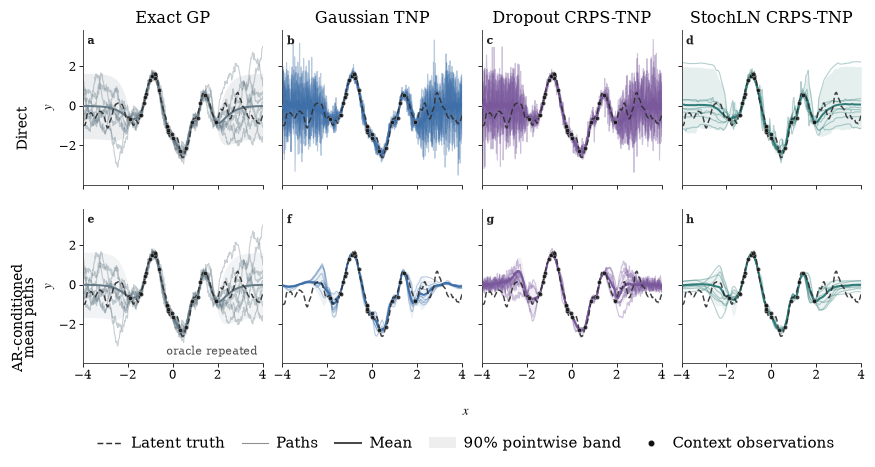

In [38]:
# Rapid iteration and preview

# ---------------------------------------------------------------------
# QUICK ITERATION CONTROLS
# ---------------------------------------------------------------------

VISIBLE_PATHS = 8

PATH_ALPHA = 0.36
PATH_LINEWIDTH = 0.80

SHOW_PATHS = True
SHOW_DIRECT_MEAN = True
SHOW_AR_MEAN = True

SHOW_DIRECT_INTERVAL = True
SHOW_AR_ENVELOPE = True

DIRECT_INTERVAL_ALPHA = 0.12
AR_ENVELOPE_ALPHA = 0.09

SHOW_CONTEXT = True
SHOW_TARGETS = False
SHOW_PANEL_LETTERS = True

USE_MODEL_COLOURS = True

FIGSIZE = (8.6, 4.8)

MANUAL_Y_LIM = None


fig, axes = make_gaussian_controls_figure(
    cache
)

plt.show()

Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/gaussian_controls/notebook_exports/gaussian_controls_direct_vs_ar_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/gaussian_controls/notebook_exports/gaussian_controls_direct_vs_ar_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/gaussian_controls/notebook_exports/gaussian_controls_direct_vs_ar_v01_style.json


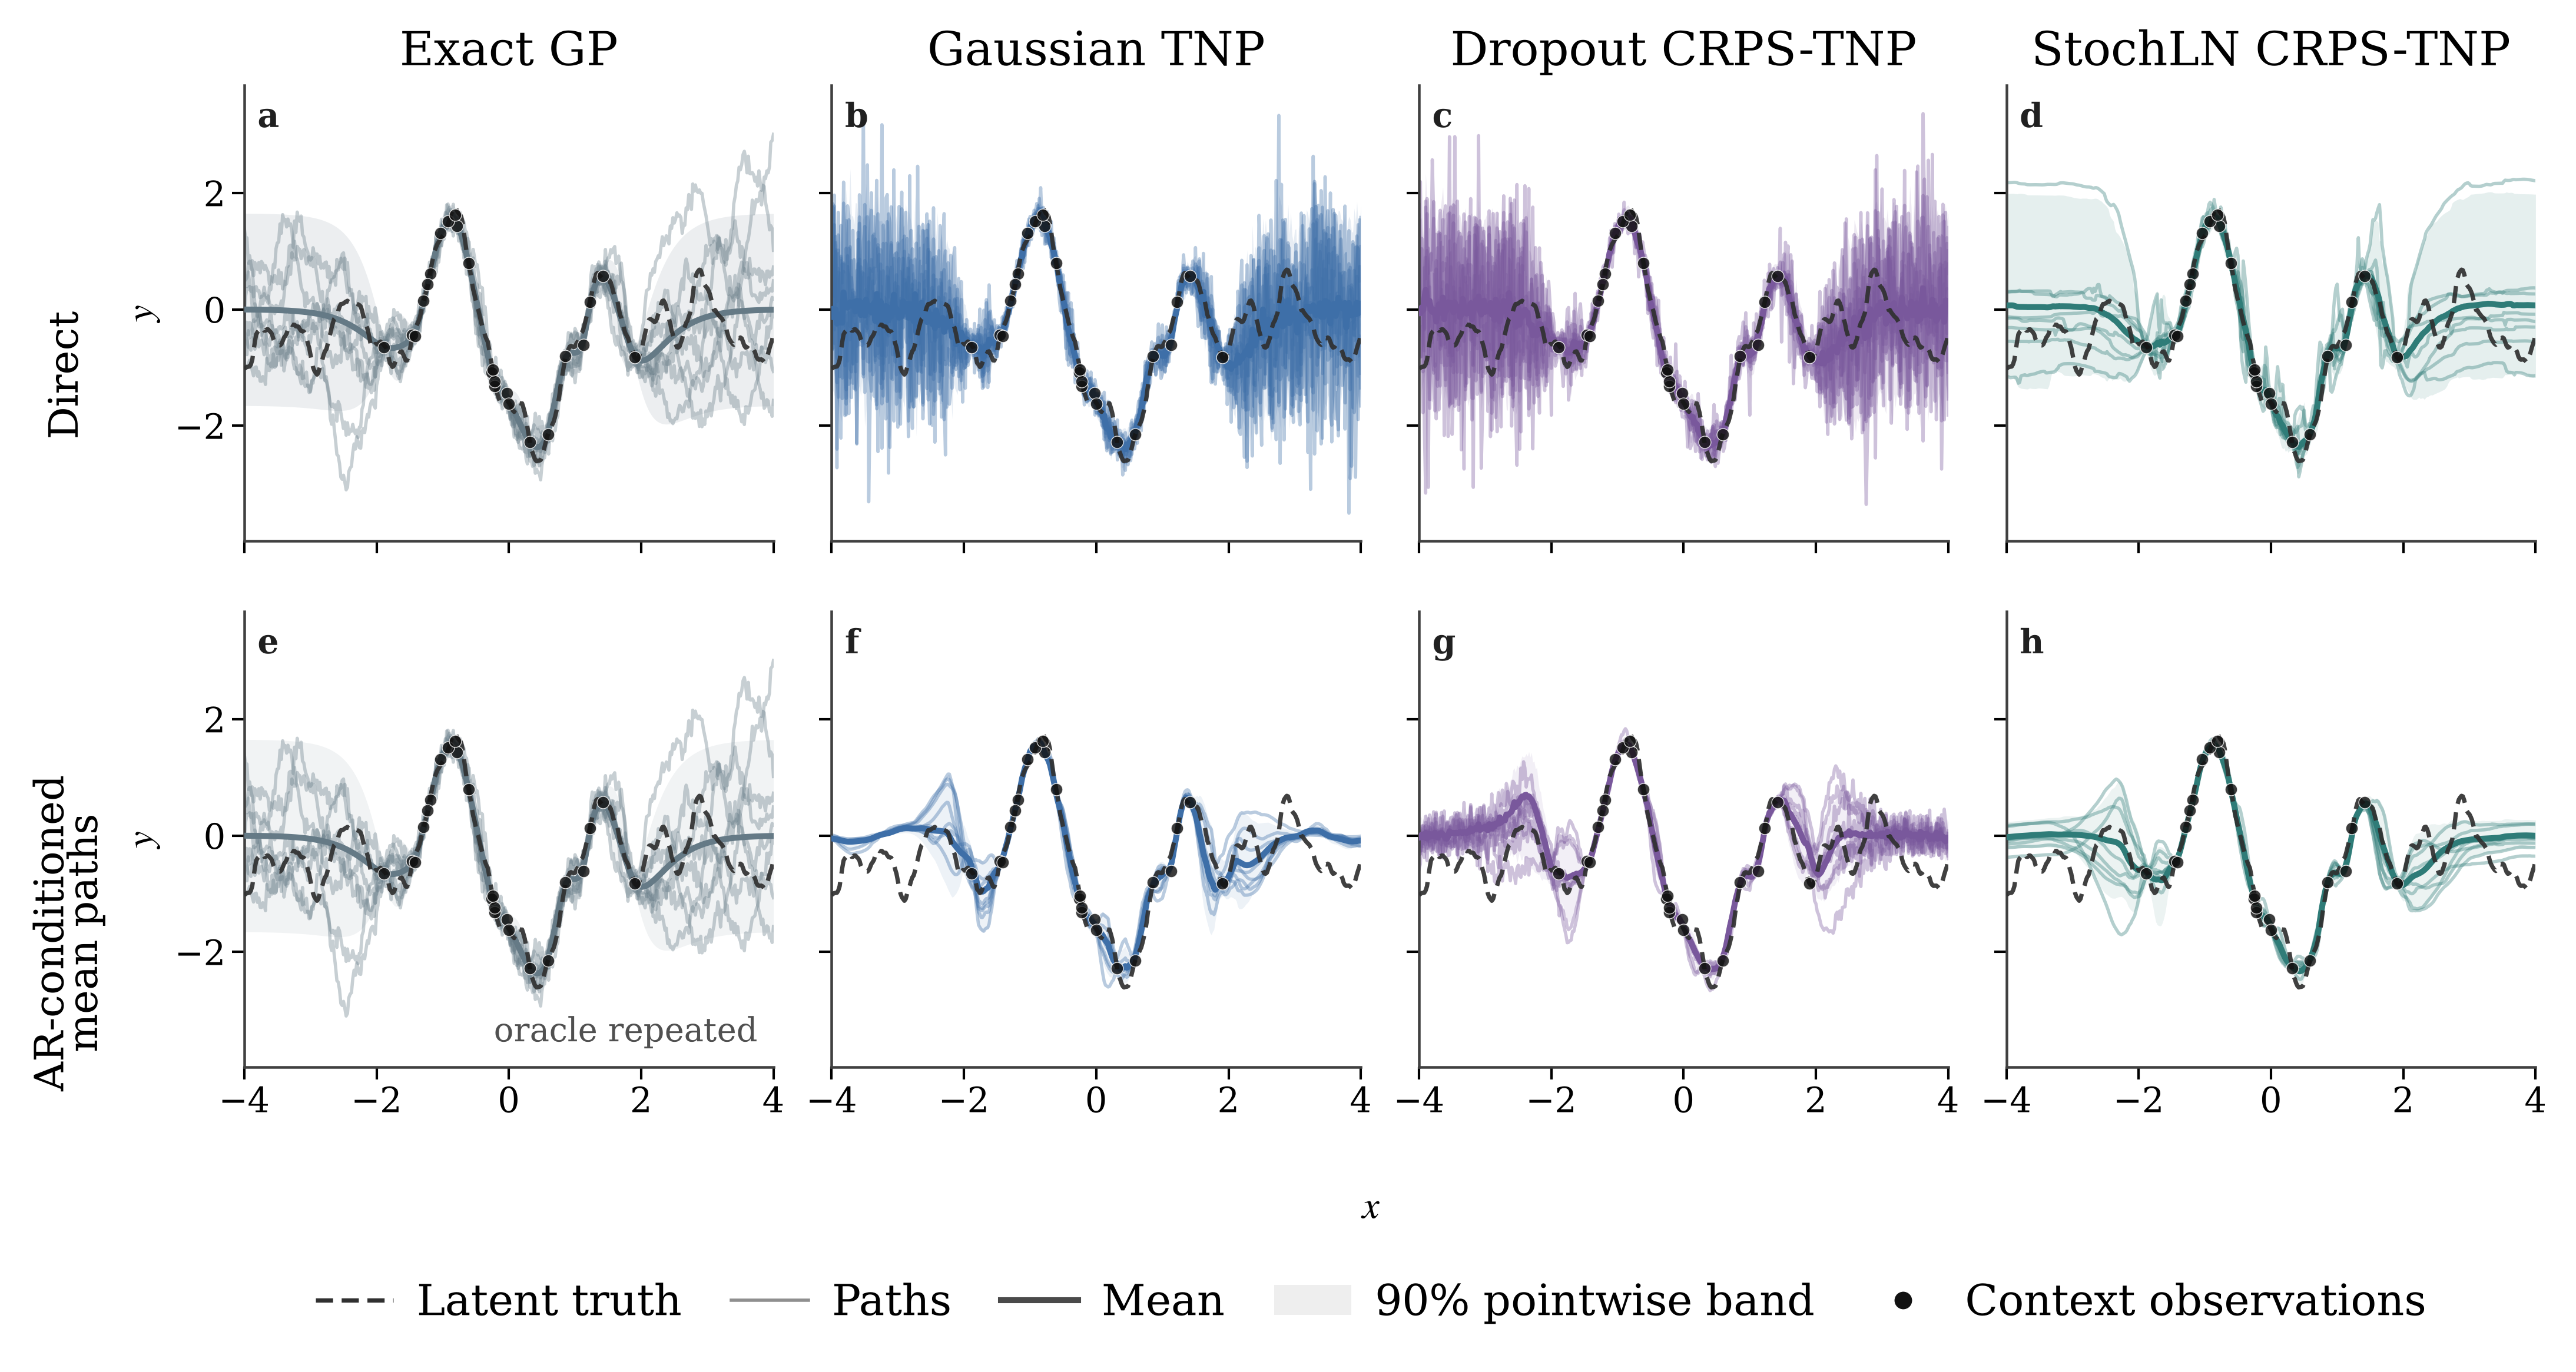

In [39]:
# Export PDF, PNG, and the style settings

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pdf_path = (
    OUTPUT_DIR
    / f"{EXPORT_NAME}.pdf"
)

png_path = (
    OUTPUT_DIR
    / f"{EXPORT_NAME}.png"
)

style_path = (
    OUTPUT_DIR
    / f"{EXPORT_NAME}_style.json"
)


fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
    metadata={
        "Title": "Gaussian controls: direct and AR-conditioned predictions",
        "Creator": "tnp-crps dissertation figure-design notebook",
    },
)

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white",
)


style_snapshot = {
    "cache_path": str(CACHE_PATH),
    "cache_metadata": cache["metadata"],
    "export_name": EXPORT_NAME,
    "figsize": list(FIGSIZE),
    "dpi": DPI,
    "visible_paths": VISIBLE_PATHS,
    "path_start_index": PATH_START_INDEX,
    "path_alpha": PATH_ALPHA,
    "path_linewidth": PATH_LINEWIDTH,
    "mean_linewidth": MEAN_LINEWIDTH,
    "truth_linewidth": TRUTH_LINEWIDTH,
    "interval_level": INTERVAL_LEVEL,
    "direct_interval_alpha": DIRECT_INTERVAL_ALPHA,
    "ar_envelope_alpha": AR_ENVELOPE_ALPHA,
    "show_paths": SHOW_PATHS,
    "show_direct_mean": SHOW_DIRECT_MEAN,
    "show_ar_mean": SHOW_AR_MEAN,
    "show_direct_interval": SHOW_DIRECT_INTERVAL,
    "show_ar_envelope": SHOW_AR_ENVELOPE,
    "show_latent_truth": SHOW_LATENT_TRUTH,
    "show_context": SHOW_CONTEXT,
    "show_targets": SHOW_TARGETS,
    "show_panel_letters": SHOW_PANEL_LETTERS,
    "show_ar_anchor_rug": SHOW_AR_ANCHOR_RUG,
    "shade_context_domain": SHADE_CONTEXT_DOMAIN,
    "context_domain": list(CONTEXT_DOMAIN),
    "manual_x_lim": (
        list(MANUAL_X_LIM)
        if MANUAL_X_LIM is not None
        else None
    ),
    "manual_y_lim": (
        list(MANUAL_Y_LIM)
        if MANUAL_Y_LIM is not None
        else None
    ),
    "use_model_colours": USE_MODEL_COLOURS,
    "single_prediction_colour": SINGLE_PREDICTION_COLOUR,
    "model_colours": MODEL_COLOURS,
    "truth_colour": TRUTH_COLOUR,
    "context_colour": CONTEXT_COLOUR,
}

style_path.write_text(
    json.dumps(
        style_snapshot,
        indent=2,
    )
)


print("Wrote:", pdf_path)
print("Wrote:", png_path)
print("Wrote:", style_path)

plt.close(fig)

display(
    Image(
        filename=str(png_path),
        width=1100,
    )
)

# Dissertation Figure Design: Binary Latent Fork

This section loads three frozen prediction caches and performs no model
inference.

**F1 — Ambiguous marginal recovery:** exact binary-mixture density versus the
three learned predictive marginals at two post-fork locations.

**F2 — Revealing-context conditioning:** predicted upper-branch probability
for ambiguous-only and mixed-context training, under ambiguous and paired
upper-revealing contexts.

**F3 — Function-level coherence:** sparse-anchor
AR-conditioned mean paths for the exact joint oracle and the three learned
models.

The quantitative T1–T3 analyses remain separate. These figures use one fixed,
non-searched task per figure and are qualitative illustrations of the aggregate
results.


In [45]:
# Binary-fork cache paths and visual settings

BF_CACHE_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "binary_fork"
    / "caches"
)

BF_OUTPUT_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "binary_fork"
    / "notebook_exports"
)

BF_F1_CACHE_PATH = (
    BF_CACHE_DIR
    / "binary_fork_marginal_densities_cache_v1.pt"
)

BF_F2_CACHE_PATH = (
    BF_CACHE_DIR
    / "binary_fork_conditioning_curves_cache_v1.pt"
)

BF_F3_CACHE_PATH = (
    BF_CACHE_DIR
    / "binary_fork_direct_vs_ar_cache_v1.pt"
)

BF_F1_EXPORT_NAME = "binary_fork_marginal_densities_v01"
BF_F2_EXPORT_NAME = "binary_fork_conditioning_curves_v01"
BF_F3_EXPORT_NAME = "binary_fork_ar_coherence_v01"

BF_DPI = 500

BF_MODEL_ORDER = [
    "Gaussian TNP",
    "Dropout CRPS-TNP",
    "StochLN CRPS-TNP",
]

BF_ORACLE_COLOUR = MODEL_COLOURS["Exact GP oracle"]
BF_TRUTH_COLOUR = TRUTH_COLOUR
BF_CONTEXT_COLOUR = CONTEXT_COLOUR

BF_FORK_X = 0.0
BF_TRANSITION_END = 0.1

BF_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Binary-fork cache directory:", BF_CACHE_DIR)
print("Binary-fork export directory:", BF_OUTPUT_DIR)


Binary-fork cache directory: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/caches
Binary-fork export directory: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports


In [5]:
# Load and validate the frozen binary-fork caches

for required_path in (
    BF_F1_CACHE_PATH,
    BF_F2_CACHE_PATH,
    BF_F3_CACHE_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Cache not found:\n{required_path}\n\n"
            "Run experiments/cache_binary_fork_figures.py first."
        )

bf_f1_cache = torch.load(
    BF_F1_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

bf_f2_cache = torch.load(
    BF_F2_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

bf_f3_cache = torch.load(
    BF_F3_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)


# ---------------------------------------------------------------------
# F1 validation
# ---------------------------------------------------------------------

if bf_f1_cache.get("schema_version") != "binary_fork_marginals_cache_v1":
    raise RuntimeError(
        "Unexpected F1 cache schema: "
        f"{bf_f1_cache.get('schema_version')!r}."
    )

if bool(bf_f1_cache["metadata"].get("smoke", False)):
    raise RuntimeError("F1 is a smoke cache, not the final cache.")

if set(bf_f1_cache["models"]) != set(BF_MODEL_ORDER):
    raise RuntimeError(
        "F1 model keys do not match the final model order."
    )

f1_probe_x = bf_f1_cache["task"]["probe_x"]
f1_means = bf_f1_cache["exact_marginal"]["component_means"]
f1_scales = bf_f1_cache["exact_marginal"]["component_scales"]
f1_weights = bf_f1_cache["exact_marginal"]["regime_weights"]

assert tuple(f1_probe_x.shape) == (1, 2, 1)
assert tuple(f1_means.shape) == (1, 2, 2, 1)
assert f1_scales.shape == f1_means.shape
assert tuple(f1_weights.shape) == (1, 2)
assert torch.allclose(
    f1_weights,
    torch.full_like(f1_weights, 0.5),
    rtol=0.0,
    atol=1.0e-7,
)

for model_name in BF_MODEL_ORDER:
    samples = bf_f1_cache["models"][model_name]
    assert samples.ndim == 4
    assert tuple(samples.shape[1:]) == (1, 2, 1)
    assert torch.isfinite(samples).all()


# ---------------------------------------------------------------------
# F2 validation
# ---------------------------------------------------------------------

if bf_f2_cache.get("schema_version") != "binary_fork_conditioning_cache_v1":
    raise RuntimeError(
        "Unexpected F2 cache schema: "
        f"{bf_f2_cache.get('schema_version')!r}."
    )

if bool(bf_f2_cache["metadata"].get("smoke", False)):
    raise RuntimeError("F2 is a smoke cache, not the final cache.")

assert tuple(bf_f2_cache["x_grid"].shape[:1]) == (1,)
assert bf_f2_cache["x_grid"].ndim == 3

expected_f2_groups = {"old", "mixed"}
expected_f2_conditions = {"ambiguous", "upper_reveal"}

if set(bf_f2_cache["groups"]) != expected_f2_groups:
    raise RuntimeError("Unexpected F2 training groups.")

for group_name in expected_f2_groups:
    if set(bf_f2_cache["groups"][group_name]) != expected_f2_conditions:
        raise RuntimeError(
            f"Unexpected F2 conditions for group={group_name}."
        )

    for condition_name in expected_f2_conditions:
        curves = bf_f2_cache["groups"][group_name][condition_name]

        if set(curves) != set(BF_MODEL_ORDER):
            raise RuntimeError(
                f"Unexpected F2 model keys for "
                f"{group_name}/{condition_name}."
            )

        for model_name in BF_MODEL_ORDER:
            curve = curves[model_name]
            assert curve.shape == bf_f2_cache["x_grid"].shape
            assert torch.isfinite(curve).all()

for condition_name in expected_f2_conditions:
    exact_curve = bf_f2_cache["exact"]["upper_probability"][condition_name]
    assert exact_curve.shape == bf_f2_cache["x_grid"].shape
    assert torch.isfinite(exact_curve).all()


# ---------------------------------------------------------------------
# F3 validation
# ---------------------------------------------------------------------

if bf_f3_cache.get("schema_version") != "binary_fork_coherence_cache_v1":
    raise RuntimeError(
        "Unexpected F3 cache schema: "
        f"{bf_f3_cache.get('schema_version')!r}."
    )

if bool(bf_f3_cache["metadata"].get("smoke", False)):
    raise RuntimeError("F3 is a smoke cache, not the final cache.")

if set(bf_f3_cache["models"]) != set(BF_MODEL_ORDER):
    raise RuntimeError(
        "F3 model keys do not match the final model order."
    )

f3_x_plot = bf_f3_cache["task"]["x_plot"]
f3_latent_truth = bf_f3_cache["task"]["latent_truth"]
f3_exact_samples = bf_f3_cache["exact_joint"]["direct_samples"]

assert f3_x_plot.ndim == 3
assert f3_latent_truth.shape == f3_x_plot.shape
assert f3_exact_samples.ndim == 4
assert tuple(f3_exact_samples.shape[1:]) == tuple(f3_x_plot.shape)
assert torch.isfinite(f3_exact_samples).all()

for model_name in BF_MODEL_ORDER:
    model_cache = bf_f3_cache["models"][model_name]

    for key in (
        "direct_samples",
        "ar_support_x",
        "raw_ar_samples",
        "ar_denoised_paths",
    ):
        if key not in model_cache:
            raise KeyError(
                f"F3 {model_name} is missing {key!r}."
            )

    assert model_cache["direct_samples"].ndim == 4
    assert model_cache["raw_ar_samples"].ndim == 4
    assert model_cache["ar_denoised_paths"].ndim == 4

    assert tuple(model_cache["direct_samples"].shape[1:]) == tuple(
        f3_x_plot.shape
    )

    assert tuple(model_cache["ar_denoised_paths"].shape[1:]) == tuple(
        f3_x_plot.shape
    )

    assert model_cache["raw_ar_samples"].shape[2] == model_cache[
        "ar_support_x"
    ].shape[1]

    for key in (
        "direct_samples",
        "raw_ar_samples",
        "ar_denoised_paths",
    ):
        assert torch.isfinite(model_cache[key]).all()


print("F1 metadata:")
print(json.dumps(bf_f1_cache["metadata"], indent=2))

print("\nF2 metadata:")
print(json.dumps(bf_f2_cache["metadata"], indent=2))

print("\nF3 metadata:")
print(json.dumps(bf_f3_cache["metadata"], indent=2))

print("\nPASS: all three final binary-fork caches are valid and CPU-only.")


F1 metadata:
{
  "figure_id": "F1",
  "figure_name": "ambiguous marginal recovery",
  "smoke": false,
  "figure_config": {
    "evaluation_config": "experiments/configs/evaluation/latent_fork/binary_fork_marginals_final.yml",
    "output_name": "binary_fork_marginal_densities_cache_v1.pt",
    "context_size": 16,
    "deterministic_seed": 20260911,
    "qualifying_task_index": 0,
    "search_batches": 32,
    "probe_x": [
      0.5,
      3.0
    ],
    "sampling_seed": 20261911,
    "num_samples": 4096,
    "sample_chunk_size": 64
  },
  "evaluation_config": "/scratch2/ij292/tnp-crps/experiments/configs/evaluation/latent_fork/binary_fork_marginals_final.yml",
  "base_generator_config": "experiments/configs/generators/binary_latent_fork_1d.yml",
  "selected_generator_batch_index": 0,
  "task_fingerprint": "a78c1ca5ad490a3e4beae2c426840ca32a67e98d9acbf2bae6e455057eeb2553",
  "num_context": 16,
  "max_ambiguous_weight_deviation": 0.0,
  "source_manifest": [
    {
      "name": "Exact mar

In [27]:
# ---------------------------------------------------------------------
# Binary-fork figure tuning constants
# ---------------------------------------------------------------------

BF_PANEL_LABEL_SIZE = 10
BF_LEGEND_FONT_SIZE = 10
BF_ROW_LABEL_SIZE = 11
BF_TITLE_SIZE = 11
BF_SAMPLE_PATH_ALPHA = 0.28
BF_SAMPLE_PATH_DARKEN = 0.18


def darken_colour(color, amount=0.18):
    """
    Darken a Matplotlib colour slightly without changing linewidth.
    amount=0 gives the original colour; larger values darken more.
    """
    rgb = np.array(mpl.colors.to_rgb(color))
    return tuple(np.clip((1.0 - amount) * rgb, 0.0, 1.0))

In [18]:
# Shared binary-fork plotting and export helpers
def bf_to_1d(value: torch.Tensor) -> np.ndarray:
    return (
        value.detach()
        .cpu()
        .reshape(-1)
        .numpy()
    )


def bf_central_interval(
    paths: torch.Tensor,
    level: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    lower_probability = (1.0 - float(level)) / 2.0
    upper_probability = 1.0 - lower_probability

    lower = torch.quantile(
        paths,
        lower_probability,
        dim=0,
    )

    upper = torch.quantile(
        paths,
        upper_probability,
        dim=0,
    )

    return lower, upper


def bf_select_visible_paths(
    paths: torch.Tensor,
    *,
    visible_paths: int,
    start_index: int,
) -> torch.Tensor:
    available = int(paths.shape[0])
    count = min(int(visible_paths), available)
    start = int(start_index)

    if start < 0:
        raise ValueError("start_index cannot be negative.")

    if start + count > available:
        start = max(0, available - count)

    return paths[start : start + count]


def bf_normal_pdf(
    grid: np.ndarray,
    mean: float,
    scale: float,
) -> np.ndarray:
    safe_scale = max(float(scale), 1.0e-8)
    z = (grid - float(mean)) / safe_scale

    return (
        np.exp(-0.5 * z * z)
        / (np.sqrt(2.0 * np.pi) * safe_scale)
    )


def bf_exact_mixture_density(
    *,
    grid: np.ndarray,
    means: np.ndarray,
    scales: np.ndarray,
    weights: np.ndarray,
) -> np.ndarray:
    density = np.zeros_like(
        grid,
        dtype=np.float64,
    )

    for mean, scale, weight in zip(
        means,
        scales,
        weights,
    ):
        density += float(weight) * bf_normal_pdf(
            grid,
            float(mean),
            float(scale),
        )

    return density


def bf_fixed_bandwidth_kde(
    *,
    values: np.ndarray,
    grid: np.ndarray,
    bandwidth: float,
) -> np.ndarray:
    values = np.asarray(
        values,
        dtype=np.float64,
    ).reshape(-1)

    safe_bandwidth = max(float(bandwidth), 1.0e-4)

    z = (
        grid[:, None]
        - values[None, :]
    ) / safe_bandwidth

    density = np.exp(
        -0.5 * z * z
    ).mean(axis=1)

    density /= (
        np.sqrt(2.0 * np.pi)
        * safe_bandwidth
    )

    return density


def bf_export_figure(
    *,
    fig: plt.Figure,
    export_name: str,
    title: str,
    style_snapshot: dict,
) -> tuple[Path, Path, Path]:
    BF_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    pdf_path = BF_OUTPUT_DIR / f"{export_name}.pdf"
    png_path = BF_OUTPUT_DIR / f"{export_name}.png"
    style_path = BF_OUTPUT_DIR / f"{export_name}_style.json"

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
        metadata={
            "Title": title,
            "Creator": "tnp-crps dissertation figure-design notebook",
        },
    )

    fig.savefig(
        png_path,
        dpi=BF_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    style_path.write_text(
        json.dumps(
            {
                "export_name": export_name,
                "title": title,
                **style_snapshot,
            },
            indent=2,
        )
    )

    print("Wrote:", pdf_path)
    print("Wrote:", png_path)
    print("Wrote:", style_path)

    display(
        Image(
            filename=str(png_path),
            width=1100,
        )
    )

    return pdf_path, png_path, style_path


In [30]:
# F1: ambiguous marginal recovery

BF_F1_FIGSIZE = (8.6, 4.6)
BF_F1_KDE_BANDWIDTH = 0.080
BF_F1_GRID_POINTS = 650
BF_F1_X_PADDING_FRACTION = 0.06

BF_F1_MODEL_ALPHA = 0.18
BF_F1_MODEL_LINEWIDTH = 1.55
BF_F1_ORACLE_LINEWIDTH = 1.35
BF_F1_COMPONENT_LINEWIDTH = 0.75

BF_F1_SHOW_COMPONENT_CENTRES = True
BF_F1_SHOW_PANEL_LETTERS = True


def make_binary_fork_marginal_figure(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray]:
    probe_x = bf_to_1d(
        cache["task"]["probe_x"]
    )

    component_means = cache[
        "exact_marginal"
    ]["component_means"].numpy()

    component_scales = cache[
        "exact_marginal"
    ]["component_scales"].numpy()

    regime_weights = cache[
        "exact_marginal"
    ]["regime_weights"].numpy()

    payload = {}

    for row_index in range(len(probe_x)):
        means = component_means[
            0,
            :,
            row_index,
            0,
        ]

        scales = component_scales[
            0,
            :,
            row_index,
            0,
        ]

        weights = regime_weights[0]

        model_values = {
            model_name: bf_to_1d(
                cache["models"][model_name][
                    :,
                    0,
                    row_index,
                    0,
                ]
            )
            for model_name in BF_MODEL_ORDER
        }

        all_model_values = np.concatenate(
            list(model_values.values())
        )

        x_min = min(
            float(np.quantile(all_model_values, 0.001)),
            float(np.min(means - 4.5 * scales)),
        )

        x_max = max(
            float(np.quantile(all_model_values, 0.999)),
            float(np.max(means + 4.5 * scales)),
        )

        padding = BF_F1_X_PADDING_FRACTION * (x_max - x_min)

        density_grid = np.linspace(
            x_min - padding,
            x_max + padding,
            BF_F1_GRID_POINTS,
        )

        exact_density = bf_exact_mixture_density(
            grid=density_grid,
            means=means,
            scales=scales,
            weights=weights,
        )

        model_densities = {
            model_name: bf_fixed_bandwidth_kde(
                values=values,
                grid=density_grid,
                bandwidth=BF_F1_KDE_BANDWIDTH,
            )
            for model_name, values in model_values.items()
        }

        row_maximum = max(
            float(exact_density.max()),
            *[
                float(density.max())
                for density in model_densities.values()
            ],
        )

        payload[row_index] = {
            "density_grid": density_grid,
            "exact_density": exact_density,
            "model_densities": model_densities,
            "component_means": means,
            "y_max": 1.06 * row_maximum,
        }

    with mpl.rc_context(DISSERTATION_RC):
        fig, axes = plt.subplots(
            nrows=2,
            ncols=3,
            figsize=(7.2, 3.9),
            sharex=True,
            sharey="row",
            constrained_layout=False,
        )

        for row_index, x_value in enumerate(probe_x):
            row_payload = payload[row_index]

            for column_index, model_name in enumerate(BF_MODEL_ORDER):
                ax = axes[row_index, column_index]
                colour = MODEL_COLOURS[model_name]

                model_density = row_payload[
                    "model_densities"
                ][model_name]

                ax.fill_between(
                    row_payload["density_grid"],
                    0.0,
                    model_density,
                    color=colour,
                    alpha=BF_F1_MODEL_ALPHA,
                    linewidth=0.0,
                    zorder=1,
                )

                ax.plot(
                    row_payload["density_grid"],
                    model_density,
                    color=colour,
                    linewidth=BF_F1_MODEL_LINEWIDTH,
                    zorder=3,
                )

                ax.plot(
                    row_payload["density_grid"],
                    row_payload["exact_density"],
                    color="#202020",
                    linewidth=BF_F1_ORACLE_LINEWIDTH,
                    linestyle=(0, (4, 2)),
                    zorder=4,
                )

                if BF_F1_SHOW_COMPONENT_CENTRES:
                    for component_mean in row_payload["component_means"]:
                        ax.axvline(
                            float(component_mean),
                            color="#777777",
                            linewidth=BF_F1_COMPONENT_LINEWIDTH,
                            linestyle=":",
                            alpha=0.75,
                            zorder=2,
                        )

                ax.set_ylim(
                    0.0,
                    row_payload["y_max"],
                )

                ax.grid(False)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                ax.tick_params(
                    axis="both",
                    width=0.60,
                    length=3.0,
                    pad=1.5,
                )

                if row_index == 0:
                    ax.set_title(
                        model_name,
                        fontsize=11.0,
                        pad=5,
                    )

                if column_index > 0:
                    ax.tick_params(labelleft=False)

                if BF_F1_SHOW_PANEL_LETTERS:
                    panel_index = row_index * 3 + column_index

                    ax.text(
                        0.025,
                        0.965,
                        string.ascii_lowercase[panel_index],
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=BF_PANEL_LABEL_SIZE,
                        fontweight="bold",
                        color="#202020",
                    )

        fig.text(
            0.020,
            0.705,
            rf"$x={probe_x[0]:.1f}$",
            rotation=90,
            va="center",
            ha="center",
            fontsize=BF_ROW_LABEL_SIZE,
        )

        fig.text(
            0.020,
            0.315,
            rf"$x={probe_x[1]:.1f}$",
            rotation=90,
            va="center",
            ha="center",
            fontsize=10.0,
        )

        fig.text(
            0.520,
            0.105,
            r"Predictive value $y$",
            va="center",
            ha="center",
            fontsize=9.5,
        )

        fig.text(
            0.055,
            0.520,
            "Density",
            rotation=90,
            va="center",
            ha="center",
            fontsize=9.5,
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                color="#202020",
                linewidth=BF_F1_ORACLE_LINEWIDTH,
                linestyle=(0, (4, 2)),
                label="Exact mixture",
            ),
            Patch(
                facecolor="#777777",
                edgecolor="#555555",
                linewidth=0.8,
                alpha=BF_F1_MODEL_ALPHA,
                label="Model density",
            ),
            Line2D(
                [0],
                [0],
                color="#777777",
                linewidth=BF_F1_COMPONENT_LINEWIDTH,
                linestyle=":",
                label="Oracle component centres",
            ),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.520, -0.005),
            ncol=3,
            frameon=False,
            fontsize=BF_LEGEND_FONT_SIZE,
            handlelength=2.1,
            columnspacing=1.25,
        )

        fig.subplots_adjust(
            left=0.12,
            right=0.995,
            top=0.90,
            bottom=0.27,
            wspace=0.18,
            hspace=0.28,
        )

        return fig, axes


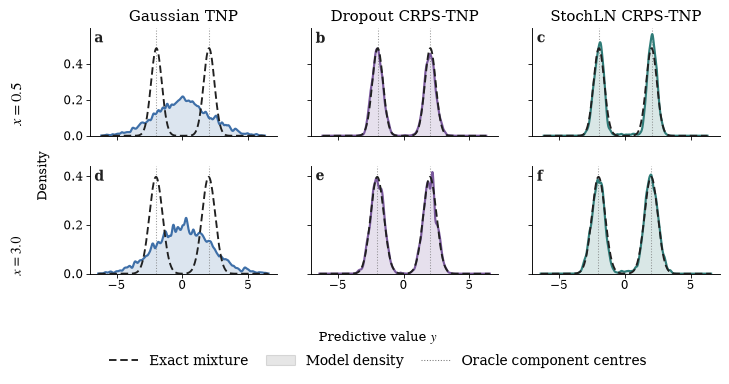

In [31]:
# Preview F1

bf_f1_fig, bf_f1_axes = make_binary_fork_marginal_figure(
    bf_f1_cache
)

plt.show()


Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_marginal_densities_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_marginal_densities_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_marginal_densities_v01_style.json


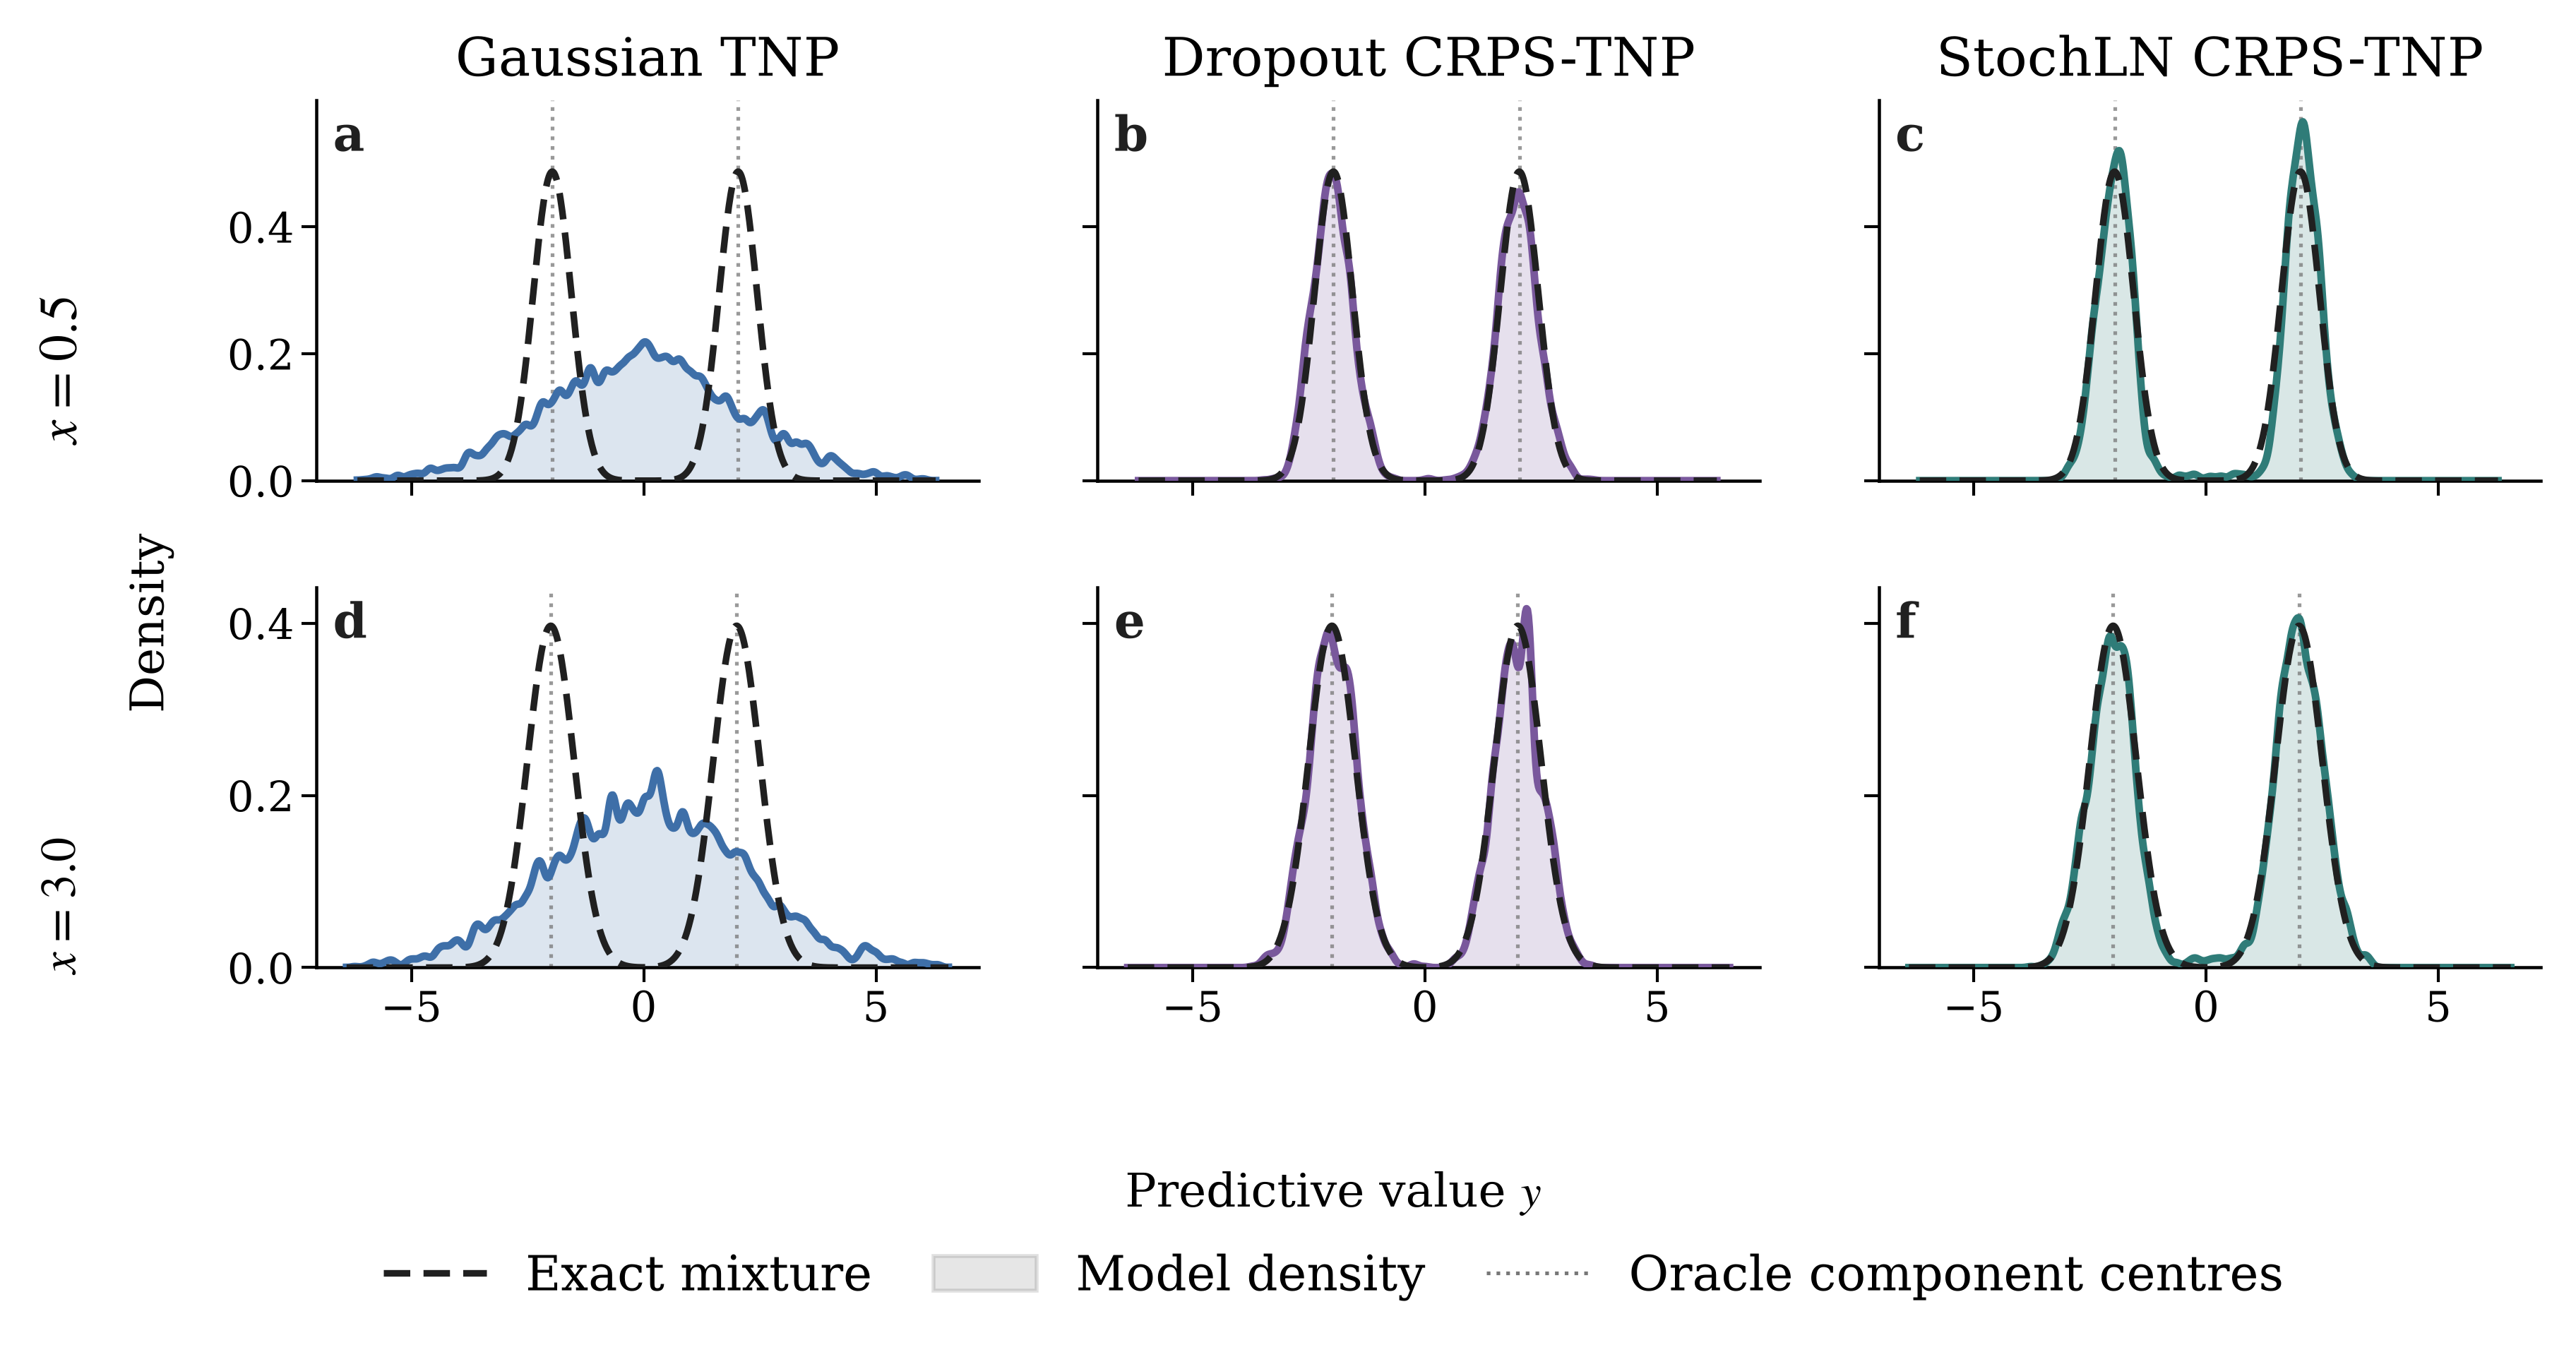

In [42]:
# Export F1

bf_export_figure(
    fig=bf_f1_fig,
    export_name=BF_F1_EXPORT_NAME,
    title="Binary latent fork: ambiguous marginal recovery",
    style_snapshot={
        "cache_path": str(BF_F1_CACHE_PATH),
        "cache_metadata": bf_f1_cache["metadata"],
        "figsize": list(BF_F1_FIGSIZE),
        "dpi": BF_DPI,
        "model_order": BF_MODEL_ORDER,
        "kde_bandwidth": BF_F1_KDE_BANDWIDTH,
        "grid_points": BF_F1_GRID_POINTS,
        "show_component_centres": BF_F1_SHOW_COMPONENT_CENTRES,
        "show_panel_letters": BF_F1_SHOW_PANEL_LETTERS,
    },
)

plt.close(bf_f1_fig)


In [40]:
# F2: revealing-context conditioning

BF_F2_FIGSIZE = (8.6, 4.9)

BF_F2_LINEWIDTH = 1.45
BF_F2_ORACLE_LINEWIDTH = 1.45

BF_F2_SHOW_PANEL_LETTERS = True

# Figure-specific typography
BF_F2_TITLE_SIZE = 11.5
BF_F2_PANEL_LABEL_SIZE = 10.5
BF_F2_ROW_LABEL_SIZE = 10.5
BF_F2_AXIS_LABEL_SIZE = 10.5
BF_F2_LEGEND_FONT_SIZE = 10.0

BF_F2_GROUP_ORDER = [
    "old",
    "mixed",
]

BF_F2_CONDITION_ORDER = [
    "ambiguous",
    "upper_reveal",
]

BF_F2_COLUMN_TITLES = {
    "ambiguous": "Ambiguous context",
    "upper_reveal": "Upper-branch revealing context",
}

BF_F2_ROW_TITLES = {
    "old": "Ambiguous-only\ntraining",
    "mixed": "Mixed-context\ntraining",
}


def make_binary_fork_conditioning_figure(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray]:
    x_grid = bf_to_1d(
        cache["x_grid"]
    )

    inject_x = float(
        cache["metadata"]["figure_config"]["inject_x"]
    )

    with mpl.rc_context(
        DISSERTATION_RC
    ):
        fig, axes = plt.subplots(
            nrows=2,
            ncols=2,
            figsize=BF_F2_FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        for row_index, group_name in enumerate(
            BF_F2_GROUP_ORDER
        ):
            for column_index, condition_name in enumerate(
                BF_F2_CONDITION_ORDER
            ):
                ax = axes[
                    row_index,
                    column_index,
                ]

                # Reference probability under complete ambiguity.
                ax.axhline(
                    0.5,
                    color="#A0A0A0",
                    linewidth=0.75,
                    linestyle=":",
                    zorder=1,
                )

                # Location of the revealing context observation.
                if condition_name == "upper_reveal":
                    ax.axvline(
                        inject_x,
                        color="#A84A4A",
                        linewidth=0.90,
                        linestyle=(0, (4, 2)),
                        zorder=1,
                    )

                # Exact upper-branch posterior probability.
                ax.plot(
                    x_grid,
                    bf_to_1d(
                        cache[
                            "exact"
                        ][
                            "upper_probability"
                        ][
                            condition_name
                        ]
                    ),
                    color="#202020",
                    linewidth=BF_F2_ORACLE_LINEWIDTH,
                    linestyle=(0, (4, 2)),
                    zorder=5,
                )

                # Learned model probabilities.
                for model_name in BF_MODEL_ORDER:
                    ax.plot(
                        x_grid,
                        bf_to_1d(
                            cache[
                                "groups"
                            ][
                                group_name
                            ][
                                condition_name
                            ][
                                model_name
                            ]
                        ),
                        color=MODEL_COLOURS[
                            model_name
                        ],
                        linewidth=BF_F2_LINEWIDTH,
                        zorder=4,
                    )

                ax.set_xlim(
                    float(
                        x_grid.min()
                    ),
                    float(
                        x_grid.max()
                    ),
                )

                ax.set_ylim(
                    -0.025,
                    1.025,
                )

                ax.set_xticks(
                    [
                        0.5,
                        1.0,
                        2.0,
                        3.0,
                        4.0,
                    ]
                )

                ax.set_yticks(
                    [
                        0.0,
                        0.25,
                        0.5,
                        0.75,
                        1.0,
                    ]
                )

                ax.grid(
                    False
                )

                ax.spines[
                    "top"
                ].set_visible(
                    False
                )

                ax.spines[
                    "right"
                ].set_visible(
                    False
                )

                ax.tick_params(
                    axis="both",
                    width=0.60,
                    length=3.0,
                    pad=1.5,
                )

                # Column titles appear only on the top row.
                if row_index == 0:
                    ax.set_title(
                        BF_F2_COLUMN_TITLES[
                            condition_name
                        ],
                        fontsize=BF_F2_TITLE_SIZE,
                        pad=6,
                    )

                    ax.tick_params(
                        labelbottom=False
                    )

                # Only the left column shows y tick labels.
                if column_index > 0:
                    ax.tick_params(
                        labelleft=False
                    )

                # No per-axis y-labels: use one shared figure-level label.
                ax.set_ylabel(
                    ""
                )

                if BF_F2_SHOW_PANEL_LETTERS:
                    panel_index = (
                        row_index * 2
                        + column_index
                    )

                    ax.text(
                        0.045,
                        0.950,
                        string.ascii_lowercase[
                            panel_index
                        ],
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=(
                            BF_F2_PANEL_LABEL_SIZE
                        ),
                        fontweight="bold",
                        color="#202020",
                        zorder=10,
                    )

        # -----------------------------------------------------------------
        # Shared row and axis labels
        # -----------------------------------------------------------------

        # Row labels are placed furthest left.
        fig.text(
            0.025,
            0.705,
            BF_F2_ROW_TITLES[
                "old"
            ],
            rotation=90,
            va="center",
            ha="center",
            fontsize=BF_F2_ROW_LABEL_SIZE,
            linespacing=0.95,
        )

        fig.text(
            0.025,
            0.315,
            BF_F2_ROW_TITLES[
                "mixed"
            ],
            rotation=90,
            va="center",
            ha="center",
            fontsize=BF_F2_ROW_LABEL_SIZE,
            linespacing=0.95,
        )

        # Shared y-axis label is positioned between the row labels and axes.
        fig.supylabel(
            "Predicted upper-branch probability",
            x=0.095,
            y=0.520,
            va="center",
            fontsize=BF_F2_AXIS_LABEL_SIZE,
        )

        # Shared x-axis label.
        fig.supxlabel(
            r"$x$",
            x=0.575,
            y=0.115,
            fontsize=BF_F2_AXIS_LABEL_SIZE,
        )

        # -----------------------------------------------------------------
        # Legend
        # -----------------------------------------------------------------

        legend_handles = [
            Line2D(
                [0],
                [0],
                color="#202020",
                linewidth=BF_F2_ORACLE_LINEWIDTH,
                linestyle=(0, (4, 2)),
                label="Exact oracle",
            ),
            *[
                Line2D(
                    [0],
                    [0],
                    color=MODEL_COLOURS[
                        model_name
                    ],
                    linewidth=BF_F2_LINEWIDTH,
                    label=model_name,
                )
                for model_name in BF_MODEL_ORDER
            ],
            Line2D(
                [0],
                [0],
                color="#A84A4A",
                linewidth=0.90,
                linestyle=(0, (4, 2)),
                label="Revealing observation",
            ),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(
                0.575,
                0.025,
            ),
            ncol=5,
            frameon=False,
            fontsize=BF_F2_LEGEND_FONT_SIZE,
            handlelength=2.0,
            handletextpad=0.55,
            columnspacing=1.0,
        )

        # Extra left margin separates:
        # row labels -> shared y-label -> plotting axes.
        fig.subplots_adjust(
            left=0.175,
            right=0.995,
            top=0.900,
            bottom=0.245,
            wspace=0.16,
            hspace=0.24,
        )

        return (
            fig,
            axes,
        )

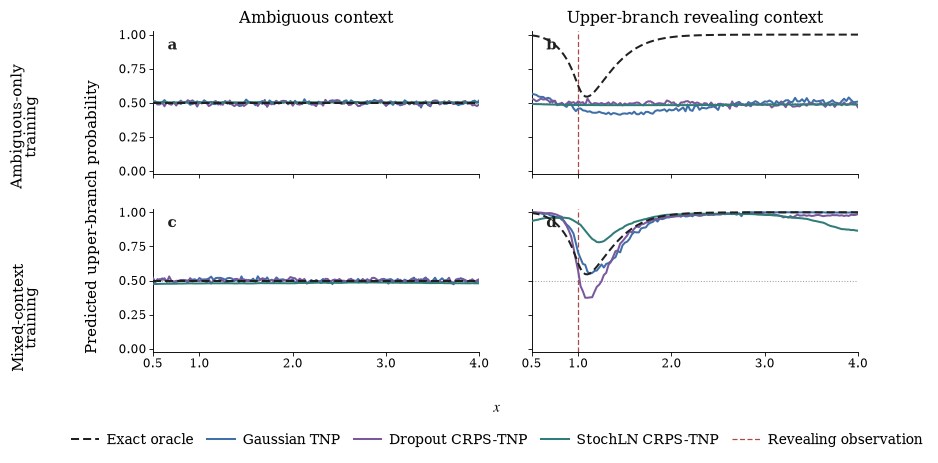

In [41]:
# Preview F2

bf_f2_fig, bf_f2_axes = make_binary_fork_conditioning_figure(
    bf_f2_cache
)

plt.show()


Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_conditioning_curves_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_conditioning_curves_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_conditioning_curves_v01_style.json


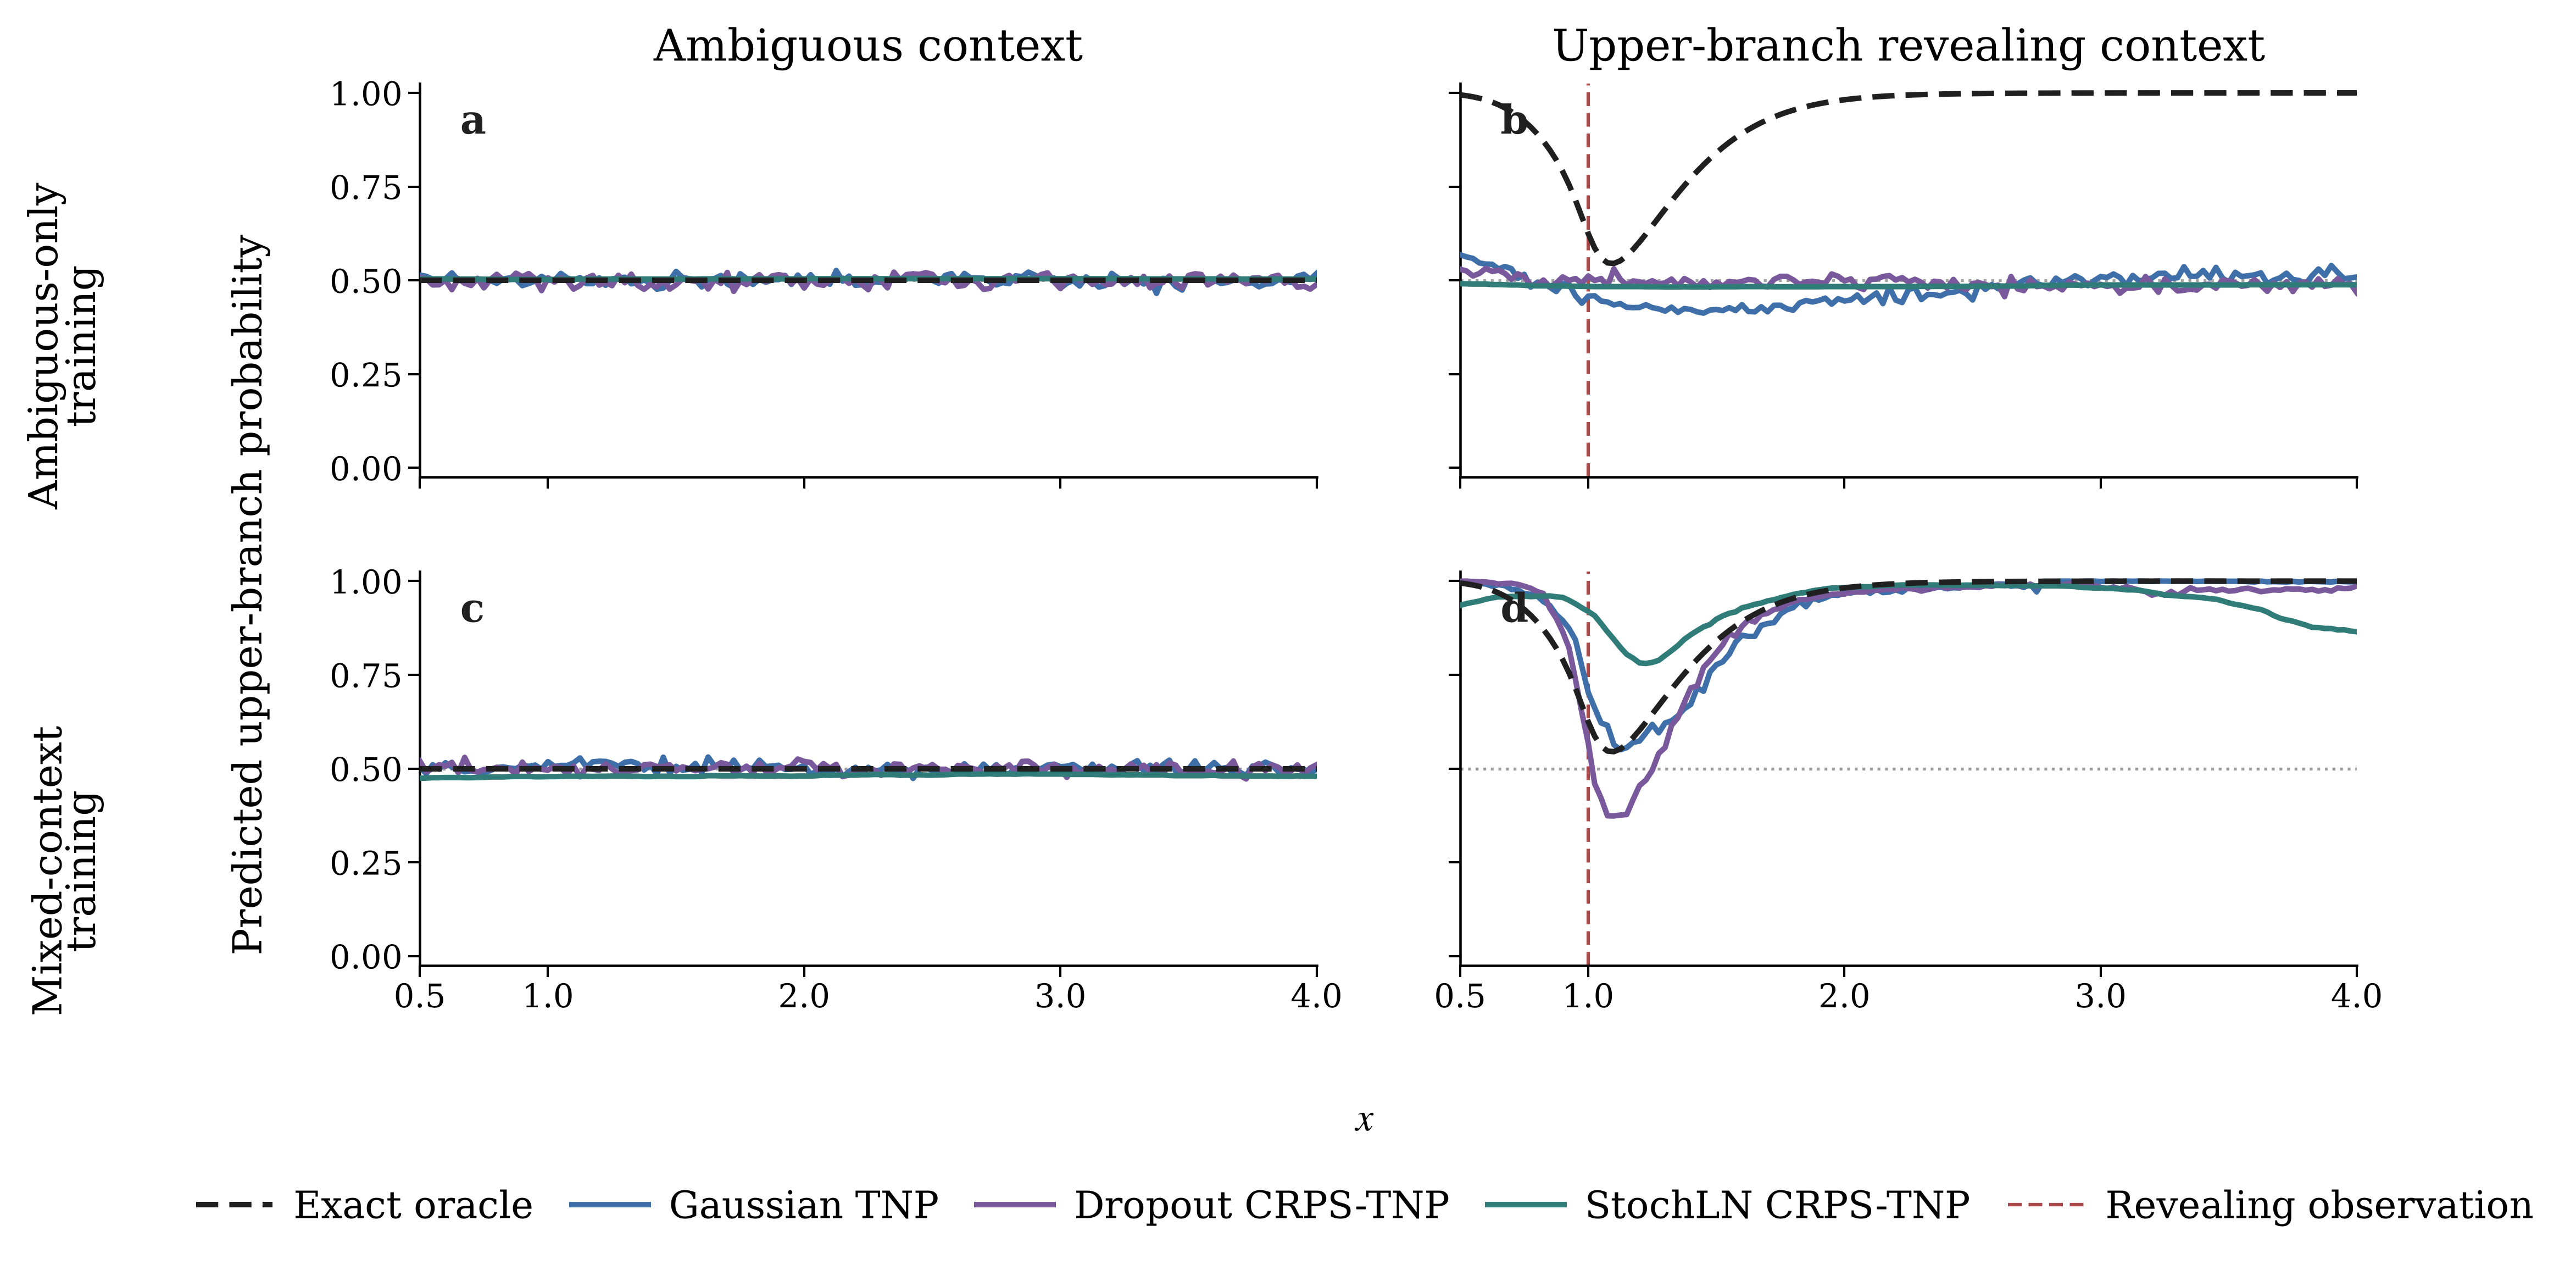

In [43]:
# Export F2

bf_export_figure(
    fig=bf_f2_fig,
    export_name=BF_F2_EXPORT_NAME,
    title="Binary latent fork: revealing-context conditioning",
    style_snapshot={
        "cache_path": str(BF_F2_CACHE_PATH),
        "cache_metadata": bf_f2_cache["metadata"],
        "figsize": list(BF_F2_FIGSIZE),
        "dpi": BF_DPI,
        "group_order": BF_F2_GROUP_ORDER,
        "condition_order": BF_F2_CONDITION_ORDER,
        "model_order": BF_MODEL_ORDER,
        "show_panel_letters": BF_F2_SHOW_PANEL_LETTERS,
    },
)

plt.close(bf_f2_fig)


In [38]:
# F3: AR-conditioned function paths only

# Four vertically stacked panels:
# Exact joint oracle, Gaussian TNP, Dropout CRPS-TNP, StochLN CRPS-TNP.
BF_F3_FIGSIZE = (6.8, 8.2)
BF_F3_INTERVAL_LEVEL = 0.90

BF_F3_VISIBLE_PATHS = 8
BF_F3_PATH_START_INDEX = 0

# Keep the sample paths thin, but make them darker through colour and opacity.
BF_F3_PATH_ALPHA = 0.48
BF_F3_PATH_DARKEN_AMOUNT = 0.10
BF_F3_PATH_LINEWIDTH = 0.80

BF_F3_MEAN_LINEWIDTH = 1.45
BF_F3_TRUTH_LINEWIDTH = 1.05

# This is an envelope across AR-conditioned mean paths, not a predictive interval.
BF_F3_AR_BAND_ALPHA = 0.10

BF_F3_CONTEXT_MARKER_SIZE = 9
BF_F3_CONTEXT_EDGE_WIDTH = 0.20
BF_F3_CONTEXT_ALPHA = 0.84

BF_F3_SHOW_PATHS = True
BF_F3_SHOW_MEAN = True
BF_F3_SHOW_BANDS = True
BF_F3_SHOW_LATENT_TRUTH = True
BF_F3_SHOW_CONTEXT = True
BF_F3_SHOW_PANEL_LETTERS = True

BF_F3_MANUAL_X_LIM = (-4.0, 4.0)
BF_F3_MANUAL_Y_LIM = None
BF_F3_Y_PADDING_FRACTION = 0.07

# Figure-specific typography.
BF_F3_PANEL_LABEL_SIZE = 10
BF_F3_TITLE_SIZE = 10
BF_F3_AXIS_LABEL_SIZE = 10
BF_F3_LEGEND_FONT_SIZE = 9.5
BF_F3_ORACLE_NOTE_SIZE = 8.5

# This is now the vertical panel order, despite the historical variable name.
BF_F3_COLUMN_ORDER = [
    "Exact joint oracle",
    *BF_MODEL_ORDER,
]

BF_F3_COLUMN_TITLES = {
    "Exact joint oracle": "Exact oracle",
    "Gaussian TNP": "Gaussian TNP",
    "Dropout CRPS-TNP": "Dropout CRPS-TNP",
    "StochLN CRPS-TNP": "StochLN CRPS-TNP",
}

BF_F3_COLOURS = {
    "Exact joint oracle": BF_ORACLE_COLOUR,
    "Gaussian TNP": MODEL_COLOURS["Gaussian TNP"],
    "Dropout CRPS-TNP": MODEL_COLOURS["Dropout CRPS-TNP"],
    "StochLN CRPS-TNP": MODEL_COLOURS["StochLN CRPS-TNP"],
}


def bf_darken_colour(
    colour,
    amount: float = BF_F3_PATH_DARKEN_AMOUNT,
) -> tuple[float, float, float]:
    """
    Darken a Matplotlib colour without changing the plotted linewidth.

    amount=0 returns the original colour.
    Larger values move the colour towards black.
    """
    rgb = np.asarray(
        mpl.colors.to_rgb(colour),
        dtype=float,
    )

    darkened = np.clip(
        rgb * (1.0 - float(amount)),
        0.0,
        1.0,
    )

    return tuple(darkened)


def bf_f3_panel_paths(
    cache: dict,
    model_name: str,
) -> torch.Tensor:
    """
    Return the paths shown in each AR-only figure panel.

    The exact joint oracle has no learned AR rollout. Its coherent joint
    samples are repeated as the theoretical reference.
    """
    if model_name == "Exact joint oracle":
        return cache["exact_joint"]["direct_samples"]

    return cache["models"][model_name]["ar_denoised_paths"]


def bf_f3_shared_y_limits(
    cache: dict,
) -> tuple[float, float]:
    """
    Calculate common y-limits using only quantities displayed in the
    final AR-only figure.
    """
    values = [
        cache["task"]["yc"].reshape(-1),
        cache["task"]["latent_truth"].reshape(-1),
    ]

    for model_name in BF_F3_COLUMN_ORDER:
        paths = bf_f3_panel_paths(
            cache,
            model_name,
        )[:, 0, :, 0]

        visible = bf_select_visible_paths(
            paths,
            visible_paths=BF_F3_VISIBLE_PATHS,
            start_index=BF_F3_PATH_START_INDEX,
        )

        mean_path = paths.mean(dim=0)

        lower, upper = bf_central_interval(
            paths,
            BF_F3_INTERVAL_LEVEL,
        )

        if BF_F3_SHOW_PATHS:
            values.append(
                visible.reshape(-1)
            )

        if BF_F3_SHOW_MEAN:
            values.append(
                mean_path.reshape(-1)
            )

        if BF_F3_SHOW_BANDS:
            values.extend(
                [
                    lower.reshape(-1),
                    upper.reshape(-1),
                ]
            )

    combined = torch.cat(
        [
            value.detach().cpu().reshape(-1)
            for value in values
        ]
    )

    combined = combined[
        torch.isfinite(combined)
    ]

    if combined.numel() == 0:
        raise RuntimeError(
            "No finite F3 values were available."
        )

    y_min = float(
        combined.min()
    )

    y_max = float(
        combined.max()
    )

    data_range = max(
        y_max - y_min,
        0.25,
    )

    padding = (
        BF_F3_Y_PADDING_FRACTION
        * data_range
    )

    return (
        y_min - padding,
        y_max + padding,
    )

In [34]:
# F3 plotting function: AR-conditioned paths only


def make_binary_fork_coherence_figure(
    cache: dict,
) -> tuple[
    plt.Figure,
    np.ndarray,
    tuple[float, float],
]:
    x_plot = bf_to_1d(
        cache["task"]["x_plot"]
    )

    latent_truth = bf_to_1d(
        cache["task"]["latent_truth"]
    )

    xc = bf_to_1d(
        cache["task"]["xc"]
    )

    yc = bf_to_1d(
        cache["task"]["yc"]
    )

    x_limits = tuple(
        BF_F3_MANUAL_X_LIM
    )

    y_limits = (
        tuple(
            BF_F3_MANUAL_Y_LIM
        )
        if BF_F3_MANUAL_Y_LIM is not None
        else bf_f3_shared_y_limits(
            cache
        )
    )

    with mpl.rc_context(
        DISSERTATION_RC
    ):
        fig, axes = plt.subplots(
            nrows=len(
                BF_F3_COLUMN_ORDER
            ),
            ncols=1,
            figsize=BF_F3_FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        # Guarantee a one-dimensional axes array.
        axes = np.atleast_1d(
            axes
        )

        for panel_index, model_name in enumerate(
            BF_F3_COLUMN_ORDER
        ):
            ax = axes[
                panel_index
            ]

            colour = BF_F3_COLOURS[
                model_name
            ]

            path_colour = bf_darken_colour(
                colour,
                amount=(
                    BF_F3_PATH_DARKEN_AMOUNT
                ),
            )

            paths = bf_f3_panel_paths(
                cache,
                model_name,
            )[:, 0, :, 0]

            visible = bf_select_visible_paths(
                paths,
                visible_paths=(
                    BF_F3_VISIBLE_PATHS
                ),
                start_index=(
                    BF_F3_PATH_START_INDEX
                ),
            )

            mean_path = paths.mean(
                dim=0
            )

            lower, upper = bf_central_interval(
                paths,
                BF_F3_INTERVAL_LEVEL,
            )

            # Shade the transition region.
            ax.axvspan(
                BF_FORK_X,
                BF_TRANSITION_END,
                color="#EFEFEF",
                alpha=0.55,
                zorder=0,
            )

            # Envelope across AR-conditioned mean paths.
            if BF_F3_SHOW_BANDS:
                ax.fill_between(
                    x_plot,
                    bf_to_1d(
                        lower
                    ),
                    bf_to_1d(
                        upper
                    ),
                    color=colour,
                    alpha=(
                        BF_F3_AR_BAND_ALPHA
                    ),
                    linewidth=0.0,
                    zorder=1,
                )

            # Thin paths with darker colour and increased opacity.
            if BF_F3_SHOW_PATHS:
                for path in visible:
                    ax.plot(
                        x_plot,
                        bf_to_1d(
                            path
                        ),
                        color=path_colour,
                        linewidth=(
                            BF_F3_PATH_LINEWIDTH
                        ),
                        alpha=(
                            BF_F3_PATH_ALPHA
                        ),
                        zorder=2,
                    )

            # Average across the AR-conditioned paths.
            if BF_F3_SHOW_MEAN:
                ax.plot(
                    x_plot,
                    bf_to_1d(
                        mean_path
                    ),
                    color=colour,
                    linewidth=(
                        BF_F3_MEAN_LINEWIDTH
                    ),
                    zorder=4,
                )

            if BF_F3_SHOW_LATENT_TRUTH:
                ax.plot(
                    x_plot,
                    latent_truth,
                    color=BF_TRUTH_COLOUR,
                    linewidth=(
                        BF_F3_TRUTH_LINEWIDTH
                    ),
                    linestyle=(
                        0,
                        (
                            4,
                            2,
                        ),
                    ),
                    alpha=0.92,
                    zorder=5,
                )

            if BF_F3_SHOW_CONTEXT:
                ax.scatter(
                    xc,
                    yc,
                    s=(
                        BF_F3_CONTEXT_MARKER_SIZE
                    ),
                    facecolor=(
                        BF_CONTEXT_COLOUR
                    ),
                    edgecolor="white",
                    linewidth=(
                        BF_F3_CONTEXT_EDGE_WIDTH
                    ),
                    alpha=(
                        BF_F3_CONTEXT_ALPHA
                    ),
                    zorder=6,
                )

            ax.axvline(
                BF_FORK_X,
                color="#6E6E6E",
                linewidth=0.80,
                linestyle=(
                    0,
                    (
                        2,
                        2,
                    ),
                ),
                zorder=1,
            )

            ax.set_xlim(
                *x_limits
            )

            ax.set_ylim(
                *y_limits
            )

            ax.set_xticks(
                [
                    -4.0,
                    -2.0,
                    0.0,
                    2.0,
                    4.0,
                ]
            )

            ax.grid(
                False
            )

            ax.spines[
                "top"
            ].set_visible(
                False
            )

            ax.spines[
                "right"
            ].set_visible(
                False
            )

            ax.tick_params(
                axis="both",
                width=0.60,
                length=3.0,
                pad=1.5,
            )

            # Model title above every vertically stacked panel.
            ax.set_title(
                BF_F3_COLUMN_TITLES[
                    model_name
                ],
                fontsize=(
                    BF_F3_TITLE_SIZE
                ),
                pad=5,
            )

            # Only the bottom panel retains x tick labels.
            if panel_index < (
                len(
                    BF_F3_COLUMN_ORDER
                )
                - 1
            ):
                ax.tick_params(
                    labelbottom=False
                )

            if BF_F3_SHOW_PANEL_LETTERS:
                ax.text(
                    0.025,
                    0.945,
                    string.ascii_lowercase[
                        panel_index
                    ],
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=(
                        BF_F3_PANEL_LABEL_SIZE
                    ),
                    fontweight="bold",
                    color="#202020",
                    zorder=10,
                )

            # The oracle is a coherent joint reference, not an AR rollout.
            if model_name == "Exact joint oracle":
                ax.text(
                    0.975,
                    0.055,
                    "joint oracle reference",
                    transform=ax.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=(
                        BF_F3_ORACLE_NOTE_SIZE
                    ),
                    color="#505050",
                    zorder=10,
                )

        # One common y-axis label for all four panels.
        fig.text(
            0.035,
            0.555,
            r"$y$",
            rotation=90,
            va="center",
            ha="center",
            fontsize=(
                BF_F3_AXIS_LABEL_SIZE
            ),
        )

        # Only the bottom panel receives the x-axis label.
        axes[-1].set_xlabel(
            r"$x$",
            fontsize=(
                BF_F3_AXIS_LABEL_SIZE
            ),
            labelpad=4,
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                color=BF_TRUTH_COLOUR,
                linewidth=(
                    BF_F3_TRUTH_LINEWIDTH
                ),
                linestyle=(
                    0,
                    (
                        4,
                        2,
                    ),
                ),
                label="Latent truth",
            ),
            Line2D(
                [0],
                [0],
                color="#555555",
                linewidth=(
                    BF_F3_PATH_LINEWIDTH
                ),
                alpha=0.90,
                label=(
                    "AR-conditioned paths"
                ),
            ),
            Line2D(
                [0],
                [0],
                color="#3F3F3F",
                linewidth=(
                    BF_F3_MEAN_LINEWIDTH
                ),
                label="Average path",
            ),
            Patch(
                facecolor="#999999",
                alpha=0.16,
                edgecolor="none",
                label=(
                    "90% path envelope"
                ),
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=(
                    BF_CONTEXT_COLOUR
                ),
                markeredgecolor="white",
                markeredgewidth=(
                    BF_F3_CONTEXT_EDGE_WIDTH
                ),
                markersize=5.0,
                label=(
                    "Context observations"
                ),
            ),
            Line2D(
                [0],
                [0],
                color="#6E6E6E",
                linewidth=0.80,
                linestyle=(
                    0,
                    (
                        2,
                        2,
                    ),
                ),
                label="Fork",
            ),
        ]

        # Three columns gives two readable legend rows.
        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(
                0.50,
                0.018,
            ),
            ncol=3,
            frameon=False,
            fontsize=(
                BF_F3_LEGEND_FONT_SIZE
            ),
            handlelength=2.0,
            handletextpad=0.60,
            columnspacing=1.30,
            labelspacing=0.75,
        )

        fig.subplots_adjust(
            left=0.105,
            right=0.990,
            top=0.965,
            bottom=0.165,
            hspace=0.34,
        )

        return (
            fig,
            axes,
            y_limits,
        )

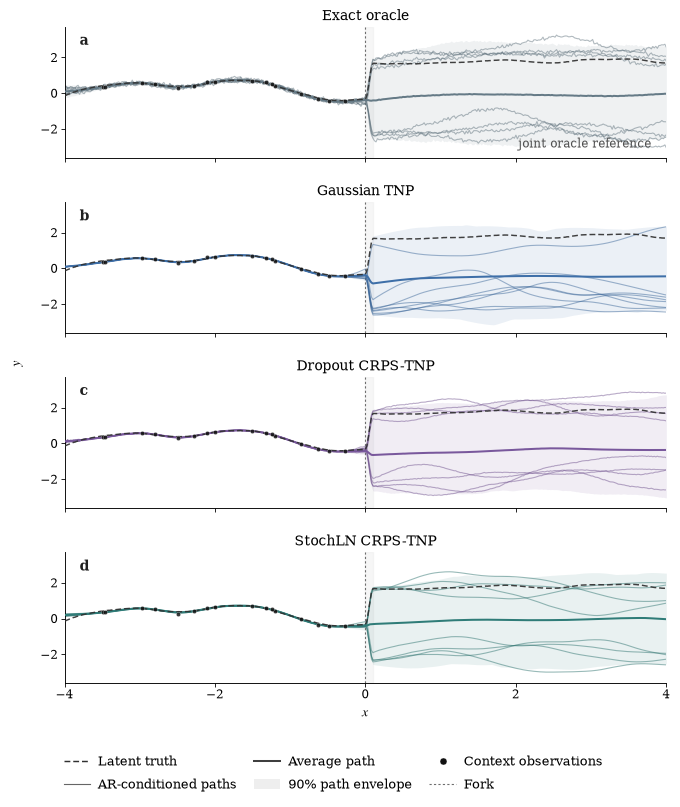

In [39]:
# Preview F3

bf_f3_fig, bf_f3_axes, bf_f3_y_limits = (
    make_binary_fork_coherence_figure(
        bf_f3_cache
    )
)

plt.show()


Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_ar_coherence_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_ar_coherence_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/binary_fork/notebook_exports/binary_fork_ar_coherence_v01_style.json


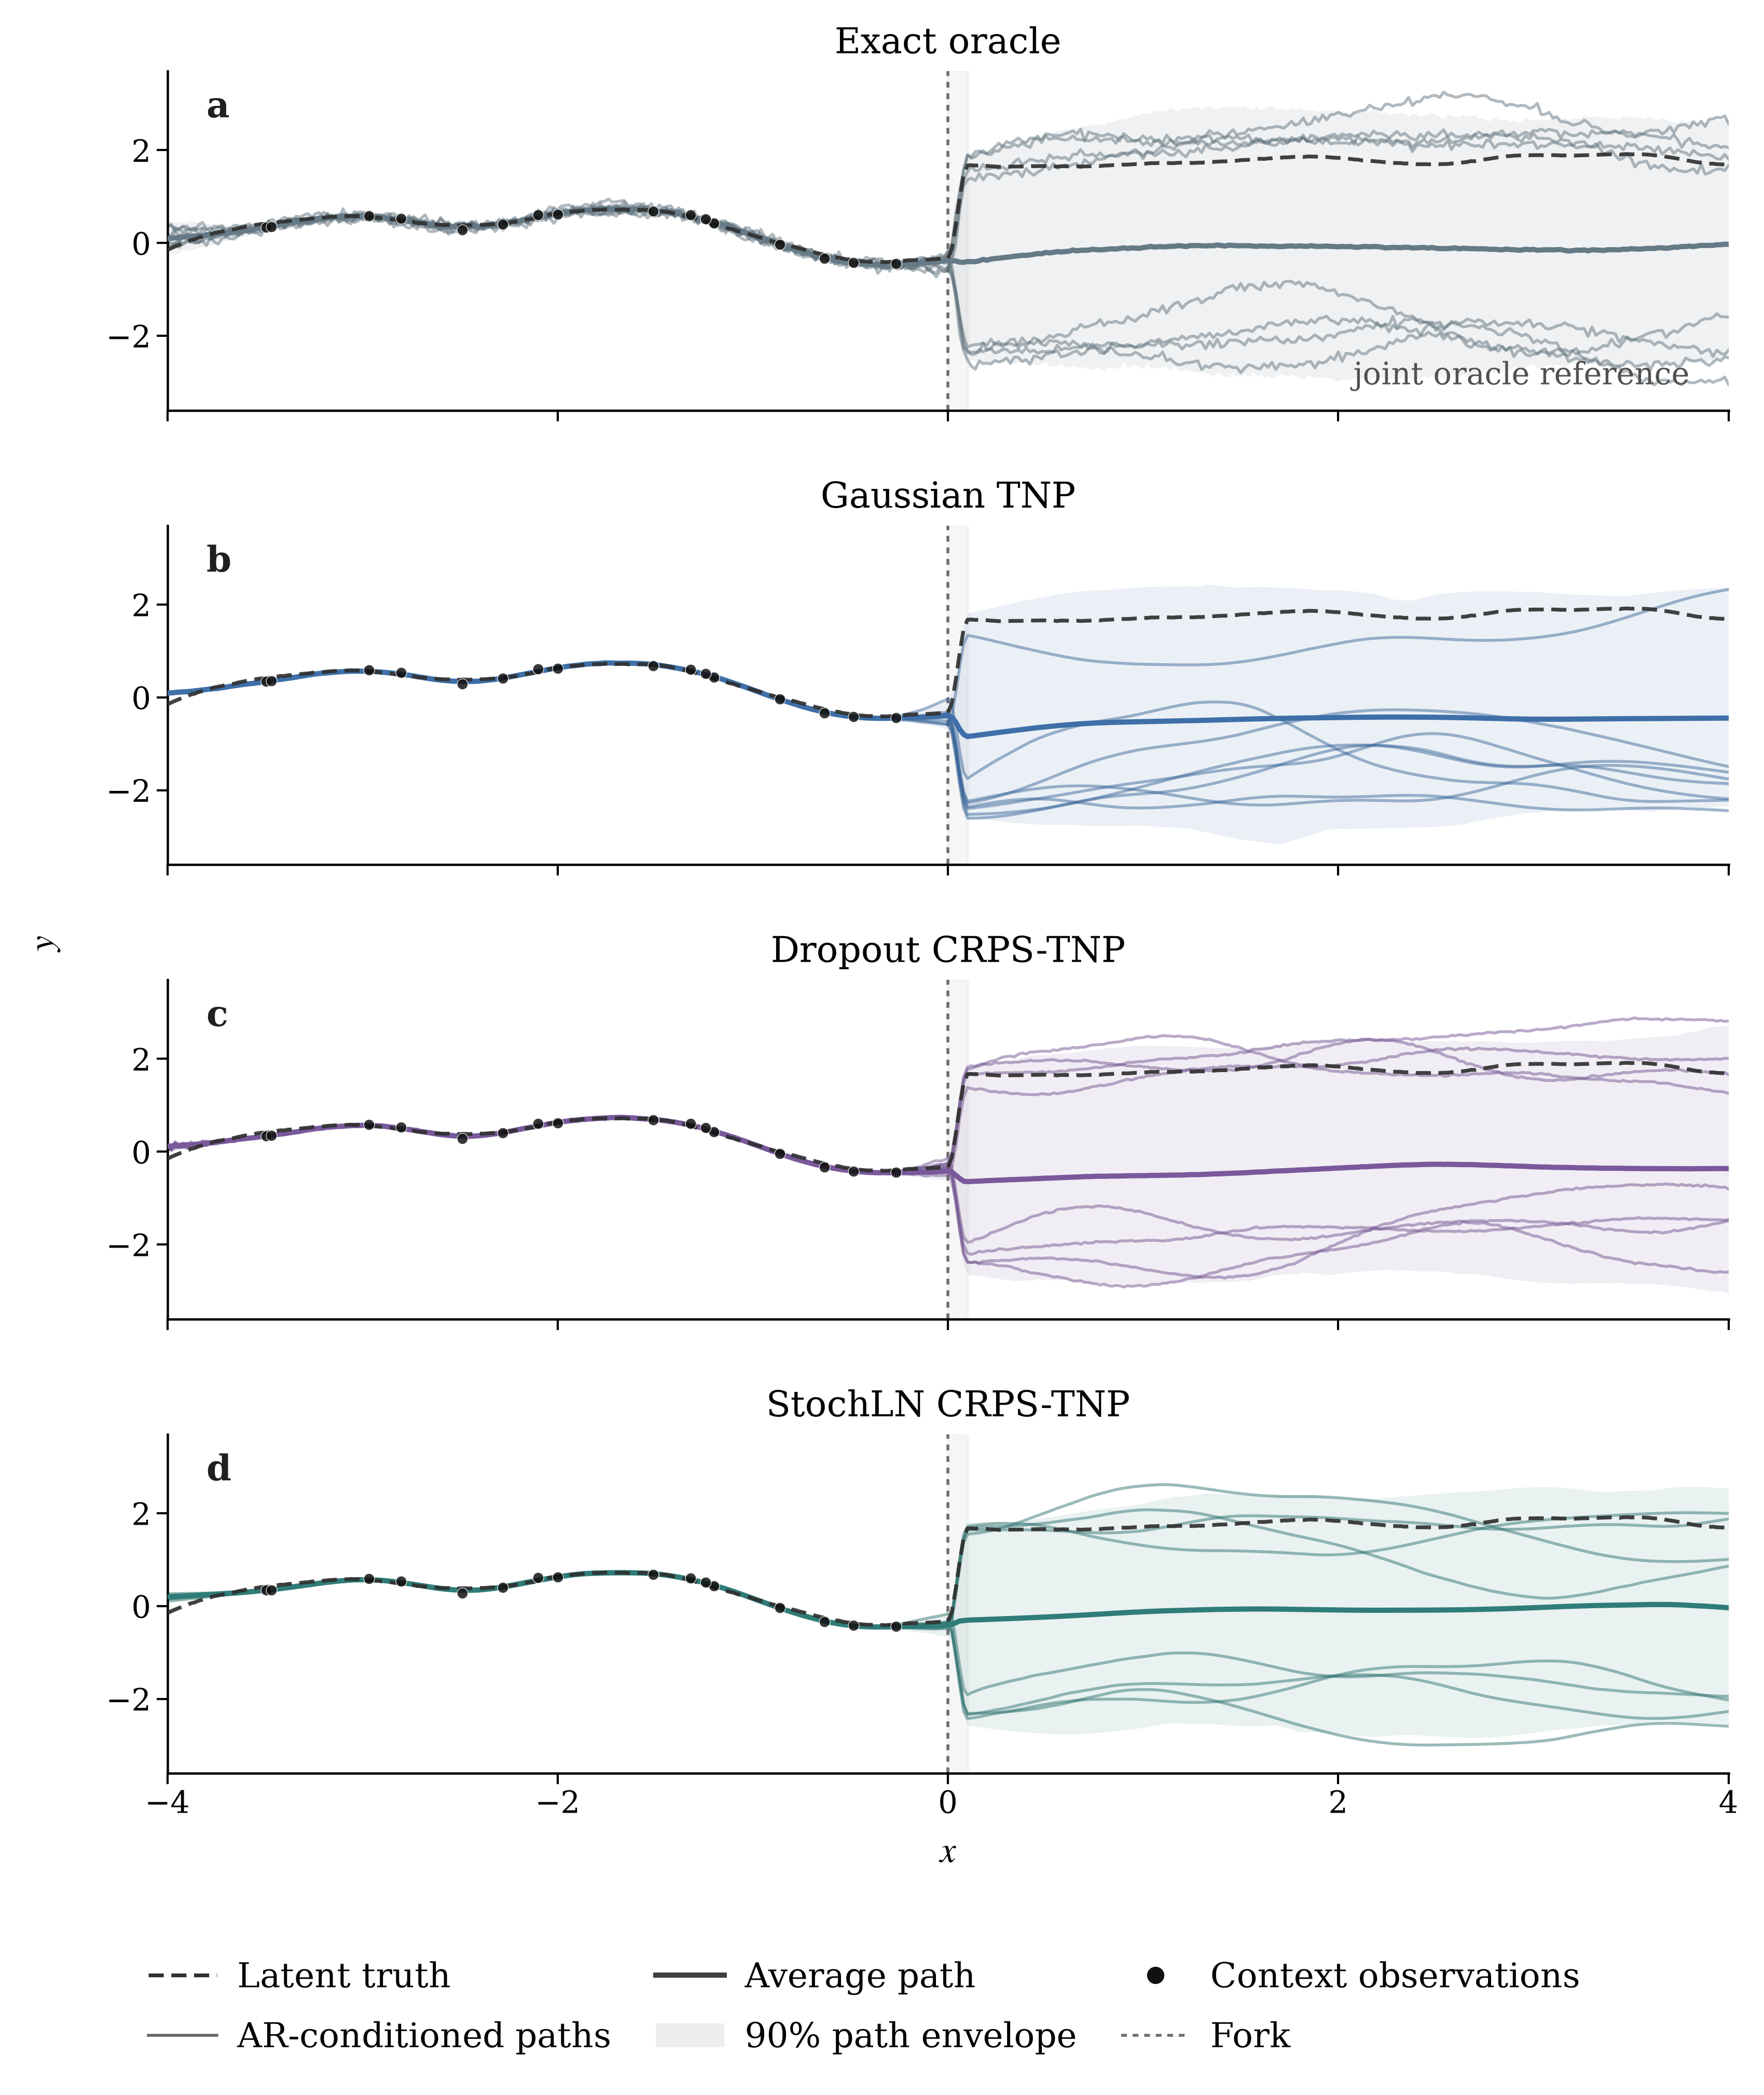

In [46]:
# Export F3

bf_export_figure(
    fig=bf_f3_fig,
    export_name=BF_F3_EXPORT_NAME,
    title="Binary latent fork: AR-conditioned function paths",
    style_snapshot={
        "cache_path": str(BF_F3_CACHE_PATH),
        "cache_metadata": bf_f3_cache["metadata"],
        "figsize": list(BF_F3_FIGSIZE),
        "dpi": BF_DPI,
        "column_order": BF_F3_COLUMN_ORDER,
        "visible_paths": BF_F3_VISIBLE_PATHS,
        "path_start_index": BF_F3_PATH_START_INDEX,
        "interval_level": BF_F3_INTERVAL_LEVEL,
        "path_alpha": BF_F3_PATH_ALPHA,
        "path_linewidth": BF_F3_PATH_LINEWIDTH,
        "mean_linewidth": BF_F3_MEAN_LINEWIDTH,
        "direct_band_alpha": BF_F3_DIRECT_BAND_ALPHA,
        "ar_band_alpha": BF_F3_AR_BAND_ALPHA,
        "show_paths": BF_F3_SHOW_PATHS,
        "show_mean": BF_F3_SHOW_MEAN,
        "show_bands": BF_F3_SHOW_BANDS,
        "show_latent_truth": BF_F3_SHOW_LATENT_TRUTH,
        "show_context": BF_F3_SHOW_CONTEXT,
        "show_panel_letters": BF_F3_SHOW_PANEL_LETTERS,
        "manual_x_lim": list(BF_F3_MANUAL_X_LIM),
        "manual_y_lim": (
            list(BF_F3_MANUAL_Y_LIM)
            if BF_F3_MANUAL_Y_LIM is not None
            else None
        ),
        "resolved_y_limits": list(bf_f3_y_limits),
        "fork_x": BF_FORK_X,
        "transition_end": BF_TRANSITION_END,
        "model_colours": BF_F3_COLOURS,
    },
)

plt.close(bf_f3_fig)


# Dissertation Figure Design: Sawtooth Optimisation

This section loads two frozen CPU caches and performs no model inference.

**F1 — Optimisation trajectories:** coordinate-representation control,
context-size concentration and the continuous context curriculum, all measured
against the same validation RMSE criteria.

**F2 — Autoregressive function paths:** Gaussian, Dropout and
Stochastic-LayerNorm curriculum models on two deterministically selected tasks:
one nearest the median learned-model AR difficulty and one nearest its 90th
percentile.

The quantitative marginal, loss-ablation and AR analyses remain separate. The
trajectory figure uses complete logged validation histories. The AR figure uses
frozen dense conditional-mean reconstructions generated from sparse-anchor
rollouts; the notebook only styles and exports them.


In [3]:
# Sawtooth cache paths and shared visual settings

SAW_CACHE_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "sawtooth"
    / "caches"
)

SAW_OUTPUT_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "sawtooth"
    / "notebook_exports"
)

SAW_TRAJECTORY_CACHE_PATH = (
    SAW_CACHE_DIR
    / "sawtooth_optimisation_trajectories_cache_v1.pt"
)

SAW_AR_CACHE_PATH = (
    SAW_CACHE_DIR
    / "sawtooth_ar_examples_cache_v1.pt"
)

SAW_TRAJECTORY_EXPORT_NAME = (
    "sawtooth_optimisation_trajectories_v01"
)

SAW_AR_EXPORT_NAME = (
    "sawtooth_ar_examples_v01"
)

SAW_DPI = 500

SAW_MODEL_ORDER = [
    "Gaussian curriculum",
    "Dropout curriculum",
    "StochLN curriculum",
]

SAW_MODEL_TITLES = {
    "Gaussian curriculum": "Gaussian TNP",
    "Dropout curriculum": "Dropout CRPS-TNP",
    "StochLN curriculum": "StochLN CRPS-TNP",
}

SAW_MODEL_COLOURS = {
    "Gaussian curriculum": MODEL_COLOURS["Gaussian TNP"],
    "Dropout curriculum": MODEL_COLOURS["Dropout CRPS-TNP"],
    "StochLN curriculum": MODEL_COLOURS["StochLN CRPS-TNP"],
}

SAW_TRUTH_COLOUR = TRUTH_COLOUR
SAW_CONTEXT_COLOUR = CONTEXT_COLOUR

SAW_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Sawtooth cache directory:", SAW_CACHE_DIR)
print("Sawtooth export directory:", SAW_OUTPUT_DIR)


Sawtooth cache directory: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/caches
Sawtooth export directory: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports


In [4]:
# Load and validate the frozen sawtooth trajectory cache

if not SAW_TRAJECTORY_CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cache not found:\n{SAW_TRAJECTORY_CACHE_PATH}\n\n"
        "Run experiments/cache_sawtooth_figures.py "
        "--figure trajectories first."
    )

saw_trajectory_cache = torch.load(
    SAW_TRAJECTORY_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)


def saw_tensor_devices(value) -> list[str]:
    devices = []

    if torch.is_tensor(value):
        devices.append(str(value.device))

    elif isinstance(value, dict):
        for child in value.values():
            devices.extend(saw_tensor_devices(child))

    elif isinstance(value, (list, tuple)):
        for child in value:
            devices.extend(saw_tensor_devices(child))

    return devices


if (
    saw_trajectory_cache.get("schema_version")
    != "sawtooth_trajectory_cache_v1"
):
    raise RuntimeError(
        "Unexpected trajectory cache schema: "
        f"{saw_trajectory_cache.get('schema_version')!r}."
    )

if bool(
    saw_trajectory_cache["metadata"].get(
        "smoke",
        False,
    )
):
    raise RuntimeError(
        "The trajectory cache is a smoke cache, not the final cache."
    )

required_trajectory_records = {
    "Gaussian raw x",
    "Gaussian Fourier",
    "Dropout variable Nc1-30",
    "Dropout variable Nc48-64",
    "Dropout fixed Nc64",
    "Dropout fixed Nc96",
    "Dropout fixed Nc128",
    "StochLN fixed Nc128",
    "Gaussian continuous curriculum",
    "Dropout continuous curriculum",
    "StochLN continuous curriculum",
}

missing_trajectory_records = (
    required_trajectory_records
    - set(saw_trajectory_cache["records"])
)

if missing_trajectory_records:
    raise RuntimeError(
        "Trajectory cache is missing records: "
        f"{sorted(missing_trajectory_records)}"
    )

for model_name in required_trajectory_records:
    record = saw_trajectory_cache["records"][model_name]

    epoch = record["epoch"]
    val_rmse = record["val_rmse"]

    if epoch.ndim != 1 or val_rmse.ndim != 1:
        raise RuntimeError(
            f"Unexpected trajectory rank for {model_name!r}."
        )

    if epoch.shape != val_rmse.shape:
        raise RuntimeError(
            f"Epoch/RMSE shape mismatch for {model_name!r}."
        )

    if not torch.isfinite(epoch).all():
        raise RuntimeError(
            f"Non-finite epochs for {model_name!r}."
        )

    if not torch.isfinite(val_rmse).all():
        raise RuntimeError(
            f"Non-finite validation RMSE for {model_name!r}."
        )

trajectory_boundaries = list(
    saw_trajectory_cache["metadata"]["stage_boundaries"]
)

if trajectory_boundaries != [200, 350]:
    raise RuntimeError(
        "Unexpected curriculum stage boundaries: "
        f"{trajectory_boundaries}."
    )

trajectory_validation_support = list(
    saw_trajectory_cache["metadata"]["validation_support"]
)

if trajectory_validation_support != [48, 64]:
    raise RuntimeError(
        "Unexpected curriculum validation support: "
        f"{trajectory_validation_support}."
    )

trajectory_devices = saw_tensor_devices(
    saw_trajectory_cache
)

if trajectory_devices and set(trajectory_devices) != {"cpu"}:
    raise RuntimeError(
        "Trajectory cache contains non-CPU tensors: "
        f"{sorted(set(trajectory_devices))}."
    )

print("Trajectory metadata:")
print(
    json.dumps(
        saw_trajectory_cache["metadata"],
        indent=2,
    )
)

print(
    "\nPASS: final sawtooth trajectory cache is valid and CPU-only."
)


Trajectory metadata:
{
  "config_path": "experiments/configs/evaluation/sawtooth/sawtooth_figures_final.yml",
  "runtime_metadata": {
    "created_unix_time": 1785843124.5308611,
    "hostname": "simpson",
    "python": "3.12.3",
    "torch": "2.11.0+cu128",
    "device": "cpu",
    "repo_commit": "1e88ac57d2393e13dcb3d7f695e41cfd2c6299fa",
    "repo_branch": "main",
    "tnp_submodule_commit": "1f60200a5879bf1f77e63eb1427a61da7932f5c2",
    "git_status_short": "?? README_BINARY_FORK_FIGURE_CACHES.md\n?? sawtooth_final_evaluation_v1_bundle.zip\n?? sawtooth_final_evaluation_v1_bundle/"
  },
  "history_csv": "results/sawtooth/trajectories_final_20260803_v1/sawtooth_trajectory_history.csv",
  "summary_csv": "results/sawtooth/trajectories_final_20260803_v1/sawtooth_trajectory_summary.csv",
  "stage_boundaries": [
    200,
    350
  ],
  "validation_support": [
    48,
    64
  ],
  "smoke": false
}

PASS: final sawtooth trajectory cache is valid and CPU-only.


In [5]:
# Shared sawtooth plotting and export helpers


def saw_to_1d(value: torch.Tensor) -> np.ndarray:
    return (
        value.detach()
        .cpu()
        .reshape(-1)
        .numpy()
    )


def saw_central_interval(
    paths: torch.Tensor,
    level: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    lower_probability = (1.0 - float(level)) / 2.0
    upper_probability = 1.0 - lower_probability

    lower = torch.quantile(
        paths,
        lower_probability,
        dim=0,
    )

    upper = torch.quantile(
        paths,
        upper_probability,
        dim=0,
    )

    return lower, upper


def saw_select_visible_paths(
    paths: torch.Tensor,
    *,
    visible_paths: int,
    start_index: int,
) -> torch.Tensor:
    available = int(paths.shape[0])
    count = min(int(visible_paths), available)
    start = int(start_index)

    if start < 0:
        raise ValueError("start_index cannot be negative.")

    if start + count > available:
        start = max(0, available - count)

    return paths[start : start + count]


def saw_darken_colour(
    colour,
    amount: float,
) -> tuple[float, float, float]:
    rgb = np.asarray(
        mpl.colors.to_rgb(colour),
        dtype=float,
    )

    darkened = np.clip(
        rgb * (1.0 - float(amount)),
        0.0,
        1.0,
    )

    return tuple(darkened)


def saw_export_figure(
    *,
    fig: plt.Figure,
    export_name: str,
    title: str,
    style_snapshot: dict,
) -> tuple[Path, Path, Path]:
    SAW_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    pdf_path = SAW_OUTPUT_DIR / f"{export_name}.pdf"
    png_path = SAW_OUTPUT_DIR / f"{export_name}.png"
    style_path = SAW_OUTPUT_DIR / f"{export_name}_style.json"

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
        metadata={
            "Title": title,
            "Creator": (
                "tnp-crps dissertation figure-design notebook"
            ),
        },
    )

    fig.savefig(
        png_path,
        dpi=SAW_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    style_path.write_text(
        json.dumps(
            {
                "export_name": export_name,
                "title": title,
                **style_snapshot,
            },
            indent=2,
            default=str,
        )
    )

    print("Wrote:", pdf_path)
    print("Wrote:", png_path)
    print("Wrote:", style_path)

    display(
        Image(
            filename=str(png_path),
            width=1100,
        )
    )

    return pdf_path, png_path, style_path


In [28]:
# F1: optimisation trajectories

# Taller figure so that:
# - the context-panel legend has a dedicated band between panels (b) and (c);
# - the curriculum-model legend sits below panel (c);
# - the reference legend occupies a separate bottom band.
SAW_TRAJ_FIGSIZE = (8.6, 7.8)

SAW_TRAJ_MANUAL_X_LIM = (0.0, 500.0)
SAW_TRAJ_MANUAL_Y_LIM = (0.02, 0.48)

SAW_TRAJ_LINEWIDTH = 1.45
SAW_TRAJ_MARKER_SIZE = 4.6
SAW_TRAJ_SHOW_ESCAPE_MARKERS = True

SAW_TRAJ_CLIMATOLOGY_RMSE = float(
    np.sqrt(1.0 / 12.0)
)
SAW_TRAJ_ESCAPE_THRESHOLD = 0.25

SAW_TRAJ_REFERENCE_LINEWIDTH = 0.95
SAW_TRAJ_STAGE_LINEWIDTH = 0.85
SAW_TRAJ_STAGE_ALPHA = 0.045

SAW_TRAJ_TITLE_SIZE = 11.5
SAW_TRAJ_PANEL_LABEL_SIZE = 10.5
SAW_TRAJ_AXIS_LABEL_SIZE = 10.5
SAW_TRAJ_LEGEND_FONT_SIZE = 8.6
SAW_TRAJ_REFERENCE_LEGEND_FONT_SIZE = 9.1
SAW_TRAJ_STAGE_LABEL_SIZE = 8.2

# ---------------------------------------------------------------------
# Layout controls
# ---------------------------------------------------------------------

SAW_TRAJ_GRID_HEIGHT_RATIOS = [
    1.00,  # panel (a)
    0.28,  # more space above panel (b) title
    1.00,  # panel (b)
    0.32,  # context-size legend
    0.24,  # more space above panel (c) title
    1.00,  # panel (c)
    0.10,  # shared x-axis label
    0.20,  # curriculum-model legend
    0.17,  # reference legend
]

SAW_TRAJ_GRID_LEFT = 0.090
SAW_TRAJ_GRID_RIGHT = 0.995
SAW_TRAJ_GRID_TOP = 0.975
SAW_TRAJ_GRID_BOTTOM = 0.035

# Position within each dedicated legend axis.
SAW_TRAJ_CONTEXT_LEGEND_Y = 0.58
SAW_TRAJ_CURRICULUM_LEGEND_Y = 0.52
SAW_TRAJ_REFERENCE_LEGEND_Y = 0.52

SAW_TRAJ_PANEL_SPECS = [
    {
        "key": "representation",
        "title": "Coordinate representation",
        "records": [
            "Gaussian raw x",
            "Gaussian Fourier",
        ],
    },
    {
        "key": "context",
        "title": "Context-size concentration",
        "records": [
            "Dropout variable Nc1-30",
            "Dropout variable Nc48-64",
            "Dropout fixed Nc64",
            "Dropout fixed Nc96",
            "Dropout fixed Nc128",
            "StochLN fixed Nc128",
        ],
    },
    {
        "key": "curriculum",
        "title": "Continuous context-size curriculum",
        "records": [
            "Gaussian continuous curriculum",
            "Dropout continuous curriculum",
            "StochLN continuous curriculum",
        ],
    },
]

SAW_TRAJ_STYLES = {
    "Gaussian raw x": {
        "label": r"Gaussian, raw $x$",
        "colour": "#6B6B6B",
        "linestyle": (0, (4, 2)),
    },
    "Gaussian Fourier": {
        "label": "Gaussian, Fourier",
        "colour": MODEL_COLOURS["Gaussian TNP"],
        "linestyle": "-",
    },
    "Dropout variable Nc1-30": {
        "label": r"Dropout, $N_c\in[1,30]$",
        "colour": "#C5B0D5",
        "linestyle": (0, (4, 2)),
    },
    "Dropout variable Nc48-64": {
        "label": r"Dropout, $N_c\in[48,64]$",
        "colour": "#9467BD",
        "linestyle": (0, (4, 2)),
    },
    "Dropout fixed Nc64": {
        "label": r"Dropout, fixed $N_c=64$",
        "colour": "#B39DDB",
        "linestyle": "-",
    },
    "Dropout fixed Nc96": {
        "label": r"Dropout, fixed $N_c=96$",
        "colour": "#7E57C2",
        "linestyle": "-",
    },
    "Dropout fixed Nc128": {
        "label": r"Dropout, fixed $N_c=128$",
        "colour": "#512DA8",
        "linestyle": "-",
    },
    "StochLN fixed Nc128": {
        "label": r"StochLN, fixed $N_c=128$",
        "colour": MODEL_COLOURS["StochLN CRPS-TNP"],
        "linestyle": (0, (2, 1)),
    },
    "Gaussian continuous curriculum": {
        "label": "Gaussian TNP",
        "colour": MODEL_COLOURS["Gaussian TNP"],
        "linestyle": "-",
    },
    "Dropout continuous curriculum": {
        "label": "Dropout CRPS-TNP",
        "colour": MODEL_COLOURS["Dropout CRPS-TNP"],
        "linestyle": "-",
    },
    "StochLN continuous curriculum": {
        "label": "StochLN CRPS-TNP",
        "colour": MODEL_COLOURS["StochLN CRPS-TNP"],
        "linestyle": "-",
    },
}

SAW_TRAJ_STAGE_SPECS = [
    {
        "start": 0,
        "end": 200,
        "label": r"fixed $N_c=64$",
        "colour": "#4C78A8",
    },
    {
        "start": 200,
        "end": 350,
        "label": r"$N_c\in[56,64]$",
        "colour": "#F2CF5B",
    },
    {
        "start": 350,
        "end": 500,
        "label": r"$N_c\in[48,64]$",
        "colour": "#59A14F",
    },
]

In [29]:
# F1 plotting function: optimisation trajectories with asymmetric layout


def make_sawtooth_trajectory_figure(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray]:
    records = cache["records"]

    summary_by_name = {
        str(row["model_name"]): row
        for row in cache["summary"]
    }

    panel_legend_data = {}

    with mpl.rc_context(
        DISSERTATION_RC
    ):
        # -------------------------------------------------------------
        # Figure and asymmetric GridSpec
        # -------------------------------------------------------------

        fig = plt.figure(
            figsize=SAW_TRAJ_FIGSIZE,
            constrained_layout=False,
        )

        grid = fig.add_gridspec(
            nrows=9,
            ncols=1,
            height_ratios=(
                SAW_TRAJ_GRID_HEIGHT_RATIOS
            ),
            left=SAW_TRAJ_GRID_LEFT,
            right=SAW_TRAJ_GRID_RIGHT,
            top=SAW_TRAJ_GRID_TOP,
            bottom=SAW_TRAJ_GRID_BOTTOM,
            hspace=0.0,
        )

        ax_a = fig.add_subplot(
            grid[0, 0]
        )
        
        ax_b = fig.add_subplot(
            grid[2, 0],
            sharex=ax_a,
            sharey=ax_a,
        )
        
        # Row 4 is intentionally left empty to separate the context legend
        # from the title of panel (c).
        ax_c = fig.add_subplot(
            grid[5, 0],
            sharex=ax_a,
            sharey=ax_a,
        )
        
        axes = np.asarray(
            [
                ax_a,
                ax_b,
                ax_c,
            ],
            dtype=object,
        )
        
        context_legend_ax = fig.add_subplot(
            grid[3, 0]
        )
        
        x_label_ax = fig.add_subplot(
            grid[6, 0]
        )
        
        curriculum_legend_ax = fig.add_subplot(
            grid[7, 0]
        )
        
        reference_legend_ax = fig.add_subplot(
            grid[8, 0]
        )

        for auxiliary_ax in (
            context_legend_ax,
            x_label_ax,
            curriculum_legend_ax,
            reference_legend_ax,
        ):
            auxiliary_ax.set_axis_off()

        # -------------------------------------------------------------
        # Main panels
        # -------------------------------------------------------------

        for panel_index, panel_spec in enumerate(
            SAW_TRAJ_PANEL_SPECS
        ):
            ax = axes[
                panel_index
            ]

            panel_key = panel_spec[
                "key"
            ]

            # ---------------------------------------------------------
            # Curriculum stage backgrounds and boundaries
            # ---------------------------------------------------------

            if panel_key == "curriculum":
                for stage in SAW_TRAJ_STAGE_SPECS:
                    ax.axvspan(
                        float(
                            stage["start"]
                        ),
                        float(
                            stage["end"]
                        ),
                        color=stage[
                            "colour"
                        ],
                        alpha=(
                            SAW_TRAJ_STAGE_ALPHA
                        ),
                        zorder=0,
                    )

                for boundary in (
                    200,
                    350,
                ):
                    ax.axvline(
                        float(
                            boundary
                        ),
                        color="#777777",
                        linewidth=(
                            SAW_TRAJ_STAGE_LINEWIDTH
                        ),
                        linestyle=(
                            0,
                            (
                                3,
                                2,
                            ),
                        ),
                        zorder=1,
                    )

            # ---------------------------------------------------------
            # Shared reference lines
            # ---------------------------------------------------------

            ax.axhline(
                SAW_TRAJ_CLIMATOLOGY_RMSE,
                color="#777777",
                linewidth=(
                    SAW_TRAJ_REFERENCE_LINEWIDTH
                ),
                linestyle=(
                    0,
                    (
                        5,
                        2,
                    ),
                ),
                zorder=1,
            )

            ax.axhline(
                SAW_TRAJ_ESCAPE_THRESHOLD,
                color="#999999",
                linewidth=(
                    SAW_TRAJ_REFERENCE_LINEWIDTH
                ),
                linestyle=":",
                zorder=1,
            )

            # ---------------------------------------------------------
            # Model trajectories
            # ---------------------------------------------------------

            for model_name in panel_spec[
                "records"
            ]:
                record = records[
                    model_name
                ]

                style = SAW_TRAJ_STYLES[
                    model_name
                ]

                epoch = saw_to_1d(
                    record["epoch"]
                )

                val_rmse = saw_to_1d(
                    record["val_rmse"]
                )

                finite = (
                    np.isfinite(
                        epoch
                    )
                    & np.isfinite(
                        val_rmse
                    )
                )

                epoch = epoch[
                    finite
                ]

                val_rmse = val_rmse[
                    finite
                ]

                ax.plot(
                    epoch,
                    val_rmse,
                    color=style[
                        "colour"
                    ],
                    linewidth=(
                        SAW_TRAJ_LINEWIDTH
                    ),
                    linestyle=style[
                        "linestyle"
                    ],
                    label=style[
                        "label"
                    ],
                    zorder=3,
                )

                if SAW_TRAJ_SHOW_ESCAPE_MARKERS:
                    summary = summary_by_name.get(
                        model_name,
                        {},
                    )

                    escape_epoch = summary.get(
                        "rmse_escape_epoch"
                    )

                    if (
                        escape_epoch is not None
                        and np.isfinite(
                            float(
                                escape_epoch
                            )
                        )
                    ):
                        escape_epoch = float(
                            escape_epoch
                        )

                        marker_index = int(
                            np.argmin(
                                np.abs(
                                    epoch
                                    - escape_epoch
                                )
                            )
                        )

                        ax.scatter(
                            [
                                epoch[
                                    marker_index
                                ]
                            ],
                            [
                                val_rmse[
                                    marker_index
                                ]
                            ],
                            s=(
                                SAW_TRAJ_MARKER_SIZE
                                ** 2
                            ),
                            facecolor=style[
                                "colour"
                            ],
                            edgecolor="white",
                            linewidth=0.45,
                            zorder=5,
                        )

            # Store model legend handles separately for each panel.
            handles, labels = (
                ax.get_legend_handles_labels()
            )

            panel_legend_data[
                panel_key
            ] = (
                handles,
                labels,
            )

            # ---------------------------------------------------------
            # Axis formatting
            # ---------------------------------------------------------

            ax.set_xlim(
                *SAW_TRAJ_MANUAL_X_LIM
            )

            ax.set_ylim(
                *SAW_TRAJ_MANUAL_Y_LIM
            )

            ax.set_xticks(
                [
                    0,
                    100,
                    200,
                    300,
                    400,
                    500,
                ]
            )

            ax.grid(
                False
            )

            ax.spines[
                "top"
            ].set_visible(
                False
            )

            ax.spines[
                "right"
            ].set_visible(
                False
            )

            ax.tick_params(
                axis="both",
                width=0.60,
                length=3.0,
                pad=1.5,
            )

            ax.set_title(
                panel_spec[
                    "title"
                ],
                fontsize=(
                    SAW_TRAJ_TITLE_SIZE
                ),
                pad=5,
            )

            ax.text(
                0.018,
                0.965,
                string.ascii_lowercase[
                    panel_index
                ],
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=(
                    SAW_TRAJ_PANEL_LABEL_SIZE
                ),
                fontweight="bold",
                color="#202020",
                zorder=10,
            )

            # Only the final panel displays x tick labels.
            if panel_index < 2:
                ax.tick_params(
                    labelbottom=False
                )

            # ---------------------------------------------------------
            # Panel-specific annotations
            # ---------------------------------------------------------

            if panel_key == "representation":
                ax.legend(
                    handles=handles,
                    labels=labels,
                    loc="lower left",
                    ncol=2,
                    frameon=False,
                    fontsize=(
                        SAW_TRAJ_LEGEND_FONT_SIZE
                    ),
                    handlelength=2.1,
                    handletextpad=0.55,
                    columnspacing=0.95,
                )

            if panel_key == "curriculum":
                y_top = (
                    SAW_TRAJ_MANUAL_Y_LIM[
                        1
                    ]
                )

                y_span = (
                    SAW_TRAJ_MANUAL_Y_LIM[
                        1
                    ]
                    - SAW_TRAJ_MANUAL_Y_LIM[
                        0
                    ]
                )

                label_y = (
                    y_top
                    - 0.035
                    * y_span
                )

                for stage in SAW_TRAJ_STAGE_SPECS:
                    midpoint = 0.5 * (
                        float(
                            stage["start"]
                        )
                        + float(
                            stage["end"]
                        )
                    )

                    ax.text(
                        midpoint,
                        label_y,
                        stage[
                            "label"
                        ],
                        ha="center",
                        va="top",
                        fontsize=(
                            SAW_TRAJ_STAGE_LABEL_SIZE
                        ),
                        color="#505050",
                    )

        # -------------------------------------------------------------
        # Context-size legend in its dedicated row
        # -------------------------------------------------------------

        (
            context_handles,
            context_labels,
        ) = panel_legend_data[
            "context"
        ]

        context_legend_ax.legend(
            handles=context_handles,
            labels=context_labels,
            loc="center",
            bbox_to_anchor=(
                0.5,
                SAW_TRAJ_CONTEXT_LEGEND_Y,
            ),
            ncol=3,
            frameon=False,
            fontsize=(
                SAW_TRAJ_LEGEND_FONT_SIZE
            ),
            handlelength=2.1,
            handletextpad=0.55,
            columnspacing=0.95,
            labelspacing=0.58,
        )

        # -------------------------------------------------------------
        # Shared labels
        # -------------------------------------------------------------

        x_label_ax.text(
            0.5,
            0.58,
            "Epoch",
            va="center",
            ha="center",
            fontsize=(
                SAW_TRAJ_AXIS_LABEL_SIZE
            ),
        )

        fig.text(
            0.035,
            0.575,
            "Validation RMSE",
            rotation=90,
            va="center",
            ha="center",
            fontsize=(
                SAW_TRAJ_AXIS_LABEL_SIZE
            ),
        )

        # -------------------------------------------------------------
        # Curriculum legend in a dedicated row
        # -------------------------------------------------------------

        (
            curriculum_handles,
            curriculum_labels,
        ) = panel_legend_data[
            "curriculum"
        ]

        curriculum_legend_ax.legend(
            handles=curriculum_handles,
            labels=curriculum_labels,
            loc="center",
            bbox_to_anchor=(
                0.5,
                SAW_TRAJ_CURRICULUM_LEGEND_Y,
            ),
            ncol=3,
            frameon=False,
            fontsize=(
                SAW_TRAJ_LEGEND_FONT_SIZE
            ),
            handlelength=2.1,
            handletextpad=0.55,
            columnspacing=1.10,
        )

        # -------------------------------------------------------------
        # Shared reference legend in the final row
        # -------------------------------------------------------------

        reference_handles = [
            Line2D(
                [0],
                [0],
                color="#777777",
                linewidth=(
                    SAW_TRAJ_REFERENCE_LINEWIDTH
                ),
                linestyle=(
                    0,
                    (
                        5,
                        2,
                    ),
                ),
                label=(
                    r"$U(0,1)$ "
                    r"climatology RMSE"
                ),
            ),
            Line2D(
                [0],
                [0],
                color="#999999",
                linewidth=(
                    SAW_TRAJ_REFERENCE_LINEWIDTH
                ),
                linestyle=":",
                label=(
                    "Sustained-escape "
                    "threshold"
                ),
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor="#555555",
                markeredgecolor="white",
                markeredgewidth=0.45,
                markersize=5.0,
                label="Escape epoch",
            ),
        ]

        reference_legend_ax.legend(
            handles=reference_handles,
            loc="center",
            bbox_to_anchor=(
                0.5,
                SAW_TRAJ_REFERENCE_LEGEND_Y,
            ),
            ncol=3,
            frameon=False,
            fontsize=(
                SAW_TRAJ_REFERENCE_LEGEND_FONT_SIZE
            ),
            handlelength=2.1,
            handletextpad=0.55,
            columnspacing=1.25,
        )

        return (
            fig,
            axes,
        )

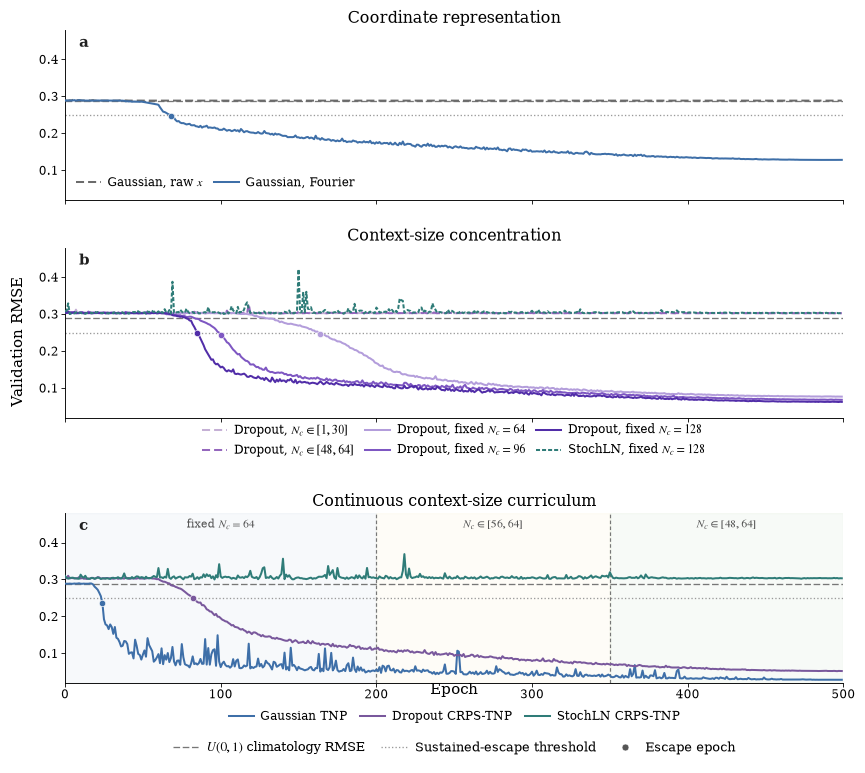

In [30]:
# Preview F1

saw_traj_fig, saw_traj_axes = (
    make_sawtooth_trajectory_figure(
        saw_trajectory_cache
    )
)

plt.show()


Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports/sawtooth_optimisation_trajectories_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports/sawtooth_optimisation_trajectories_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports/sawtooth_optimisation_trajectories_v01_style.json


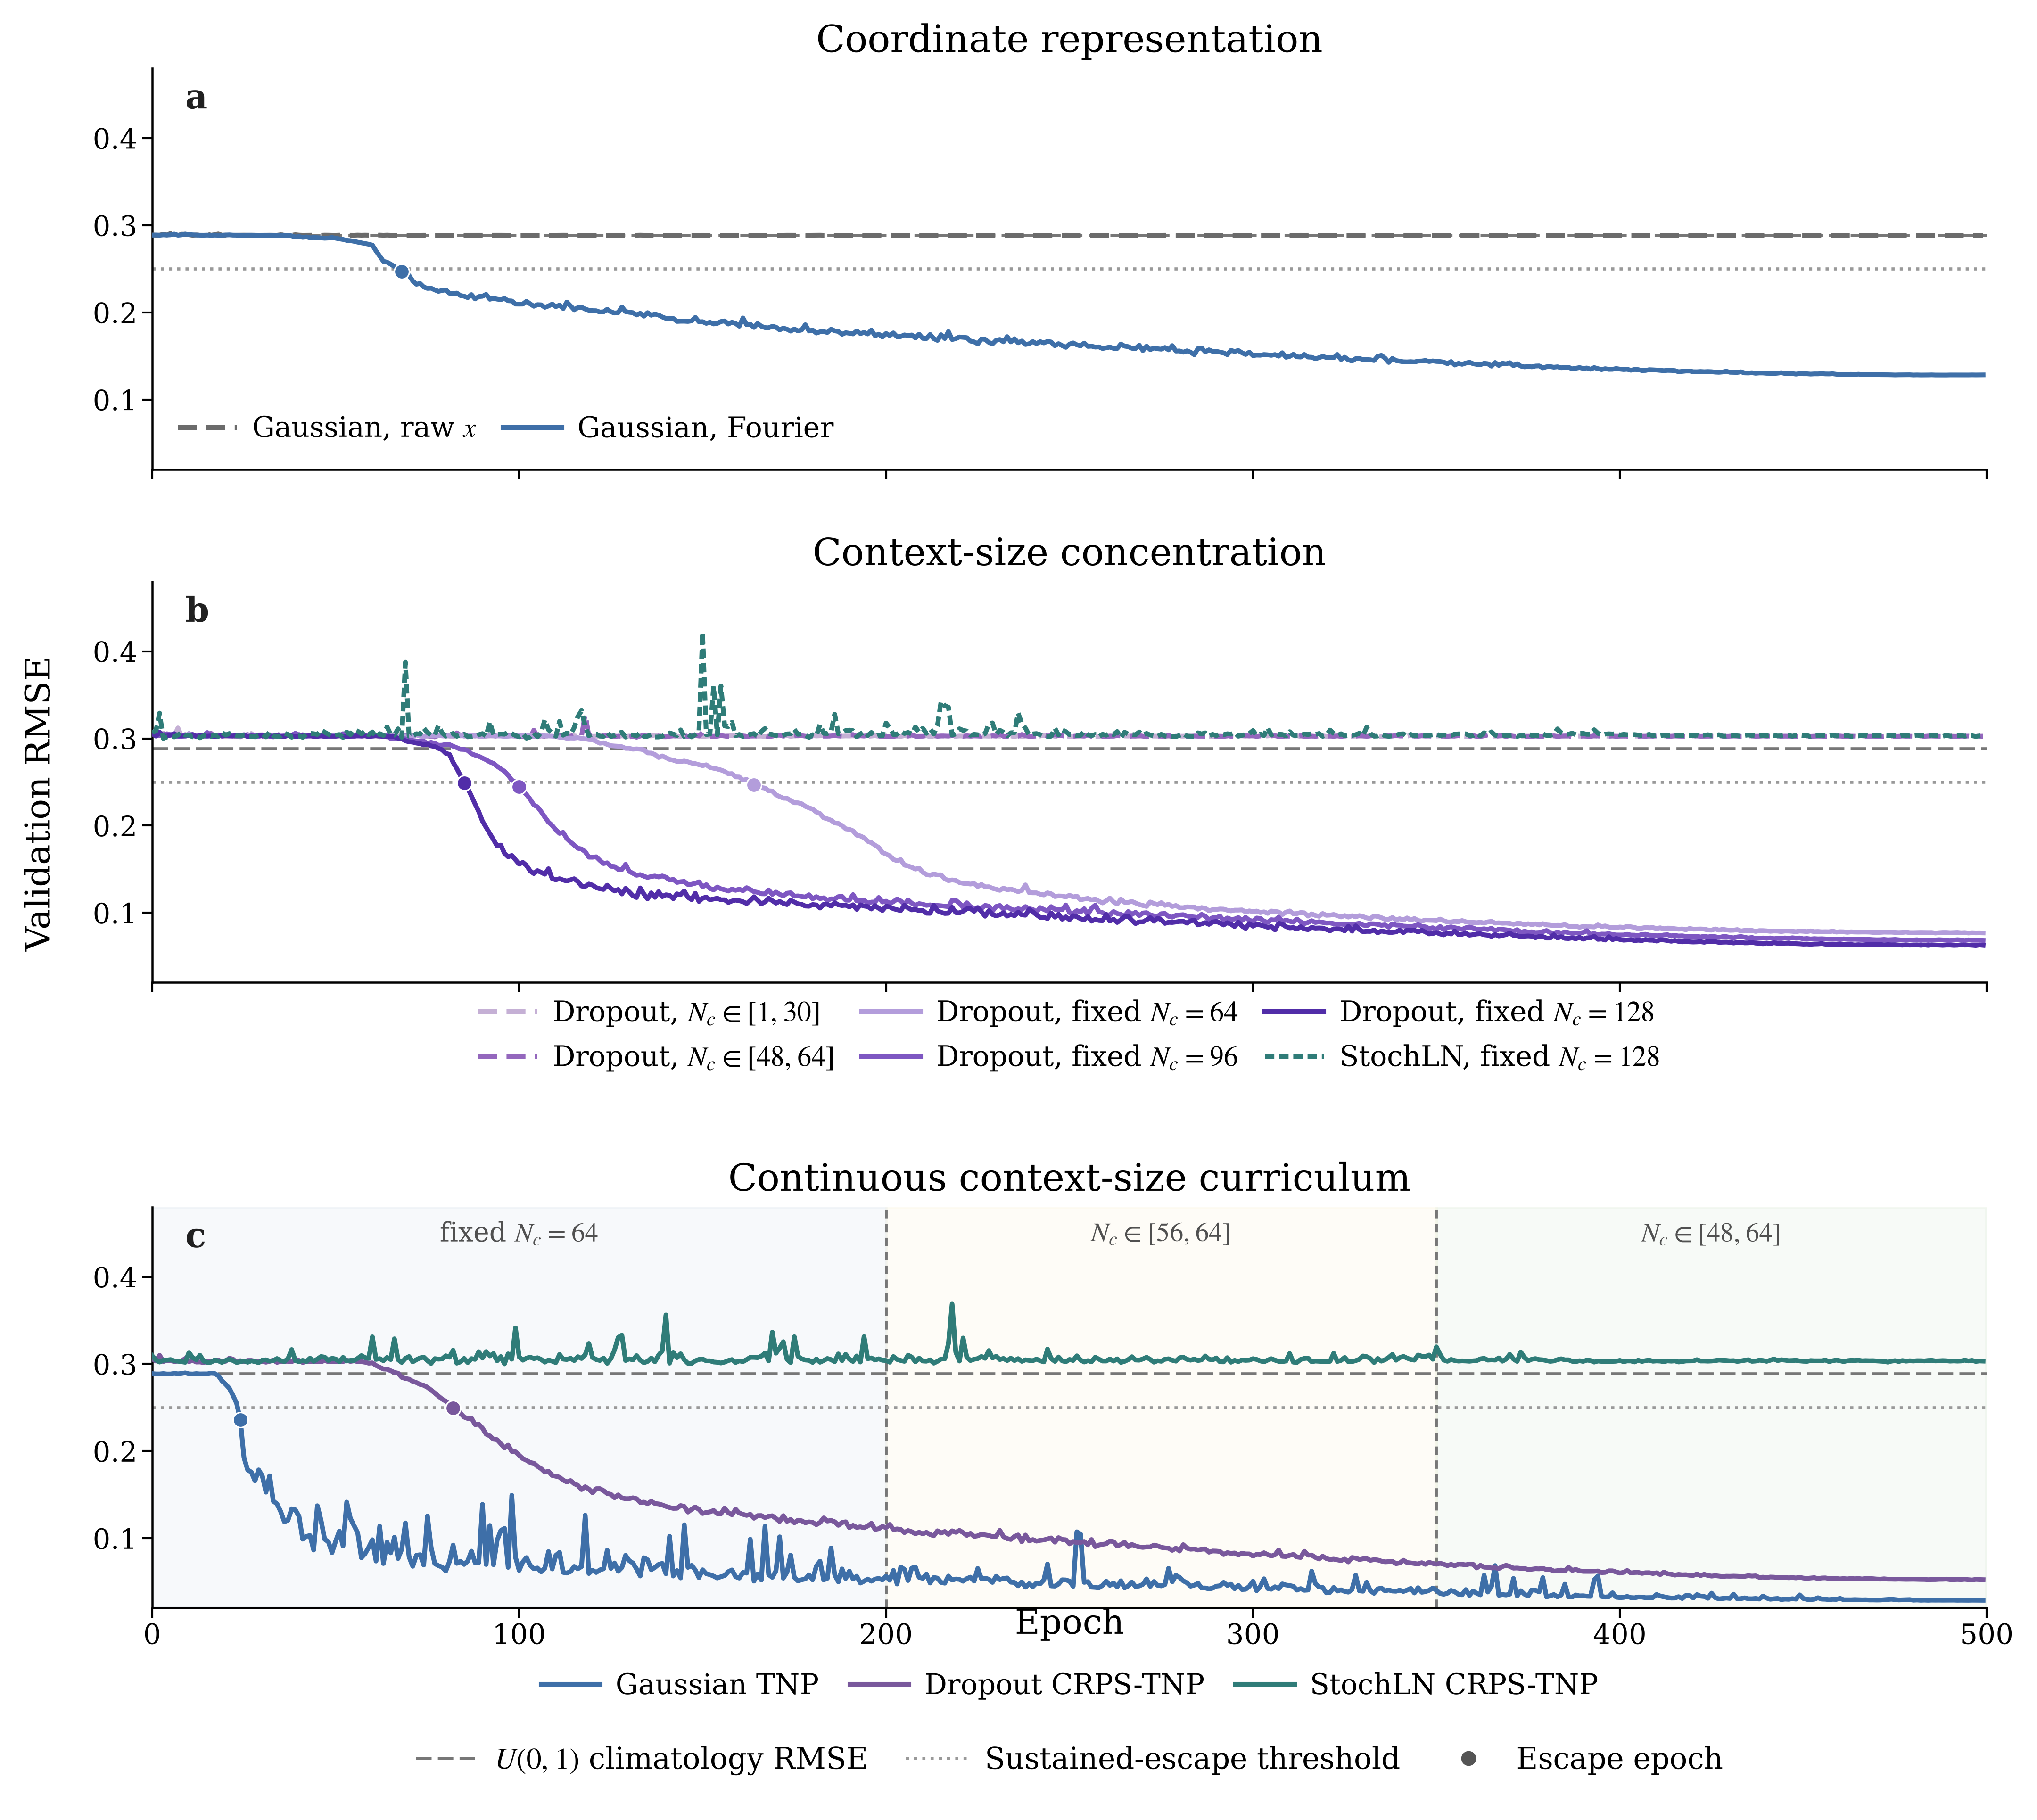

In [31]:
# Export F1

saw_export_figure(
    fig=saw_traj_fig,
    export_name=SAW_TRAJECTORY_EXPORT_NAME,
    title="Sawtooth optimisation trajectories",
    style_snapshot={
        "cache_path": str(SAW_TRAJECTORY_CACHE_PATH),
        "cache_metadata": saw_trajectory_cache["metadata"],
        "figsize": list(SAW_TRAJ_FIGSIZE),
        "dpi": SAW_DPI,
        "manual_x_lim": list(SAW_TRAJ_MANUAL_X_LIM),
        "manual_y_lim": list(SAW_TRAJ_MANUAL_Y_LIM),
        "climatology_rmse": SAW_TRAJ_CLIMATOLOGY_RMSE,
        "escape_threshold": SAW_TRAJ_ESCAPE_THRESHOLD,
        "stage_boundaries": [200, 350],
        "panel_specs": SAW_TRAJ_PANEL_SPECS,
        "trajectory_styles": SAW_TRAJ_STYLES,
        "layout": {
            "figure_size": list(SAW_TRAJ_FIGSIZE),
            "grid_height_ratios": list(SAW_TRAJ_GRID_HEIGHT_RATIOS),
            "grid_left": (SAW_TRAJ_GRID_LEFT),
            "grid_right": (SAW_TRAJ_GRID_RIGHT),
            "grid_top": (SAW_TRAJ_GRID_TOP),
            "grid_bottom": (SAW_TRAJ_GRID_BOTTOM),
            "context_legend_y": (SAW_TRAJ_CONTEXT_LEGEND_Y),
            "curriculum_legend_y": (SAW_TRAJ_CURRICULUM_LEGEND_Y),
            "reference_legend_y": (SAW_TRAJ_REFERENCE_LEGEND_Y),
        },
    },
)

plt.close(saw_traj_fig)

In [13]:
# F2: load the final AR cache and define matched-example controls

if not SAW_AR_CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cache not found:\n{SAW_AR_CACHE_PATH}\n\n"
        "Run the final AR evaluation and analysis, then run "
        "experiments/cache_sawtooth_figures.py --figure ar."
    )

saw_ar_cache = torch.load(
    SAW_AR_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

if (
    saw_ar_cache.get("schema_version")
    != "sawtooth_ar_figure_cache_v1"
):
    raise RuntimeError(
        "Unexpected AR cache schema: "
        f"{saw_ar_cache.get('schema_version')!r}."
    )

if bool(
    saw_ar_cache["metadata"].get(
        "smoke",
        False,
    )
):
    raise RuntimeError(
        "The AR cache is a smoke cache, not the final cache."
    )

expected_task_labels = {
    "representative",
    "difficult",
}

if set(saw_ar_cache["tasks"]) != expected_task_labels:
    raise RuntimeError(
        "Unexpected AR task labels: "
        f"{sorted(saw_ar_cache['tasks'])}."
    )

for task_label in expected_task_labels:
    task = saw_ar_cache["tasks"][task_label]

    if set(task["models"]) != set(SAW_MODEL_ORDER):
        raise RuntimeError(
            f"Unexpected model keys for task={task_label!r}."
        )

    x_plot = task["x_plot"]
    latent_truth = task["latent_truth"]

    if x_plot.ndim != 3:
        raise RuntimeError(
            f"Unexpected x_plot rank for task={task_label!r}."
        )

    if latent_truth.shape != x_plot.shape:
        raise RuntimeError(
            f"Truth/x_plot shape mismatch for task={task_label!r}."
        )

    if not torch.isfinite(latent_truth).all():
        raise RuntimeError(
            f"Non-finite truth for task={task_label!r}."
        )

    for model_name in SAW_MODEL_ORDER:
        model_cache = task["models"][model_name]

        raw = model_cache["raw_ar_samples"]
        denoised = model_cache["ar_denoised_paths"]

        if raw.ndim != 4 or denoised.ndim != 4:
            raise RuntimeError(
                f"Unexpected path rank for {task_label}/{model_name}."
            )

        if tuple(denoised.shape[1:]) != tuple(x_plot.shape):
            raise RuntimeError(
                f"Dense-path shape mismatch for {task_label}/{model_name}."
            )

        if not torch.isfinite(raw).all():
            raise RuntimeError(
                f"Non-finite raw AR draws for {task_label}/{model_name}."
            )

        if not torch.isfinite(denoised).all():
            raise RuntimeError(
                f"Non-finite dense AR paths for {task_label}/{model_name}."
            )

ar_devices = saw_tensor_devices(
    saw_ar_cache
)

if ar_devices and set(ar_devices) != {"cpu"}:
    raise RuntimeError(
        "AR cache contains non-CPU tensors: "
        f"{sorted(set(ar_devices))}."
    )

print("AR metadata:")
print(
    json.dumps(
        saw_ar_cache["metadata"],
        indent=2,
    )
)

print("\nSelected AR tasks:")
print(
    json.dumps(
        saw_ar_cache["task_selection"],
        indent=2,
    )
)

print(
    "\nPASS: final sawtooth AR cache is valid and CPU-only."
)


SAW_AR_FIGSIZE = (8.6, 6.6)
SAW_AR_INTERVAL_LEVEL = 0.90

SAW_AR_TASK_ORDER = [
    "representative",
    "difficult",
]

SAW_AR_COLUMN_TITLES = {
    "representative": "Representative task\n(median difficulty)",
    "difficult": "Difficult task\n(90th-percentile difficulty)",
}

SAW_AR_VISIBLE_PATHS = 8
SAW_AR_PATH_START_INDEX = 0

SAW_AR_PATH_ALPHA = 0.46
SAW_AR_PATH_DARKEN_AMOUNT = 0.08
SAW_AR_PATH_LINEWIDTH = 0.78
SAW_AR_MEAN_LINEWIDTH = 1.45
SAW_AR_TRUTH_LINEWIDTH = 1.10
SAW_AR_BAND_ALPHA = 0.10

SAW_AR_CONTEXT_MARKER_SIZE = 10
SAW_AR_CONTEXT_EDGE_WIDTH = 0.22
SAW_AR_CONTEXT_ALPHA = 0.88

SAW_AR_SHOW_PATHS = True
SAW_AR_SHOW_MEAN = True
SAW_AR_SHOW_BANDS = True
SAW_AR_SHOW_LATENT_TRUTH = True
SAW_AR_SHOW_CONTEXT = True
SAW_AR_SHOW_PANEL_LETTERS = True

SAW_AR_MANUAL_X_LIM = (-2.0, 2.0)
SAW_AR_MANUAL_Y_LIM = None
SAW_AR_Y_PADDING_FRACTION = 0.07

SAW_AR_TITLE_SIZE = 11.3
SAW_AR_ROW_LABEL_SIZE = 10.3
SAW_AR_PANEL_LABEL_SIZE = 10.5
SAW_AR_AXIS_LABEL_SIZE = 10.5
SAW_AR_LEGEND_FONT_SIZE = 9.6


AR metadata:
{
  "config_path": "experiments/configs/evaluation/sawtooth/sawtooth_figures_final.yml",
  "runtime_metadata": {
    "created_unix_time": 1785843157.4378295,
    "hostname": "simpson",
    "python": "3.12.3",
    "torch": "2.11.0+cu128",
    "device": "cuda",
    "repo_commit": "1e88ac57d2393e13dcb3d7f695e41cfd2c6299fa",
    "repo_branch": "main",
    "tnp_submodule_commit": "1f60200a5879bf1f77e63eb1427a61da7932f5c2",
    "git_status_short": "?? README_BINARY_FORK_FIGURE_CACHES.md\n?? sawtooth_final_evaluation_v1_bundle.zip\n?? sawtooth_final_evaluation_v1_bundle/",
    "cuda_device_name": "NVIDIA RTX 6000 Ada Generation",
    "cuda_version": "12.8",
    "cuda_total_memory_bytes": 50876841984
  },
  "ar_config": "experiments/configs/evaluation/sawtooth/sawtooth_ar_final.yml",
  "selected_tasks_json": "results/synthetic_1d/sawtooth_ar_final_20260803_v1/analysis/selected_figure_tasks.json",
  "smoke": false,
  "num_paths": 128,
  "num_dense_points": 401,
  "num_denoise_sampl

In [14]:
# F2 plotting function: representative and difficult AR examples


def saw_ar_shared_y_limits(
    cache: dict,
) -> tuple[float, float]:
    values = []

    for task_label in SAW_AR_TASK_ORDER:
        task = cache["tasks"][task_label]

        values.extend(
            [
                task["yc"].reshape(-1),
                task["latent_truth"].reshape(-1),
            ]
        )

        for model_name in SAW_MODEL_ORDER:
            paths = task["models"][model_name][
                "ar_denoised_paths"
            ][:, 0, :, 0]

            visible = saw_select_visible_paths(
                paths,
                visible_paths=SAW_AR_VISIBLE_PATHS,
                start_index=SAW_AR_PATH_START_INDEX,
            )

            mean_path = paths.mean(dim=0)
            lower, upper = saw_central_interval(
                paths,
                SAW_AR_INTERVAL_LEVEL,
            )

            if SAW_AR_SHOW_PATHS:
                values.append(visible.reshape(-1))

            if SAW_AR_SHOW_MEAN:
                values.append(mean_path.reshape(-1))

            if SAW_AR_SHOW_BANDS:
                values.extend(
                    [
                        lower.reshape(-1),
                        upper.reshape(-1),
                    ]
                )

    combined = torch.cat(
        [
            value.detach().cpu().reshape(-1)
            for value in values
        ]
    )

    combined = combined[
        torch.isfinite(combined)
    ].float()

    if combined.numel() == 0:
        raise RuntimeError(
            "No finite sawtooth AR values were available."
        )

    lower = float(
        torch.quantile(
            combined,
            0.0025,
        )
    )

    upper = float(
        torch.quantile(
            combined,
            0.9975,
        )
    )

    for task_label in SAW_AR_TASK_ORDER:
        task = cache["tasks"][task_label]
        lower = min(
            lower,
            float(task["yc"].min()),
            float(task["latent_truth"].min()),
        )
        upper = max(
            upper,
            float(task["yc"].max()),
            float(task["latent_truth"].max()),
        )

    data_range = max(
        upper - lower,
        0.25,
    )

    padding = (
        SAW_AR_Y_PADDING_FRACTION
        * data_range
    )

    return lower - padding, upper + padding


def make_sawtooth_ar_figure(
    cache: dict,
) -> tuple[
    plt.Figure,
    np.ndarray,
    tuple[float, float],
]:
    x_limits = tuple(SAW_AR_MANUAL_X_LIM)

    y_limits = (
        tuple(SAW_AR_MANUAL_Y_LIM)
        if SAW_AR_MANUAL_Y_LIM is not None
        else saw_ar_shared_y_limits(cache)
    )

    with mpl.rc_context(DISSERTATION_RC):
        fig, axes = plt.subplots(
            nrows=len(SAW_MODEL_ORDER),
            ncols=len(SAW_AR_TASK_ORDER),
            figsize=SAW_AR_FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        for row_index, model_name in enumerate(
            SAW_MODEL_ORDER
        ):
            colour = SAW_MODEL_COLOURS[model_name]
            path_colour = saw_darken_colour(
                colour,
                amount=SAW_AR_PATH_DARKEN_AMOUNT,
            )

            for column_index, task_label in enumerate(
                SAW_AR_TASK_ORDER
            ):
                ax = axes[row_index, column_index]
                task = cache["tasks"][task_label]

                x_plot = saw_to_1d(task["x_plot"])
                latent_truth = saw_to_1d(
                    task["latent_truth"]
                )
                xc = saw_to_1d(task["xc"])
                yc = saw_to_1d(task["yc"])

                paths = task["models"][model_name][
                    "ar_denoised_paths"
                ][:, 0, :, 0]

                visible = saw_select_visible_paths(
                    paths,
                    visible_paths=SAW_AR_VISIBLE_PATHS,
                    start_index=SAW_AR_PATH_START_INDEX,
                )

                mean_path = paths.mean(dim=0)
                lower, upper = saw_central_interval(
                    paths,
                    SAW_AR_INTERVAL_LEVEL,
                )

                if SAW_AR_SHOW_BANDS:
                    ax.fill_between(
                        x_plot,
                        saw_to_1d(lower),
                        saw_to_1d(upper),
                        color=colour,
                        alpha=SAW_AR_BAND_ALPHA,
                        linewidth=0.0,
                        zorder=1,
                    )

                if SAW_AR_SHOW_PATHS:
                    for path in visible:
                        ax.plot(
                            x_plot,
                            saw_to_1d(path),
                            color=path_colour,
                            linewidth=SAW_AR_PATH_LINEWIDTH,
                            alpha=SAW_AR_PATH_ALPHA,
                            zorder=2,
                        )

                if SAW_AR_SHOW_MEAN:
                    ax.plot(
                        x_plot,
                        saw_to_1d(mean_path),
                        color=colour,
                        linewidth=SAW_AR_MEAN_LINEWIDTH,
                        zorder=4,
                    )

                if SAW_AR_SHOW_LATENT_TRUTH:
                    ax.plot(
                        x_plot,
                        latent_truth,
                        color=SAW_TRUTH_COLOUR,
                        linewidth=SAW_AR_TRUTH_LINEWIDTH,
                        linestyle=(0, (4, 2)),
                        alpha=0.94,
                        zorder=5,
                    )

                if SAW_AR_SHOW_CONTEXT:
                    ax.scatter(
                        xc,
                        yc,
                        s=SAW_AR_CONTEXT_MARKER_SIZE,
                        facecolor=SAW_CONTEXT_COLOUR,
                        edgecolor="white",
                        linewidth=SAW_AR_CONTEXT_EDGE_WIDTH,
                        alpha=SAW_AR_CONTEXT_ALPHA,
                        zorder=6,
                    )

                ax.set_xlim(*x_limits)
                ax.set_ylim(*y_limits)
                ax.set_xticks([-2.0, -1.0, 0.0, 1.0, 2.0])

                ax.grid(False)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                ax.tick_params(
                    axis="both",
                    width=0.60,
                    length=3.0,
                    pad=1.5,
                )

                if row_index == 0:
                    ax.set_title(
                        SAW_AR_COLUMN_TITLES[task_label],
                        fontsize=SAW_AR_TITLE_SIZE,
                        pad=6,
                    )

                if row_index < len(SAW_MODEL_ORDER) - 1:
                    ax.tick_params(labelbottom=False)

                if column_index > 0:
                    ax.tick_params(labelleft=False)

                if SAW_AR_SHOW_PANEL_LETTERS:
                    panel_index = (
                        row_index * len(SAW_AR_TASK_ORDER)
                        + column_index
                    )

                    ax.text(
                        0.025,
                        0.950,
                        string.ascii_lowercase[panel_index],
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        fontsize=SAW_AR_PANEL_LABEL_SIZE,
                        fontweight="bold",
                        color="#202020",
                        zorder=10,
                    )

        row_positions = [0.765, 0.505, 0.245]

        for row_position, model_name in zip(
            row_positions,
            SAW_MODEL_ORDER,
        ):
            fig.text(
                0.025,
                row_position,
                SAW_MODEL_TITLES[model_name],
                rotation=90,
                va="center",
                ha="center",
                fontsize=SAW_AR_ROW_LABEL_SIZE,
            )

        fig.text(
            0.535,
            0.115,
            r"$x$",
            va="center",
            ha="center",
            fontsize=SAW_AR_AXIS_LABEL_SIZE,
        )

        fig.text(
            0.075,
            0.520,
            r"$y$",
            rotation=90,
            va="center",
            ha="center",
            fontsize=SAW_AR_AXIS_LABEL_SIZE,
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                color=SAW_TRUTH_COLOUR,
                linewidth=SAW_AR_TRUTH_LINEWIDTH,
                linestyle=(0, (4, 2)),
                label="Latent sawtooth",
            ),
            Line2D(
                [0],
                [0],
                color="#555555",
                linewidth=SAW_AR_PATH_LINEWIDTH,
                alpha=0.90,
                label="AR-conditioned paths",
            ),
            Line2D(
                [0],
                [0],
                color="#3F3F3F",
                linewidth=SAW_AR_MEAN_LINEWIDTH,
                label="Average path",
            ),
            Patch(
                facecolor="#999999",
                alpha=0.16,
                edgecolor="none",
                label="90% path envelope",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=SAW_CONTEXT_COLOUR,
                markeredgecolor="white",
                markeredgewidth=SAW_AR_CONTEXT_EDGE_WIDTH,
                markersize=5.0,
                label="Context observations",
            ),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.535, 0.020),
            ncol=5,
            frameon=False,
            fontsize=SAW_AR_LEGEND_FONT_SIZE,
            handlelength=2.0,
            handletextpad=0.58,
            columnspacing=1.12,
        )

        fig.subplots_adjust(
            left=0.125,
            right=0.995,
            top=0.925,
            bottom=0.170,
            wspace=0.10,
            hspace=0.20,
        )

        return fig, axes, y_limits


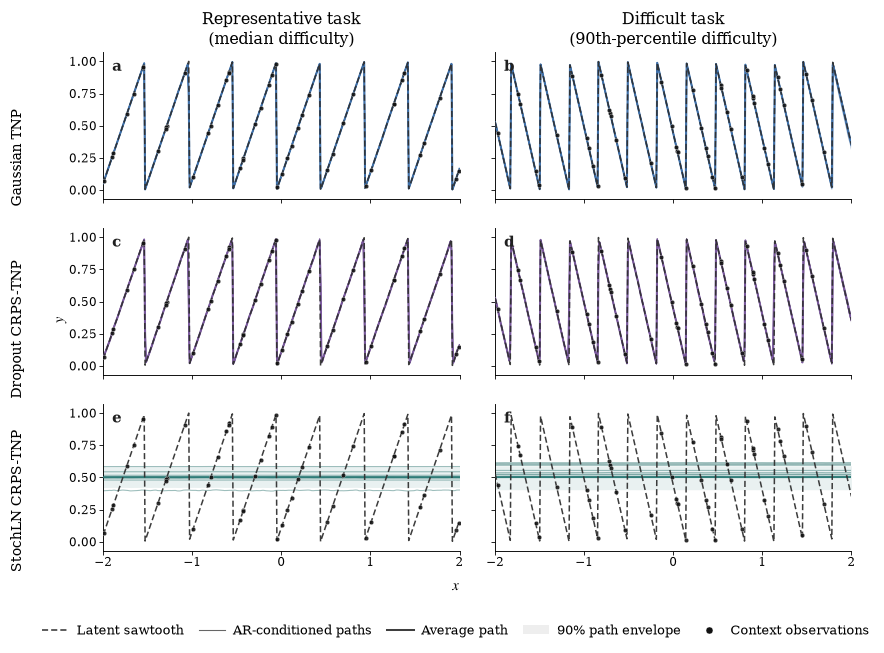

In [15]:
# Preview F2

saw_ar_fig, saw_ar_axes, saw_ar_y_limits = (
    make_sawtooth_ar_figure(
        saw_ar_cache
    )
)

plt.show()


Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports/sawtooth_ar_examples_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports/sawtooth_ar_examples_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/sawtooth/notebook_exports/sawtooth_ar_examples_v01_style.json


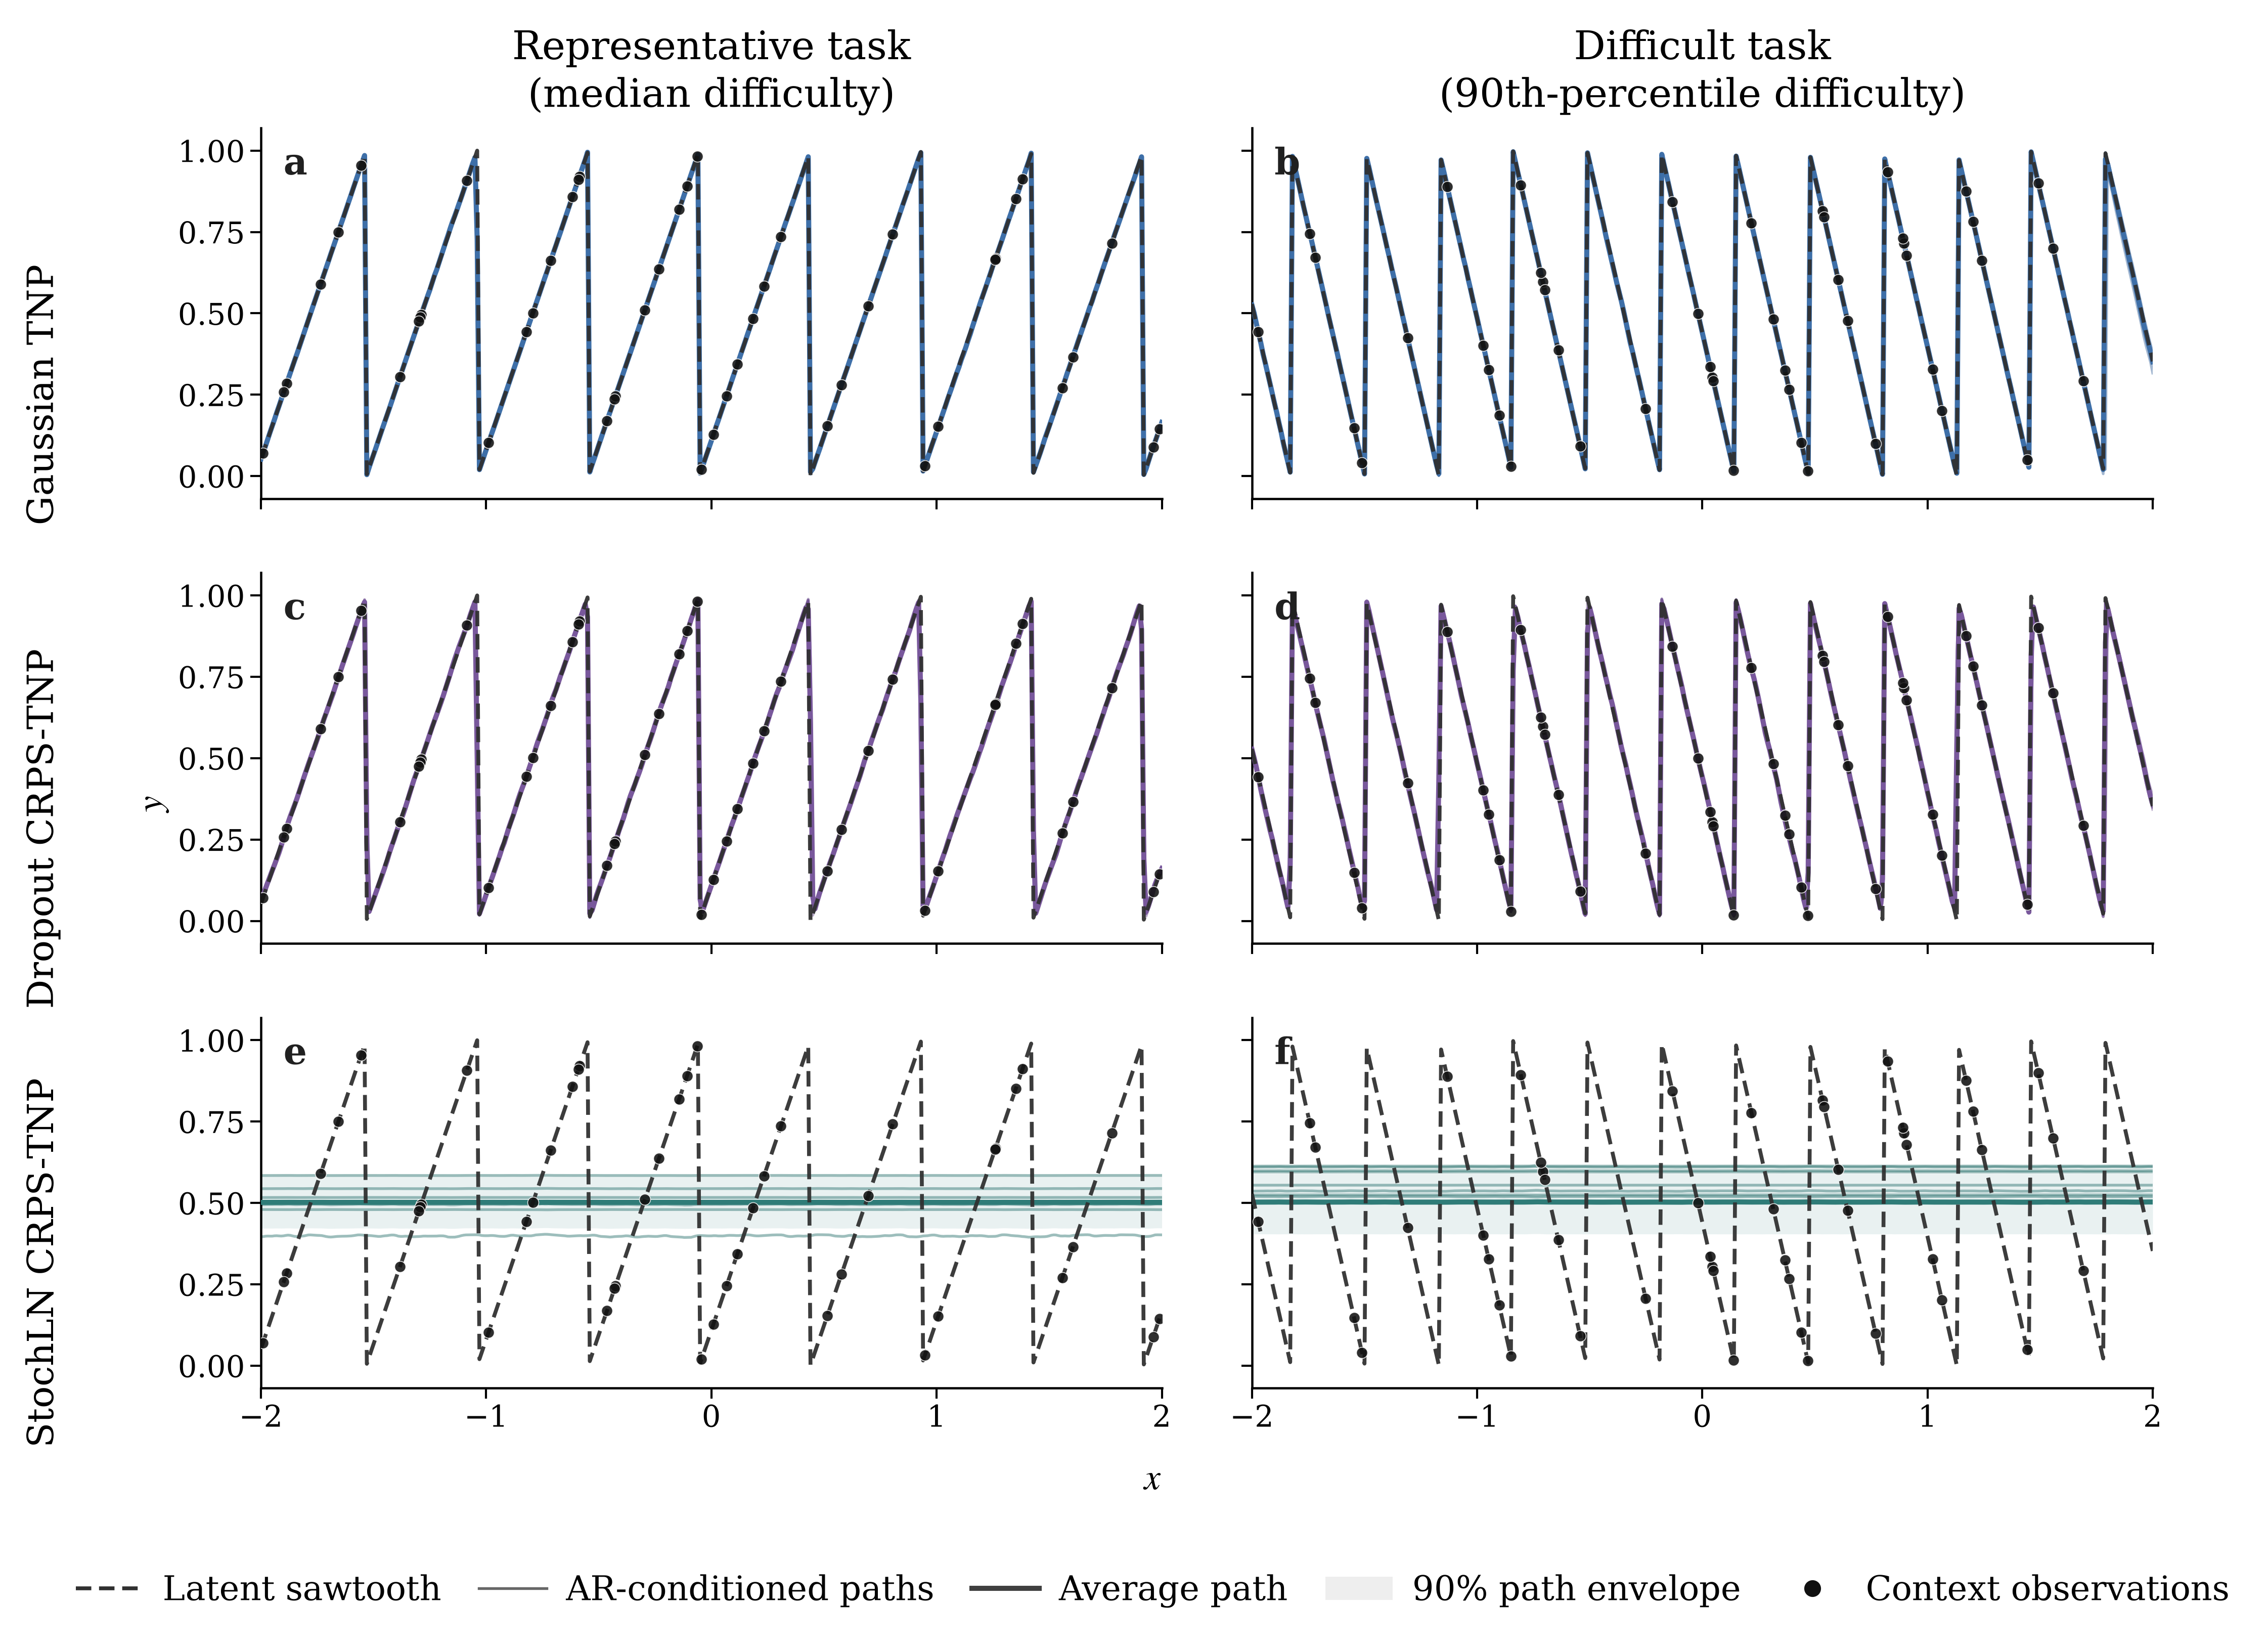

In [32]:
# Export F2

saw_export_figure(
    fig=saw_ar_fig,
    export_name=SAW_AR_EXPORT_NAME,
    title="Sawtooth autoregressive examples",
    style_snapshot={
        "cache_path": str(SAW_AR_CACHE_PATH),
        "cache_metadata": saw_ar_cache["metadata"],
        "task_selection": saw_ar_cache["task_selection"],
        "figsize": list(SAW_AR_FIGSIZE),
        "dpi": SAW_DPI,
        "visible_paths": SAW_AR_VISIBLE_PATHS,
        "path_start_index": SAW_AR_PATH_START_INDEX,
        "interval_level": SAW_AR_INTERVAL_LEVEL,
        "manual_x_lim": list(SAW_AR_MANUAL_X_LIM),
        "shared_y_limits": list(saw_ar_y_limits),
        "model_order": SAW_MODEL_ORDER,
        "task_order": SAW_AR_TASK_ORDER,
        "model_colours": SAW_MODEL_COLOURS,
    },
)

plt.close(saw_ar_fig)


# Dissertation Figure Design: Tabular Foundation-Prior Evaluation

<!-- TABULAR_CONTEXT_FULL_GRID_V2 -->

This section loads frozen tabular evaluation caches and performs no model inference.

**F1 — Context-size performance by training regime**

- Panels (a)--(d) show models trained at fixed $N_c=32$, fixed $N_c=64$, fixed $N_c=128$, and over $N_c\in\{16,32,64,128\}$, respectively.
- Every panel compares the Gaussian TNP, Dropout CRPS-TNP, and Stochastic-LayerNorm CRPS-TNP on the same paired tasks.
- The vertical quantity is CRPS improvement over the context-resample baseline, so larger positive values are better.
- Filled markers denote evaluation context sizes included in the training support; open markers denote context-size OOD evaluations for fixed-context models.
- Every rung uses the same raw target rows and nested context prefixes on the intersection of tasks accepted at all four context sizes.

**F1b — CRPS-trained variants versus Gaussian**

- The two heatmaps show the paired CRPS gain of Dropout and Stochastic LayerNorm over the Gaussian TNP for every training-regime/evaluation-context combination.
- Positive values mean the CRPS-trained variant has lower CRPS than the Gaussian model trained under the same regime.
- An asterisk marks cells whose paired 95% task-bootstrap interval excludes zero.

**F2 — Predictive shape and rank calibration**

- Panel (a): score contributions from predictive moments and from empirical shape above the sampled-Gaussian null.
- Filled markers use the primary $M=512$ estimate; open markers show the paired $M=64$ finite-sample check.
- Panels (b)--(d): 21-bin verification-rank histograms for the principal models trained and evaluated at fixed $N_c=128$.

The caches are produced by `experiments/cache_tabular_figures.py`. The notebook only validates, displays and exports the final figures.


In [4]:
# Tabular cache paths and shared visual settings

TAB_CACHE_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "tabular"
    / "caches"
)

TAB_OUTPUT_DIR = (
    REPO_ROOT
    / "results"
    / "dissertation_figures"
    / "tabular"
    / "notebook_exports"
)

TAB_CONTEXT_CACHE_PATH = (
    TAB_CACHE_DIR
    / "tabular_context_full_grid_cache_v2.pt"
)

TAB_SHAPE_CACHE_PATH = (
    TAB_CACHE_DIR
    / "tabular_shape_calibration_cache_v1.pt"
)

TAB_CONTEXT_EXPORT_NAME = (
    "tabular_context_training_regimes_v02"
)

TAB_CONTEXT_HEATMAP_EXPORT_NAME = (
    "tabular_crps_gain_heatmaps_v01"
)

TAB_SHAPE_EXPORT_NAME = (
    "tabular_shape_calibration_v01"
)

TAB_DPI = 500

TAB_ARCHITECTURE_ORDER = [
    "Gaussian TNP",
    "Dropout CRPS-TNP",
    "StochLN CRPS-TNP",
]

TAB_ARCHITECTURE_COLOURS = {
    "Gaussian TNP": MODEL_COLOURS["Gaussian TNP"],
    "Dropout CRPS-TNP": MODEL_COLOURS["Dropout CRPS-TNP"],
    "StochLN CRPS-TNP": MODEL_COLOURS["StochLN CRPS-TNP"],
}

TAB_TRAINING_REGIME_ORDER = [
    "fixed32",
    "fixed64",
    "fixed128",
    "variable",
]

TAB_TRAINING_REGIME_TITLES = {
    "fixed32": r"Fixed $N_c=32$ training",
    "fixed64": r"Fixed $N_c=64$ training",
    "fixed128": r"Fixed $N_c=128$ training",
    "variable": "Variable-context training",
}

TAB_TRAINING_REGIME_SHORT = {
    "fixed32": r"Fixed $32$",
    "fixed64": r"Fixed $64$",
    "fixed128": r"Fixed $128$",
    "variable": "Variable",
}

TAB_VARIANT_ORDER = [
    "Dropout CRPS-TNP",
    "StochLN CRPS-TNP",
]

TAB_SHAPE_MODEL_ORDER = [
    "gaussian",
    "dropout",
    "stochln",
]

TAB_SHAPE_DISPLAY_NAMES = {
    "gaussian": "Gaussian TNP",
    "dropout": "Dropout CRPS-TNP",
    "stochln": "StochLN CRPS-TNP",
}

TAB_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Tabular cache directory:", TAB_CACHE_DIR)
print("Tabular export directory:", TAB_OUTPUT_DIR)


Tabular cache directory: /scratch2/ij292/tnp-crps/results/dissertation_figures/tabular/caches
Tabular export directory: /scratch2/ij292/tnp-crps/results/dissertation_figures/tabular/notebook_exports


In [5]:
# Load and validate the frozen full-grid context cache

if not TAB_CONTEXT_CACHE_PATH.is_file():
    raise FileNotFoundError(
        "Final tabular full-grid context cache not found: "
        f"{TAB_CONTEXT_CACHE_PATH}. Run the final ladder analysis and "
        "experiments/cache_tabular_figures.py first."
    )

TAB_CONTEXT_CACHE = torch.load(
    TAB_CONTEXT_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

assert (
    TAB_CONTEXT_CACHE["schema_version"]
    == "tabular_context_full_grid_cache_v2"
)

assert TAB_CONTEXT_CACHE["metadata"]["smoke"] is False
assert (
    TAB_CONTEXT_CACHE["metadata"]["fixed_raw_targets_across_rungs"]
    is True
)
assert (
    TAB_CONTEXT_CACHE["metadata"]["complete_training_regime_grid"]
    is True
)
assert TAB_CONTEXT_CACHE["metadata"]["higher_is_better"] is True

TAB_CONTEXT_RECORDS = list(
    TAB_CONTEXT_CACHE["records"]
)

TAB_VARIANT_RECORDS = list(
    TAB_CONTEXT_CACHE["variant_vs_gaussian"]
)

TAB_CONTEXT_SIZES = [
    int(value)
    for value in (
        TAB_CONTEXT_CACHE["context_sizes"]
        .detach()
        .cpu()
        .tolist()
    )
]

assert TAB_CONTEXT_SIZES == [16, 32, 64, 128]

required_context_fields = {
    "num_context",
    "model_name",
    "display_name",
    "crps_margin_over_context_resample",
    "ci_low",
    "ci_high",
    "architecture",
    "training_regime",
    "training_display_name",
    "training_context_size",
    "in_training_support",
    "annotation_point",
}

for record in TAB_CONTEXT_RECORDS:
    missing = required_context_fields.difference(record)
    if missing:
        raise KeyError(
            "Context-cache record is missing fields: "
            f"{sorted(missing)}"
        )

context_keys = [
    (
        str(record["training_regime"]),
        str(record["architecture"]),
        int(record["num_context"]),
    )
    for record in TAB_CONTEXT_RECORDS
]

assert len(context_keys) == len(set(context_keys)) == 48
assert {
    key[0]
    for key in context_keys
} == set(TAB_TRAINING_REGIME_ORDER)
assert {
    key[1]
    for key in context_keys
} == set(TAB_ARCHITECTURE_ORDER)

required_variant_fields = {
    "training_regime",
    "training_display_name",
    "architecture",
    "num_context",
    "estimate_delta",
    "ci_low",
    "ci_high",
    "ci_contains_zero",
}

for record in TAB_VARIANT_RECORDS:
    missing = required_variant_fields.difference(record)
    if missing:
        raise KeyError(
            "Variant-comparison record is missing fields: "
            f"{sorted(missing)}"
        )

variant_keys = [
    (
        str(record["training_regime"]),
        str(record["architecture"]),
        int(record["num_context"]),
    )
    for record in TAB_VARIANT_RECORDS
]

assert len(variant_keys) == len(set(variant_keys)) == 32
assert {
    key[1]
    for key in variant_keys
} == set(TAB_VARIANT_ORDER)

print("PASS: final tabular full-grid context cache is valid.")
print("Context records:", len(TAB_CONTEXT_RECORDS))
print("Variant-vs-Gaussian records:", len(TAB_VARIANT_RECORDS))
print(
    "Intersection rejection diagnostics available:",
    bool(
        TAB_CONTEXT_CACHE["metadata"].get(
            "rejection_diagnostics"
        )
    ),
)


PASS: final tabular full-grid context cache is valid.
Context records: 48
Variant-vs-Gaussian records: 32
Intersection rejection diagnostics available: True


In [6]:
# Shared tabular plotting and export helpers


def tab_records(
    records: list[dict],
    **conditions,
) -> list[dict]:
    selected = []

    for record in records:
        if all(
            record.get(key) == value
            for key, value in conditions.items()
        ):
            selected.append(record)

    return selected


def tab_errorbar_values(
    records: list[dict],
    *,
    estimate_key: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    estimates = np.asarray(
        [
            float(record[estimate_key])
            for record in records
        ],
        dtype=float,
    )

    low = np.asarray(
        [
            float(record["ci_low"])
            for record in records
        ],
        dtype=float,
    )

    high = np.asarray(
        [
            float(record["ci_high"])
            for record in records
        ],
        dtype=float,
    )

    errors = np.vstack(
        [
            estimates - low,
            high - estimates,
        ]
    )

    return estimates, errors, np.column_stack([low, high])


def tab_export_figure(
    *,
    fig: plt.Figure,
    export_name: str,
    title: str,
    style_snapshot: dict,
) -> tuple[Path, Path, Path]:
    TAB_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    pdf_path = TAB_OUTPUT_DIR / f"{export_name}.pdf"
    png_path = TAB_OUTPUT_DIR / f"{export_name}.png"
    style_path = TAB_OUTPUT_DIR / f"{export_name}_style.json"

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
        metadata={
            "Title": title,
            "Creator": (
                "tnp-crps dissertation figure-design notebook"
            ),
        },
    )

    fig.savefig(
        png_path,
        dpi=TAB_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    style_path.write_text(
        json.dumps(
            {
                "export_name": export_name,
                "title": title,
                **style_snapshot,
            },
            indent=2,
            default=str,
        )
    )

    print("Wrote:", pdf_path)
    print("Wrote:", png_path)
    print("Wrote:", style_path)

    display(
        Image(
            filename=str(png_path),
            width=1100,
        )
    )

    return pdf_path, png_path, style_path


In [7]:
# F1: context-size performance by training regime

TAB_F1_FIGSIZE = (8.8, 6.55)

TAB_F1_CONTEXT_POSITIONS = {
    16: 0.0,
    32: 1.0,
    64: 2.0,
    128: 3.0,
}

TAB_F1_ARCHITECTURE_OFFSETS = {
    "Gaussian TNP": -0.045,
    "Dropout CRPS-TNP": 0.000,
    "StochLN CRPS-TNP": 0.045,
}

TAB_F1_LINEWIDTH = 1.45
TAB_F1_MARKER_SIZE = 4.8
TAB_F1_ERROR_LINEWIDTH = 0.82
TAB_F1_CAPSIZE = 2.2
TAB_F1_ZERO_LINEWIDTH = 0.82
TAB_F1_GRID_LINEWIDTH = 0.45
TAB_F1_GRID_ALPHA = 0.34

TAB_F1_TITLE_SIZE = 11.0
TAB_F1_PANEL_LABEL_SIZE = 10.3
TAB_F1_AXIS_LABEL_SIZE = 10.2
TAB_F1_LEGEND_SIZE = 9.2
TAB_F1_ANNOTATION_SIZE = 8.2

TAB_F1_SHOW_VALUE_ANNOTATIONS = True
TAB_F1_VALUE_FORMAT = "+.3f"
TAB_F1_MANUAL_Y_LIM = None
TAB_F1_Y_PADDING_FRACTION = 0.11

TAB_F1_ANNOTATION_OFFSETS = {
    "Gaussian TNP": (-18, -15),
    "Dropout CRPS-TNP": (3, 7),
    "StochLN CRPS-TNP": (17, -3),
}

# F1b: paired CRPS gain over Gaussian heatmaps

TAB_F1B_FIGSIZE = (8.8, 3.65)
TAB_F1B_CMAP = "RdBu"
TAB_F1B_VALUE_FORMAT = "+.3f"
TAB_F1B_TITLE_SIZE = 11.0
TAB_F1B_PANEL_LABEL_SIZE = 10.3
TAB_F1B_AXIS_LABEL_SIZE = 10.0
TAB_F1B_CELL_TEXT_SIZE = 8.4
TAB_F1B_COLOURBAR_LABEL_SIZE = 9.5
TAB_F1B_SIGNIFICANCE_SYMBOL = "*"


In [8]:
# F1/F1b plotting functions: full fixed-target nested context ladder


def make_tabular_context_training_regime_figure(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray, tuple[float, float]]:
    records = list(cache["records"])

    all_low = [0.0]
    all_high = [0.0]

    for record in records:
        all_low.append(float(record["ci_low"]))
        all_high.append(float(record["ci_high"]))

    if TAB_F1_MANUAL_Y_LIM is None:
        raw_min = min(all_low)
        raw_max = max(all_high)
        span = max(raw_max - raw_min, 1.0e-3)
        padding = TAB_F1_Y_PADDING_FRACTION * span
        y_limits = (
            raw_min - padding,
            raw_max + padding,
        )
    else:
        y_limits = tuple(TAB_F1_MANUAL_Y_LIM)

    with mpl.rc_context(DISSERTATION_RC):
        fig, axes = plt.subplots(
            nrows=2,
            ncols=2,
            figsize=TAB_F1_FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        axes = np.asarray(axes)

        for panel_index, regime_name in enumerate(
            TAB_TRAINING_REGIME_ORDER
        ):
            row_index, column_index = divmod(panel_index, 2)
            ax = axes[row_index, column_index]

            ax.set_axisbelow(True)
            ax.grid(
                axis="y",
                color="#B8B8B8",
                linewidth=TAB_F1_GRID_LINEWIDTH,
                alpha=TAB_F1_GRID_ALPHA,
            )

            ax.axhline(
                0.0,
                color="#6F6F6F",
                linewidth=TAB_F1_ZERO_LINEWIDTH,
                linestyle=(0, (4, 2)),
                zorder=1,
            )

            for architecture in TAB_ARCHITECTURE_ORDER:
                selected = tab_records(
                    records,
                    training_regime=regime_name,
                    architecture=architecture,
                )

                selected = sorted(
                    selected,
                    key=lambda row: int(row["num_context"]),
                )

                expected_contexts = [
                    int(row["num_context"])
                    for row in selected
                ]

                if expected_contexts != TAB_CONTEXT_SIZES:
                    raise ValueError(
                        f"Incomplete line for regime={regime_name!r}, "
                        f"architecture={architecture!r}: "
                        f"{expected_contexts}."
                    )

                offset = TAB_F1_ARCHITECTURE_OFFSETS[
                    architecture
                ]

                x = np.asarray(
                    [
                        TAB_F1_CONTEXT_POSITIONS[
                            int(row["num_context"])
                        ]
                        + offset
                        for row in selected
                    ],
                    dtype=float,
                )

                y, yerr, _ = tab_errorbar_values(
                    selected,
                    estimate_key=(
                        "crps_margin_over_context_resample"
                    ),
                )

                colour = TAB_ARCHITECTURE_COLOURS[
                    architecture
                ]

                ax.errorbar(
                    x,
                    y,
                    yerr=yerr,
                    color=colour,
                    linewidth=TAB_F1_LINEWIDTH,
                    marker=None,
                    elinewidth=TAB_F1_ERROR_LINEWIDTH,
                    capsize=TAB_F1_CAPSIZE,
                    capthick=TAB_F1_ERROR_LINEWIDTH,
                    zorder=3,
                )

                for point_x, point_y, record in zip(
                    x,
                    y,
                    selected,
                ):
                    in_support = bool(
                        record["in_training_support"]
                    )

                    ax.plot(
                        [point_x],
                        [point_y],
                        linestyle="none",
                        marker="o",
                        markersize=TAB_F1_MARKER_SIZE,
                        markerfacecolor=(
                            colour
                            if in_support
                            else "white"
                        ),
                        markeredgecolor=colour,
                        markeredgewidth=0.85,
                        zorder=5,
                    )

                    if (
                        TAB_F1_SHOW_VALUE_ANNOTATIONS
                        and bool(record["annotation_point"])
                    ):
                        dx, dy = TAB_F1_ANNOTATION_OFFSETS[
                            architecture
                        ]
                        value = float(
                            record[
                                "crps_margin_over_context_resample"
                            ]
                        )
                        ax.annotate(
                            format(value, TAB_F1_VALUE_FORMAT),
                            xy=(point_x, point_y),
                            xytext=(dx, dy),
                            textcoords="offset points",
                            fontsize=TAB_F1_ANNOTATION_SIZE,
                            color=colour,
                            ha="center",
                            va="center",
                            zorder=8,
                        )

            ax.set_xlim(-0.28, 3.28)
            ax.set_ylim(*y_limits)
            ax.set_xticks(
                [
                    TAB_F1_CONTEXT_POSITIONS[value]
                    for value in TAB_CONTEXT_SIZES
                ]
            )
            ax.set_xticklabels(
                [str(value) for value in TAB_CONTEXT_SIZES]
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.tick_params(
                axis="both",
                width=0.60,
                length=3.0,
                pad=1.8,
            )

            ax.set_title(
                TAB_TRAINING_REGIME_TITLES[regime_name],
                fontsize=TAB_F1_TITLE_SIZE,
                pad=6,
            )

            ax.text(
                0.022,
                0.965,
                string.ascii_lowercase[panel_index],
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=TAB_F1_PANEL_LABEL_SIZE,
                fontweight="bold",
                color="#202020",
                zorder=10,
            )

        fig.supylabel(
            r"CRPS improvement over context resample",
            x=0.020,
            fontsize=TAB_F1_AXIS_LABEL_SIZE,
        )

        fig.supxlabel(
            r"Evaluation context size $N_c$",
            x=0.535,
            y=0.105,
            fontsize=TAB_F1_AXIS_LABEL_SIZE,
        )

        architecture_handles = [
            Line2D(
                [0],
                [0],
                color=TAB_ARCHITECTURE_COLOURS[name],
                linewidth=TAB_F1_LINEWIDTH,
                marker="o",
                markersize=5.0,
                markerfacecolor=TAB_ARCHITECTURE_COLOURS[name],
                markeredgecolor=TAB_ARCHITECTURE_COLOURS[name],
                label=name,
            )
            for name in TAB_ARCHITECTURE_ORDER
        ]

        ood_handle = Line2D(
            [0],
            [0],
            color="#606060",
            linestyle="none",
            marker="o",
            markersize=5.0,
            markerfacecolor="white",
            markeredgecolor="#606060",
            markeredgewidth=0.85,
            label="Context size outside fixed-training support",
        )

        fig.legend(
            handles=[
                *architecture_handles,
                ood_handle,
            ],
            loc="lower center",
            bbox_to_anchor=(0.535, 0.012),
            ncol=2,
            frameon=False,
            fontsize=TAB_F1_LEGEND_SIZE,
            handlelength=1.9,
            handletextpad=0.55,
            columnspacing=1.25,
            labelspacing=0.65,
        )

        fig.subplots_adjust(
            left=0.105,
            right=0.990,
            top=0.925,
            bottom=0.205,
            wspace=0.145,
            hspace=0.285,
        )

        return fig, axes, y_limits


def make_tabular_crps_gain_heatmaps(
    cache: dict,
) -> tuple[plt.Figure, np.ndarray, tuple[float, float]]:
    records = list(cache["variant_vs_gaussian"])

    values = np.asarray(
        [
            float(record["estimate_delta"])
            for record in records
        ],
        dtype=float,
    )

    max_abs = max(
        float(np.max(np.abs(values))),
        1.0e-4,
    )

    colour_limits = (-max_abs, max_abs)
    norm = mpl.colors.TwoSlopeNorm(
        vmin=colour_limits[0],
        vcenter=0.0,
        vmax=colour_limits[1],
    )
    cmap = mpl.colormaps[TAB_F1B_CMAP]

    with mpl.rc_context(DISSERTATION_RC):
        fig, axes = plt.subplots(
            nrows=1,
            ncols=2,
            figsize=TAB_F1B_FIGSIZE,
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )

        axes = np.atleast_1d(axes)
        image = None

        for panel_index, architecture in enumerate(
            TAB_VARIANT_ORDER
        ):
            ax = axes[panel_index]

            matrix = np.full(
                (
                    len(TAB_TRAINING_REGIME_ORDER),
                    len(TAB_CONTEXT_SIZES),
                ),
                np.nan,
                dtype=float,
            )
            significant = np.zeros_like(
                matrix,
                dtype=bool,
            )

            for row_index, regime_name in enumerate(
                TAB_TRAINING_REGIME_ORDER
            ):
                for column_index, num_context in enumerate(
                    TAB_CONTEXT_SIZES
                ):
                    selected = tab_records(
                        records,
                        training_regime=regime_name,
                        architecture=architecture,
                        num_context=num_context,
                    )

                    if len(selected) != 1:
                        raise ValueError(
                            "Expected one variant-vs-Gaussian record for "
                            f"regime={regime_name}, "
                            f"architecture={architecture}, "
                            f"Nc={num_context}; found {len(selected)}."
                        )

                    record = selected[0]
                    matrix[row_index, column_index] = float(
                        record["estimate_delta"]
                    )
                    significant[row_index, column_index] = not bool(
                        record["ci_contains_zero"]
                    )

            image = ax.imshow(
                matrix,
                cmap=cmap,
                norm=norm,
                aspect="auto",
                interpolation="nearest",
            )

            for row_index in range(matrix.shape[0]):
                for column_index in range(matrix.shape[1]):
                    value = matrix[row_index, column_index]
                    rgba = cmap(norm(value))
                    luminance = (
                        0.2126 * rgba[0]
                        + 0.7152 * rgba[1]
                        + 0.0722 * rgba[2]
                    )
                    text_colour = (
                        "white"
                        if luminance < 0.52
                        else "#202020"
                    )
                    suffix = (
                        TAB_F1B_SIGNIFICANCE_SYMBOL
                        if significant[row_index, column_index]
                        else ""
                    )
                    ax.text(
                        column_index,
                        row_index,
                        (
                            format(value, TAB_F1B_VALUE_FORMAT)
                            + suffix
                        ),
                        ha="center",
                        va="center",
                        fontsize=TAB_F1B_CELL_TEXT_SIZE,
                        color=text_colour,
                        fontweight=(
                            "bold"
                            if significant[row_index, column_index]
                            else "normal"
                        ),
                    )

            ax.set_xticks(
                np.arange(len(TAB_CONTEXT_SIZES))
            )
            ax.set_xticklabels(
                [str(value) for value in TAB_CONTEXT_SIZES]
            )
            ax.set_yticks(
                np.arange(len(TAB_TRAINING_REGIME_ORDER))
            )
            ax.set_yticklabels(
                [
                    TAB_TRAINING_REGIME_SHORT[value]
                    for value in TAB_TRAINING_REGIME_ORDER
                ]
            )

            ax.set_title(
                architecture,
                fontsize=TAB_F1B_TITLE_SIZE,
                pad=6,
            )

            ax.text(
                0.018,
                0.972,
                string.ascii_lowercase[panel_index],
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=TAB_F1B_PANEL_LABEL_SIZE,
                fontweight="bold",
                color="#202020",
                zorder=10,
            )

            ax.set_xticks(
                np.arange(-0.5, len(TAB_CONTEXT_SIZES), 1.0),
                minor=True,
            )
            ax.set_yticks(
                np.arange(-0.5, len(TAB_TRAINING_REGIME_ORDER), 1.0),
                minor=True,
            )
            ax.grid(
                which="minor",
                color="white",
                linewidth=1.0,
            )
            ax.tick_params(
                which="minor",
                bottom=False,
                left=False,
            )
            ax.tick_params(
                axis="both",
                width=0.60,
                length=3.0,
                pad=2.0,
            )

        fig.supxlabel(
            r"Evaluation context size $N_c$",
            x=0.505,
            y=0.105,
            fontsize=TAB_F1B_AXIS_LABEL_SIZE,
        )
        fig.supylabel(
            "Training regime",
            x=0.025,
            fontsize=TAB_F1B_AXIS_LABEL_SIZE,
        )

        if image is None:
            raise RuntimeError("No heatmap image was created.")

        colourbar_axis = fig.add_axes(
            [0.905, 0.225, 0.018, 0.60]
        )
        colourbar = fig.colorbar(
            image,
            cax=colourbar_axis,
        )
        colourbar.set_label(
            "CRPS gain over Gaussian",
            fontsize=TAB_F1B_COLOURBAR_LABEL_SIZE,
        )
        colourbar.ax.tick_params(
            labelsize=8.5,
            width=0.55,
            length=2.8,
        )

        fig.text(
            0.505,
            0.035,
            (
                f"{TAB_F1B_SIGNIFICANCE_SYMBOL} paired 95% "
                "task-bootstrap interval excludes zero"
            ),
            ha="center",
            va="center",
            fontsize=8.6,
            color="#404040",
        )

        fig.subplots_adjust(
            left=0.145,
            right=0.875,
            top=0.865,
            bottom=0.235,
            wspace=0.16,
        )

        return fig, axes, colour_limits


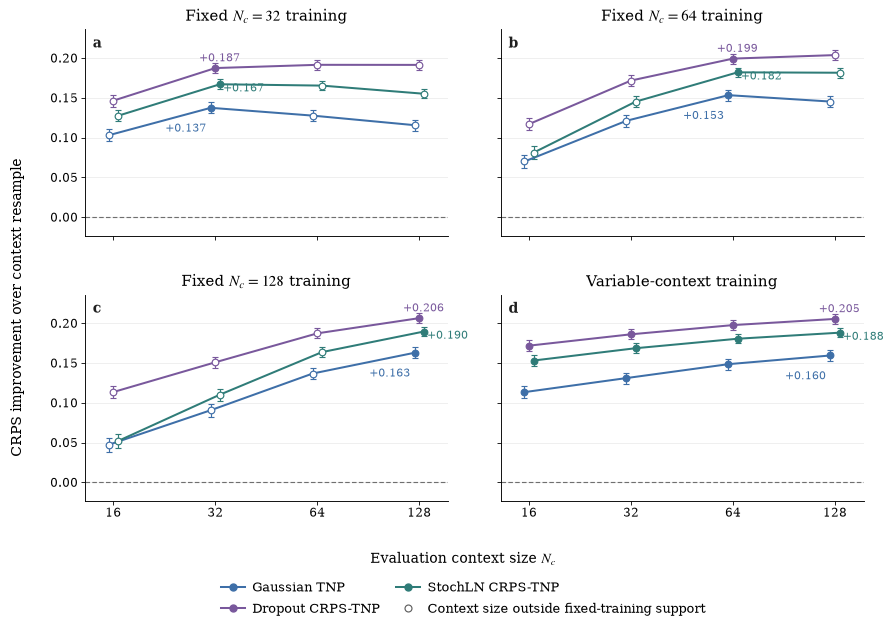

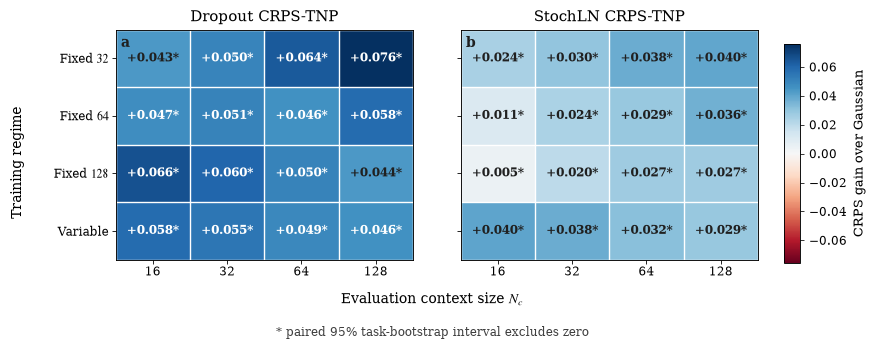

In [9]:
# Preview F1 and F1b

(
    TAB_F1_FIG,
    TAB_F1_AXES,
    TAB_F1_Y_LIMITS,
) = make_tabular_context_training_regime_figure(
    TAB_CONTEXT_CACHE
)

plt.show()

(
    TAB_F1B_FIG,
    TAB_F1B_AXES,
    TAB_F1B_COLOUR_LIMITS,
) = make_tabular_crps_gain_heatmaps(
    TAB_CONTEXT_CACHE
)

plt.show()


In [ ]:
# Export F1 and F1b

TAB_F1_PDF, TAB_F1_PNG, TAB_F1_STYLE = (
    tab_export_figure(
        fig=TAB_F1_FIG,
        export_name=TAB_CONTEXT_EXPORT_NAME,
        title=(
            "Tabular context-size performance by training regime"
        ),
        style_snapshot={
            "cache_path": str(TAB_CONTEXT_CACHE_PATH),
            "cache_schema": TAB_CONTEXT_CACHE["schema_version"],
            "figure_size": TAB_F1_FIGSIZE,
            "context_sizes": TAB_CONTEXT_SIZES,
            "training_regimes": TAB_TRAINING_REGIME_ORDER,
            "architectures": TAB_ARCHITECTURE_ORDER,
            "metric": (
                "context-resample CRPS minus model CRPS"
            ),
            "higher_is_better": True,
            "fixed_raw_targets_across_rungs": True,
            "y_limits": TAB_F1_Y_LIMITS,
            "annotations": (
                "matched training rung for fixed models; "
                "Nc=128 for variable-context models"
            ),
        },
    )
)

(
    TAB_F1B_PDF,
    TAB_F1B_PNG,
    TAB_F1B_STYLE,
) = tab_export_figure(
    fig=TAB_F1B_FIG,
    export_name=TAB_CONTEXT_HEATMAP_EXPORT_NAME,
    title=(
        "Paired CRPS gain of sample-based models over Gaussian TNP"
    ),
    style_snapshot={
        "cache_path": str(TAB_CONTEXT_CACHE_PATH),
        "cache_schema": TAB_CONTEXT_CACHE["schema_version"],
        "figure_size": TAB_F1B_FIGSIZE,
        "context_sizes": TAB_CONTEXT_SIZES,
        "training_regimes": TAB_TRAINING_REGIME_ORDER,
        "variants": TAB_VARIANT_ORDER,
        "metric": (
            "Gaussian CRPS minus CRPS-trained variant CRPS"
        ),
        "higher_is_better": True,
        "colour_limits": TAB_F1B_COLOUR_LIMITS,
        "significance": (
            "asterisk means paired 95% task-bootstrap interval "
            "excludes zero"
        ),
    },
)


In [11]:
# F2: load the final shape-calibration cache and define visual controls

if not TAB_SHAPE_CACHE_PATH.is_file():
    raise FileNotFoundError(
        "Final tabular shape cache not found: "
        f"{TAB_SHAPE_CACHE_PATH}. Run the final shape analysis and "
        "experiments/cache_tabular_figures.py first."
    )

TAB_SHAPE_CACHE = torch.load(
    TAB_SHAPE_CACHE_PATH,
    map_location="cpu",
    weights_only=False,
)

assert (
    TAB_SHAPE_CACHE["schema_version"]
    == "tabular_shape_calibration_cache_v1"
)
assert TAB_SHAPE_CACHE["metadata"]["smoke"] is False
assert TAB_SHAPE_CACHE["metadata"]["primary_sample_count"] == 512
assert TAB_SHAPE_CACHE["metadata"]["finite_sample_check"] == 64

TAB_SHAPE_CONTRIBUTIONS = list(
    TAB_SHAPE_CACHE["contributions"]
)
TAB_SHAPE_ADJUSTED = list(
    TAB_SHAPE_CACHE["null_adjusted"]
)
TAB_RANK_HISTOGRAM = list(
    TAB_SHAPE_CACHE["rank_histogram"]
)
TAB_RANK_CALIBRATION = list(
    TAB_SHAPE_CACHE["rank_calibration"]
)

assert {
    str(record["model_name"])
    for record in TAB_SHAPE_CONTRIBUTIONS
} == set(TAB_SHAPE_MODEL_ORDER)

assert {
    int(record["sample_count"])
    for record in TAB_SHAPE_CONTRIBUTIONS
} == {64, 512}

assert {
    int(record["bin_index"])
    for record in TAB_RANK_HISTOGRAM
} == set(range(21))

assert len(TAB_RANK_HISTOGRAM) == 3 * 21
assert len(TAB_RANK_CALIBRATION) == 3

TAB_F2_FIGSIZE = (10.0, 5.7)
TAB_F2_GRID_WIDTH_RATIOS = (1.42, 1.00)

TAB_F2_PRIMARY_M = 512
TAB_F2_CHECK_M = 64

TAB_F2_FOREST_LINEWIDTH = 0.95
TAB_F2_FOREST_MARKER_SIZE = 5.8
TAB_F2_FOREST_CAPSIZE = 2.5
TAB_F2_FOREST_VERTICAL_OFFSET = 0.105
TAB_F2_ZERO_LINEWIDTH = 0.80

TAB_F2_HIST_ALPHA = 0.68
TAB_F2_HIST_EDGE_WIDTH = 0.0
TAB_F2_UNIFORM_LINEWIDTH = 0.90

TAB_F2_TITLE_SIZE = 10.8
TAB_F2_PANEL_LABEL_SIZE = 10.5
TAB_F2_AXIS_LABEL_SIZE = 10.3
TAB_F2_LEGEND_SIZE = 9.1
TAB_F2_ANNOTATION_SIZE = 8.3

TAB_F2_MANUAL_X_LIM = None
TAB_F2_X_PADDING_FRACTION = 0.12
TAB_F2_MANUAL_HIST_Y_LIM = None


In [12]:
# F2 plotting function: shape contribution and verification-rank calibration


def make_tabular_shape_figure(
    cache: dict,
) -> tuple[
    plt.Figure,
    dict[str, object],
    tuple[float, float],
    tuple[float, float],
]:
    contributions = list(cache["contributions"])
    adjusted = list(cache["null_adjusted"])
    histogram = list(cache["rank_histogram"])
    calibration = list(cache["rank_calibration"])

    calibration_by_model = {
        str(record["model_name"]): record
        for record in calibration
    }

    forest_rows = []

    y_positions = {
        ("gaussian", "moment"): 5.35,
        ("gaussian", "shape_adjusted"): 4.65,
        ("dropout", "moment"): 3.35,
        ("dropout", "shape_adjusted"): 2.65,
        ("stochln", "moment"): 1.35,
        ("stochln", "shape_adjusted"): 0.65,
    }

    for model_name in TAB_SHAPE_MODEL_ORDER:
        for sample_count in (
            TAB_F2_CHECK_M,
            TAB_F2_PRIMARY_M,
        ):
            moment_rows = [
                record
                for record in contributions
                if (
                    str(record["model_name"]) == model_name
                    and int(record["sample_count"]) == sample_count
                    and str(record["component"]) == "moment"
                )
            ]

            shape_rows = [
                record
                for record in adjusted
                if (
                    str(record["model_name"]) == model_name
                    and int(record["sample_count"]) == sample_count
                )
            ]

            if len(moment_rows) != 1 or len(shape_rows) != 1:
                raise ValueError(
                    "Incomplete shape decomposition for "
                    f"model={model_name}, M={sample_count}."
                )

            forest_rows.append(
                {
                    "model_name": model_name,
                    "component": "moment",
                    "sample_count": sample_count,
                    "estimate": float(moment_rows[0]["estimate"]),
                    "ci_low": float(moment_rows[0]["ci_low"]),
                    "ci_high": float(moment_rows[0]["ci_high"]),
                    "y": y_positions[(model_name, "moment")],
                }
            )

            forest_rows.append(
                {
                    "model_name": model_name,
                    "component": "shape_adjusted",
                    "sample_count": sample_count,
                    "estimate": float(shape_rows[0]["estimate_delta"]),
                    "ci_low": float(shape_rows[0]["ci_low"]),
                    "ci_high": float(shape_rows[0]["ci_high"]),
                    "y": y_positions[(model_name, "shape_adjusted")],
                }
            )

    forest_min = min(
        [0.0]
        + [row["ci_low"] for row in forest_rows]
    )
    forest_max = max(
        [0.0]
        + [row["ci_high"] for row in forest_rows]
    )

    if TAB_F2_MANUAL_X_LIM is None:
        forest_span = max(
            forest_max - forest_min,
            1.0e-3,
        )
        forest_padding = (
            TAB_F2_X_PADDING_FRACTION
            * forest_span
        )
        forest_x_limits = (
            forest_min - forest_padding,
            forest_max + forest_padding,
        )
    else:
        forest_x_limits = tuple(TAB_F2_MANUAL_X_LIM)

    histogram_max = max(
        float(record["probability"])
        for record in histogram
    )
    uniform_probability = max(
        float(record["uniform_probability"])
        for record in histogram
    )

    if TAB_F2_MANUAL_HIST_Y_LIM is None:
        hist_y_limits = (
            0.0,
            1.16 * max(
                histogram_max,
                uniform_probability,
            ),
        )
    else:
        hist_y_limits = tuple(TAB_F2_MANUAL_HIST_Y_LIM)

    with mpl.rc_context(DISSERTATION_RC):
        fig = plt.figure(
            figsize=TAB_F2_FIGSIZE,
            constrained_layout=False,
        )

        grid = fig.add_gridspec(
            nrows=3,
            ncols=2,
            width_ratios=TAB_F2_GRID_WIDTH_RATIOS,
            left=0.145,
            right=0.995,
            top=0.925,
            bottom=0.205,
            wspace=0.33,
            hspace=0.22,
        )

        forest_ax = fig.add_subplot(
            grid[:, 0]
        )

        hist_axes = np.asarray(
            [
                fig.add_subplot(grid[index, 1])
                for index in range(3)
            ],
            dtype=object,
        )

        forest_ax.axvline(
            0.0,
            color="#777777",
            linewidth=TAB_F2_ZERO_LINEWIDTH,
            linestyle=(0, (4, 2)),
            zorder=1,
        )

        for row in forest_rows:
            model_name = row["model_name"]
            display_name = TAB_SHAPE_DISPLAY_NAMES[model_name]
            colour = TAB_ARCHITECTURE_COLOURS[display_name]
            primary = row["sample_count"] == TAB_F2_PRIMARY_M

            y_offset = (
                TAB_F2_FOREST_VERTICAL_OFFSET
                if primary
                else -TAB_F2_FOREST_VERTICAL_OFFSET
            )

            marker = (
                "o"
                if row["component"] == "moment"
                else "s"
            )

            forest_ax.errorbar(
                [row["estimate"]],
                [row["y"] + y_offset],
                xerr=np.asarray(
                    [
                        [row["estimate"] - row["ci_low"]],
                        [row["ci_high"] - row["estimate"]],
                    ]
                ),
                color=colour,
                linewidth=TAB_F2_FOREST_LINEWIDTH,
                marker=marker,
                markersize=TAB_F2_FOREST_MARKER_SIZE,
                markerfacecolor=(
                    colour
                    if primary
                    else "white"
                ),
                markeredgecolor=colour,
                markeredgewidth=1.0,
                elinewidth=TAB_F2_FOREST_LINEWIDTH,
                capsize=TAB_F2_FOREST_CAPSIZE,
                capthick=TAB_F2_FOREST_LINEWIDTH,
                zorder=(4 if primary else 3),
            )

        forest_ax.set_xlim(*forest_x_limits)
        forest_ax.set_ylim(0.05, 5.95)

        forest_ax.set_yticks(
            [
                5.35,
                4.65,
                3.35,
                2.65,
                1.35,
                0.65,
            ]
        )

        forest_ax.set_yticklabels(
            [
                "Gaussian TNP\nMoments",
                "Gaussian TNP\nShape above null",
                "Dropout CRPS-TNP\nMoments",
                "Dropout CRPS-TNP\nShape above null",
                "StochLN CRPS-TNP\nMoments",
                "StochLN CRPS-TNP\nShape above null",
            ]
        )

        forest_ax.set_xlabel(
            "Contribution to CRPS improvement over Gaussian TNP",
            fontsize=TAB_F2_AXIS_LABEL_SIZE,
            labelpad=5,
        )

        forest_ax.set_title(
            "Moment and shape contributions",
            fontsize=TAB_F2_TITLE_SIZE,
            pad=6,
        )

        forest_ax.grid(False)
        forest_ax.spines["top"].set_visible(False)
        forest_ax.spines["right"].set_visible(False)
        forest_ax.tick_params(
            axis="both",
            width=0.60,
            length=3.0,
            pad=2.0,
        )

        forest_ax.text(
            0.018,
            0.975,
            "a",
            transform=forest_ax.transAxes,
            ha="left",
            va="top",
            fontsize=TAB_F2_PANEL_LABEL_SIZE,
            fontweight="bold",
            color="#202020",
        )

        for panel_offset, model_name in enumerate(
            TAB_SHAPE_MODEL_ORDER,
            start=1,
        ):
            ax = hist_axes[panel_offset - 1]
            display_name = TAB_SHAPE_DISPLAY_NAMES[model_name]
            colour = TAB_ARCHITECTURE_COLOURS[display_name]

            rows = sorted(
                [
                    record
                    for record in histogram
                    if str(record["model_name"]) == model_name
                ],
                key=lambda record: int(record["bin_index"]),
            )

            if len(rows) != 21:
                raise ValueError(
                    f"Expected 21 rank bins for {model_name!r}, "
                    f"found {len(rows)}."
                )

            left = np.asarray(
                [float(row["bin_left"]) for row in rows]
            )
            right = np.asarray(
                [float(row["bin_right"]) for row in rows]
            )
            probability = np.asarray(
                [float(row["probability"]) for row in rows]
            )
            centres = 0.5 * (left + right)
            widths = right - left
            expected = float(rows[0]["uniform_probability"])

            ax.bar(
                centres,
                probability,
                width=0.90 * widths,
                align="center",
                color=colour,
                alpha=TAB_F2_HIST_ALPHA,
                edgecolor="none",
                linewidth=TAB_F2_HIST_EDGE_WIDTH,
                zorder=2,
            )

            ax.axhline(
                expected,
                color="#555555",
                linewidth=TAB_F2_UNIFORM_LINEWIDTH,
                linestyle=(0, (4, 2)),
                zorder=3,
            )

            calibration_row = calibration_by_model[
                model_name
            ]

            l1_distance = float(
                calibration_row[
                    "rank_histogram_l1_from_uniform"
                ]
            )

            ax.text(
                0.975,
                0.86,
                rf"$L_1={l1_distance:.3f}$",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=TAB_F2_ANNOTATION_SIZE,
                color="#454545",
            )

            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(*hist_y_limits)
            ax.set_xticks([0.0, 0.5, 1.0])

            ax.set_title(
                display_name,
                fontsize=TAB_F2_TITLE_SIZE,
                pad=4,
            )

            ax.grid(False)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(
                axis="both",
                width=0.60,
                length=3.0,
                pad=1.5,
            )

            if panel_offset < 3:
                ax.tick_params(labelbottom=False)

            ax.text(
                0.025,
                0.935,
                string.ascii_lowercase[panel_offset],
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=TAB_F2_PANEL_LABEL_SIZE,
                fontweight="bold",
                color="#202020",
            )

        hist_axes[1].set_ylabel(
            "Rank probability",
            fontsize=TAB_F2_AXIS_LABEL_SIZE,
            labelpad=5,
        )

        hist_axes[-1].set_xlabel(
            "Normalised verification rank",
            fontsize=TAB_F2_AXIS_LABEL_SIZE,
            labelpad=4,
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                color="#555555",
                marker="o",
                linestyle="none",
                markerfacecolor="#555555",
                markeredgecolor="#555555",
                markersize=5.8,
                label=r"Moment contribution, $M=512$",
            ),
            Line2D(
                [0],
                [0],
                color="#555555",
                marker="s",
                linestyle="none",
                markerfacecolor="#555555",
                markeredgecolor="#555555",
                markersize=5.8,
                label=r"Shape above Gaussian null, $M=512$",
            ),
            Line2D(
                [0],
                [0],
                color="#555555",
                marker="o",
                linestyle="none",
                markerfacecolor="white",
                markeredgecolor="#555555",
                markeredgewidth=1.0,
                markersize=5.8,
                label=r"Paired finite-sample check, $M=64$",
            ),
            Line2D(
                [0],
                [0],
                color="#555555",
                linewidth=TAB_F2_UNIFORM_LINEWIDTH,
                linestyle=(0, (4, 2)),
                label="Uniform-rank reference",
            ),
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.555, 0.035),
            ncol=2,
            frameon=False,
            fontsize=TAB_F2_LEGEND_SIZE,
            handlelength=2.0,
            handletextpad=0.55,
            columnspacing=1.20,
            labelspacing=0.70,
        )

        axes_dict = {
            "forest": forest_ax,
            "rank": hist_axes,
        }

        return (
            fig,
            axes_dict,
            forest_x_limits,
            hist_y_limits,
        )


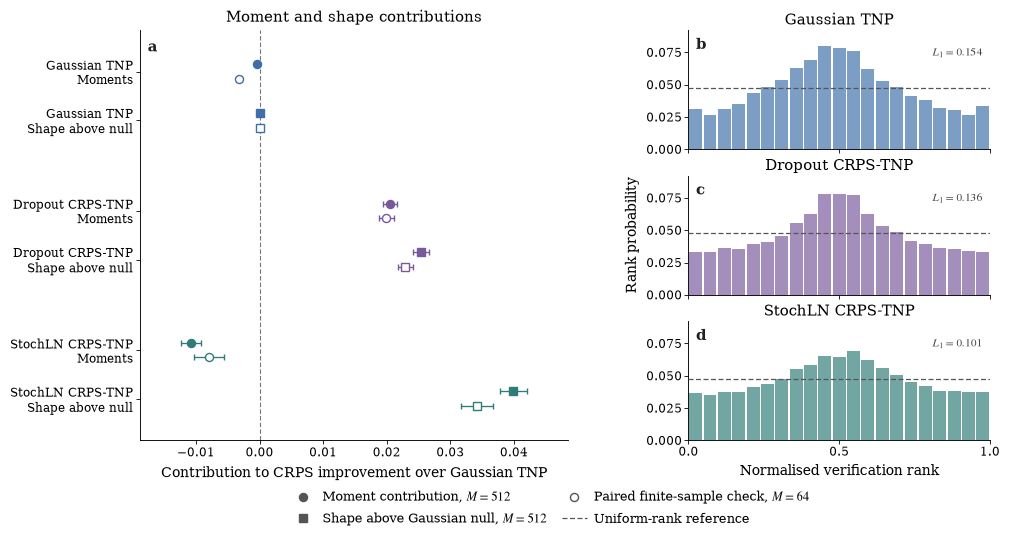

In [13]:
# Preview F2

(
    TAB_F2_FIG,
    TAB_F2_AXES,
    TAB_F2_FOREST_X_LIMITS,
    TAB_F2_HIST_Y_LIMITS,
) = make_tabular_shape_figure(
    TAB_SHAPE_CACHE
)

plt.show()


Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/tabular/notebook_exports/tabular_shape_calibration_v01.pdf
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/tabular/notebook_exports/tabular_shape_calibration_v01.png
Wrote: /scratch2/ij292/tnp-crps/results/dissertation_figures/tabular/notebook_exports/tabular_shape_calibration_v01_style.json


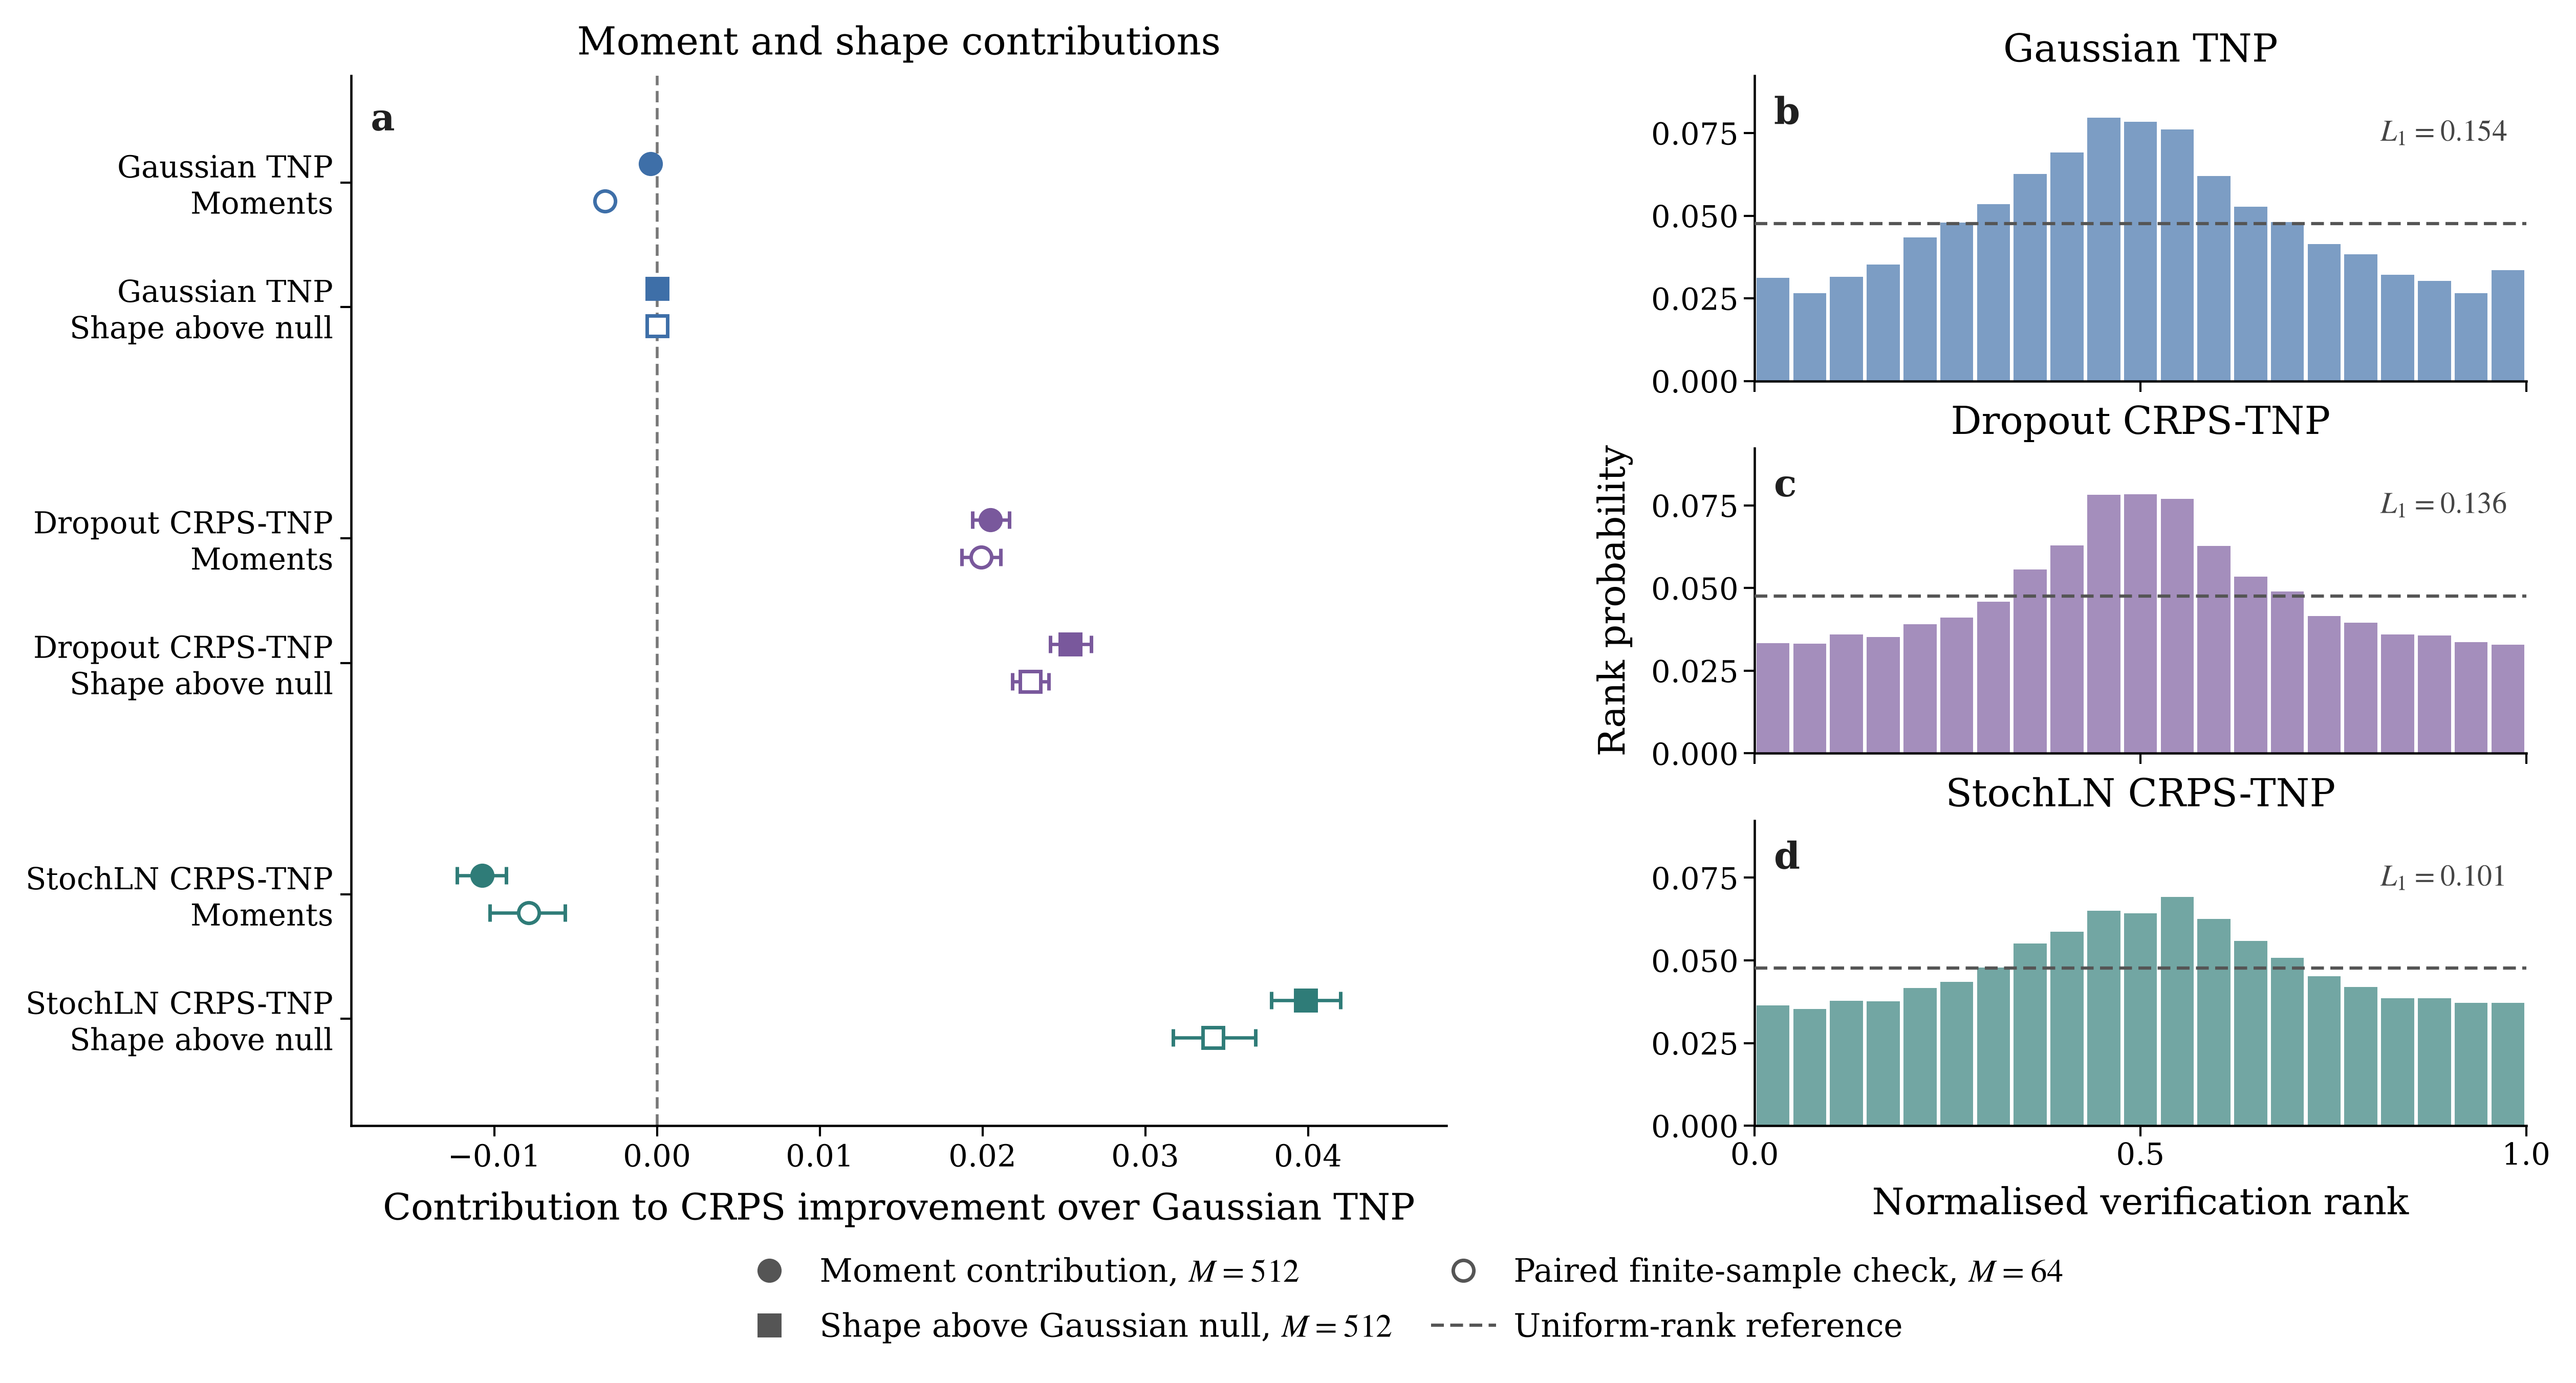

In [14]:
# Export F2

TAB_F2_PDF, TAB_F2_PNG, TAB_F2_STYLE = (
    tab_export_figure(
        fig=TAB_F2_FIG,
        export_name=TAB_SHAPE_EXPORT_NAME,
        title=(
            "Tabular predictive-shape contribution and rank calibration"
        ),
        style_snapshot={
            "cache_path": str(TAB_SHAPE_CACHE_PATH),
            "cache_metadata": TAB_SHAPE_CACHE["metadata"],
            "figsize": list(TAB_F2_FIGSIZE),
            "dpi": TAB_DPI,
            "model_order": TAB_SHAPE_MODEL_ORDER,
            "display_names": TAB_SHAPE_DISPLAY_NAMES,
            "model_colours": TAB_ARCHITECTURE_COLOURS,
            "primary_sample_count": TAB_F2_PRIMARY_M,
            "finite_sample_check": TAB_F2_CHECK_M,
            "rank_plot_bins": 21,
            "forest_marker_size": TAB_F2_FOREST_MARKER_SIZE,
            "forest_linewidth": TAB_F2_FOREST_LINEWIDTH,
            "histogram_alpha": TAB_F2_HIST_ALPHA,
            "manual_forest_x_lim": (
                list(TAB_F2_MANUAL_X_LIM)
                if TAB_F2_MANUAL_X_LIM is not None
                else None
            ),
            "resolved_forest_x_lim": list(
                TAB_F2_FOREST_X_LIMITS
            ),
            "manual_hist_y_lim": (
                list(TAB_F2_MANUAL_HIST_Y_LIM)
                if TAB_F2_MANUAL_HIST_Y_LIM is not None
                else None
            ),
            "resolved_hist_y_lim": list(
                TAB_F2_HIST_Y_LIMITS
            ),
            "interpretation_guard": (
                TAB_SHAPE_CACHE["metadata"][
                    "interpretation_guard"
                ]
            ),
        },
    )
)

plt.close(TAB_F2_FIG)
